In [14]:
from pathlib import Path
import hashlib, json, os, platform, re, sys, time
import numpy as np
import os
import json
import getpass
import ast
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

import pandas as pd
import torch, transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.worksheet.datavalidation import DataValidation
from anthropic import Anthropic, AuthenticationError, APIStatusError

In [74]:
# %pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [79]:
# %pip install -q -U anthropic

Note: you may need to restart the kernel to use updated packages.


In [6]:
# %pip install -U "transformers>=4.51,<5" accelerate safetensors sentencepiece

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub━━━━━━━━━ 0/5 [sentencepiece]
    Found existing installation: huggingface-hub 0.26.2/5 [sentencepiece]
    Uninstalling huggingface-hub-0.26.2:━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [huggingface-hub]
      Successfully uninstalled huggingface-hub-0.26.2━━━━━━━━━━━━━ 1/5 [huggingface-hub]
  Attempting uninstall: tokenizersm━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [huggingface-hub]
    Found existing installation: tokenizers 0.20.3━━━━━━━━━━━━ 1/5 [huggingface-hub]
    Uninstalling tokenizers-0.20.3:━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [tokenizers]]
      Successfully uninstalled token

In [3]:
PROJECT_ROOT = Path("/data/home/zll/xh0862/esg_rag_project")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "qa_benchmark"
CORPUS_TAG = "7d74b8baa8"
NB07_FOLDER = OUTPUT_ROOT / f"evaluation_single_passage_{CORPUS_TAG}"
NB09_FOLDER = OUTPUT_ROOT / f"answer_generation_{CORPUS_TAG}"
NB09_FOLDER.mkdir(parents=True, exist_ok=True)

GENERATOR_MODELS = {"qwen3_4b": "Qwen/Qwen3-4B", "qwen3_8b": "Qwen/Qwen3-8B"}
FROZEN_METHODS = ("hierarchical", "semantic", "sentence", "sentence_window", "token")
K, TOKEN_BUDGET, MAX_NEW_TOKENS = 5, 1000, 512

print("Python:", sys.version.split()[0], "| Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0), "| VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1), "GiB")

Python: 3.11.0 | Transformers: 4.57.6
PyTorch: 2.7.1+cu126 | CUDA: True
GPU: NVIDIA L40S | VRAM: 44.4 GiB


In [3]:
# Verify Notebook 07 using the corpus-hash prefix used in its folder names.
NB07_MANIFEST_PATH = NB07_FOLDER / f"evaluation_final_manifest_{CORPUS_TAG}.json"
assert NB07_MANIFEST_PATH.exists(), NB07_MANIFEST_PATH
nb07_manifest = json.loads(NB07_MANIFEST_PATH.read_text(encoding="utf-8"))

print("Full corpus hash:", nb07_manifest["corpus_hash"])
assert str(nb07_manifest["corpus_hash"]).startswith(CORPUS_TAG)
assert nb07_manifest["questions"] == 118
assert nb07_manifest["methods"] == 5
assert nb07_manifest["retrieval_records"] == 590
assert nb07_manifest["multi_passage_included"] is False

print("Notebook 07 verified.")
print("Available outputs:", *nb07_manifest["output_files"].keys(), sep="\n- ")

Full corpus hash: 7d74b8baa896be4a5be6a449b0e5eed070a0a67624609630f6c028abce099ded
Notebook 07 verified.
Available outputs:
- retrieval_results
- method_summary
- index_costs
- shared_costs
- bootstrap_intervals
- bootstrap_pairwise


In [4]:
# Load the frozen Notebook 07 retrieval results directly.
RETRIEVAL_PATH = NB07_FOLDER / f"evaluation_retrieval_results_{CORPUS_TAG}.jsonl"
assert RETRIEVAL_PATH.exists(), RETRIEVAL_PATH

retrieval_df = pd.read_json(RETRIEVAL_PATH, lines=True)
assert len(retrieval_df) == 590

print("File:", RETRIEVAL_PATH)
print("Shape:", retrieval_df.shape)
print("Columns:", retrieval_df.columns.tolist())
display(retrieval_df.head(2).T)

File: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_single_passage_7d74b8baa8/evaluation_retrieval_results_7d74b8baa8.jsonl
Shape: (590, 56)
Columns: ['experiment_version', 'retrieval_scoring_version', 'retrieval_fingerprint', 'corpus_hash', 'embedding_model', 'method', 'configuration_id', 'parameters', 'query_position', 'qa_id', 'question', 'evidence_id', 'doc_id', 'complete_recall_at_1', 'partial_recall_at_1', 'coverage_at_1', 'first_overlap_rank_at_1', 'reciprocal_rank_at_1', 'unlocated_results_at_1', 'retrieval_seconds_at_1', 'retrieved_at_1', 'complete_recall_at_3', 'partial_recall_at_3', 'coverage_at_3', 'first_overlap_rank_at_3', 'reciprocal_rank_at_3', 'unlocated_results_at_3', 'retrieval_seconds_at_3', 'retrieved_at_3', 'complete_recall_at_5', 'partial_recall_at_5', 'coverage_at_5', 'first_overlap_rank_at_5', 'reciprocal_rank_at_5', 'unlocated_results_at_5', 'retrieval_seconds_at_5', 'retrieved_at_5', 'complete_recall_at_10', 'partial_recall_at_10', 'co

,0,1
experiment_version,2.4.1,2.4.1
retrieval_scoring_version,single-passage-multispan-v3,single-passage-multispan-v3
retrieval_fingerprint,a7066ce895062aff84ca16c8db3e25e5739ee5629366c8...,a7066ce895062aff84ca16c8db3e25e5739ee5629366c8...
corpus_hash,7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...,7d74b8baa896be4a5be6a449b0e5eed070a0a676246096...
embedding_model,BAAI/bge-m3,BAAI/bge-m3
method,semantic,semantic
configuration_id,semantic_b61156c9,semantic_b61156c9
parameters,"{'buffer_size': 1, 'threshold': 98}","{'buffer_size': 1, 'threshold': 98}"
query_position,0,1
qa_id,04_2017_QH14_m_359399_article_0004_q01,04_2017_QH14_m_359399_article_0010_clause_002_q01


In [5]:
# Locate the evaluation source-text folder using one known document.
included_doc_ids = sorted({str(n["doc_id"]) for nodes in retrieval_df["budget_included_nodes"] for n in nodes})
sample_doc_id = included_doc_ids[0]
matches = list((PROJECT_ROOT / "data").rglob(f"{sample_doc_id}.txt"))
assert len(matches) == 1, f"Expected one source for {sample_doc_id}, found: {matches}"
SOURCE_TEXT_ROOT = matches[0].parent

missing_docs = [doc_id for doc_id in included_doc_ids if not (SOURCE_TEXT_ROOT / f"{doc_id}.txt").exists()]
assert not missing_docs, f"Missing source documents: {missing_docs[:10]}"

print("Source folder:", SOURCE_TEXT_ROOT)
print("Documents required:", len(included_doc_ids))

Source folder: /data/home/zll/xh0862/esg_rag_project/data/splits/eval
Documents required: 58


In [6]:
# Reconstruct nodes from zero-based, end-exclusive effective spans (reconstruct the exact selected evidence)

document_cache = {}

def load_document(doc_id):
    if doc_id not in document_cache:
        document_cache[doc_id] = (SOURCE_TEXT_ROOT / f"{doc_id}.txt").read_text(encoding="utf-8")
    return document_cache[doc_id]

def reconstruct_nodes(row):
    recovered = []
    for node in row["budget_included_nodes"]:
        document = load_document(str(node["doc_id"]))
        spans = [(int(a), int(b)) for a, b in node["effective_source_spans"]]
        assert all(0 <= a < b <= len(document) for a, b in spans)
        recovered.append({**node, "text": "".join(document[a:b] for a, b in spans)})
    assert sum(n["tokens_used"] for n in recovered) == row["budget_tokens_used"]
    return recovered

sample_nodes = reconstruct_nodes(retrieval_df.iloc[0])
print("Method:", retrieval_df.iloc[0]["method"], "| Question:", retrieval_df.iloc[0]["question"])
for node in sample_nodes:
    print(f"\n--- Rank {node['rank']} | {node['doc_id']} | {node['tokens_used']} retrieval tokens ---")
    print(node["text"][:1500])

Method: semantic | Question: What criteria must an enterprise meet to be identified as a micro, small or medium-sized enterprise?

--- Rank 1 | 04_2017_QH14_m_359399 | 954 retrieval tokens ---
Criteria for identification of SMEs
1. An SME is either a micro-enterprise, small enterprise or medium-sized enterprise having the annual average number of employees who participate in social insurance is not greater than 200 and satisfying one of the following criteria:
a) The total capital is not greater than 100 billion dong;
b) The enterprise’s revenue of the previous year is not greater than 300 billion dong;
2. Micro-, small and medium-sized enterprises are identified according to each industry such as agriculture, forestry, aquaculture; industry and construction and trade and services.
3. The Government shall provide detailed guidance on this Article.
Article 5. Principles for provision of assistance for SMEs
1. Provision of assistance for SMEs shall comply with market rules and internatio

In [ ]:
# Version 7 strengthens complete-answer and multi-part abstention controls.
RAG_SYSTEM_PROMPT = """You are a controlled legal question-answering system for research evaluation. Use only the supplied source excerpts. Do not use outside knowledge, invent legal rules or provide independent legal advice.

Rules:
1. Answer only the exact issue asked. Include all information necessary to answer it completely when that information is supported by the supplied evidence.
2. Use only sources necessary to support the complete answer and ignore irrelevant excerpts.
3. Do not add a right, benefit, duty, procedure or background fact merely because it concerns the same person or topic.
4. For every proposed statement, ensure that the source supports the same legal subject, requested issue, conditions and conclusion.
5. Preserve all conditions, exceptions, limitations, quantifiers and legal modality. Never convert a conditional rule into a general rule or “may” into “must”.
6. Every material legal statement must be immediately followed by a citation such as [Source 1]. Cite only a source that supports that exact statement.
7. Combine sources only when more than one is necessary to answer the question and their relationship is explicit in the supplied text.
8. Do not infer applicability, amendment effect, repeal, hierarchy or current validity unless the supplied evidence expressly establishes it.
9. If the supplied sources make directly conflicting claims needed to answer the question, state the conflict concisely with a citation to each conflicting source and do not decide which source prevails. A conflict response is not an insufficient-evidence abstention.
10. Before answering, silently verify that every distinct part of the question is supported. If any requested part is unsupported, do not answer the supported parts and do not explain what is missing. Output exactly: The provided sources do not contain enough information to answer this question.
11. Otherwise, answer directly and concisely in English. Include every condition, exception, limitation and distinction necessary to answer the question completely, but omit unrelated background. Output only the answer, without reasoning or commentary."""

# Avoid retaining the previous instruction to provide a “minimum” answer.
RAG_USER_TEMPLATE = """Question:
{question}

Source excerpts:
{sources}

Provide a complete and concise answer to the exact question under the stated rules."""

ABSTENTION_TEXT = (
    "The provided sources do not contain enough information "
    "to answer this question."
)

PROMPT_VERSION = "legal_rag_grounded_v7"

In [37]:
# Apply the same complete-answer policy to the source-free baseline.
ZERO_SHOT_ABSTENTION_TEXT = (
    "I do not have enough reliable information "
    "to answer this question."
)

ZERO_SHOT_SYSTEM_PROMPT = f"""You are a legal question-answering system used in a research evaluation. No source material has been supplied. Answer using your existing knowledge.

Do not invent legislation, document titles, article numbers, dates or citations. Do not accept an assumption in the question unless you are confident it is correct.

Before answering, determine whether every distinct part of the question can be answered reliably. If any requested part cannot be answered reliably, do not answer the remaining parts and do not explain what is missing. Output exactly: {ZERO_SHOT_ABSTENTION_TEXT}

Otherwise, answer directly and concisely in English. Include all information necessary to answer the question completely, but omit unrelated background. Output only the answer, without reasoning or commentary."""

ZERO_SHOT_USER_TEMPLATE = """Question:
{question}

Provide a complete and concise answer to the exact question."""


def build_zero_shot_messages(row):
    return [
        {
            "role": "system",
            "content": ZERO_SHOT_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": ZERO_SHOT_USER_TEMPLATE.format(
                question=row["question"]
            ),
        },
    ]


assert ZERO_SHOT_ABSTENTION_TEXT in ZERO_SHOT_SYSTEM_PROMPT

In [38]:
# Reconstruct and format the retrieved evidence for each RAG input.
def format_sources(row):
    nodes = reconstruct_nodes(row)
    assert nodes
    assert all(node["text"].strip() for node in nodes)

    return "\n\n".join(
        (
            f"[Source {source_number}]\n"
            f"Document ID: {node['doc_id']}\n"
            f"Excerpt:\n{node['text'].strip()}"
        )
        for source_number, node in enumerate(nodes, start=1)
    )


# Build the system and user messages consumed by the generator.
def build_rag_messages(row):
    return [
        {
            "role": "system",
            "content": RAG_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": RAG_USER_TEMPLATE.format(
                question=row["question"],
                sources=format_sources(row),
            ),
        },
    ]


# Verify that one prompt can be constructed before building all 590.
sample_messages = build_rag_messages(retrieval_df.iloc[0])
assert sample_messages[0]["content"] == RAG_SYSTEM_PROMPT

print("RAG message builder ready.")
print("Sample question:", retrieval_df.iloc[0]["question"])

RAG message builder ready.
Sample question: What criteria must an enterprise meet to be identified as a micro, small or medium-sized enterprise?


In [39]:
# Freeze the complete protocol and rebuild every stored prompt.
assert PROMPT_VERSION == "legal_rag_grounded_v7"

prompt_payload = {
    "version": PROMPT_VERSION,
    "rag_system_prompt": RAG_SYSTEM_PROMPT,
    "rag_user_template": RAG_USER_TEMPLATE,
    "zero_shot_system_prompt": ZERO_SHOT_SYSTEM_PROMPT,
    "zero_shot_user_template": ZERO_SHOT_USER_TEMPLATE,
}
PROMPT_HASH = hashlib.sha256(
    json.dumps(
        prompt_payload,
        sort_keys=True,
        ensure_ascii=False,
    ).encode()
).hexdigest()

PROMPT_PATH = NB09_FOLDER / (
    f"prompt_protocol_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{CORPUS_TAG}.json"
)
PROMPT_PATH.write_text(
    json.dumps(
        {**prompt_payload, "sha256": PROMPT_HASH},
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

# Build the 590 retrieval-augmented inputs.
rag_inputs = []
for _, row in retrieval_df.iterrows():
    rag_inputs.append({
        "generation_id": f"{row['qa_id']}__{row['method']}",
        "qa_id": row["qa_id"],
        "method": row["method"],
        "configuration_id": row["configuration_id"],
        "question": row["question"],
        "prompt_version": PROMPT_VERSION,
        "prompt_hash": PROMPT_HASH,
        "messages": build_rag_messages(row),
        "included_nodes": len(row["budget_included_nodes"]),
        "retrieval_tokens": int(row["budget_tokens_used"]),
    })

rag_inputs_df = pd.DataFrame(rag_inputs)

# Build the 118 source-free baseline inputs.
question_df = (
    retrieval_df[["qa_id", "question"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
zero_shot_inputs = []
for _, row in question_df.iterrows():
    zero_shot_inputs.append({
        "generation_id": f"{row['qa_id']}__zero_shot",
        "qa_id": row["qa_id"],
        "method": "zero_shot",
        "question": row["question"],
        "prompt_version": PROMPT_VERSION,
        "prompt_hash": PROMPT_HASH,
        "messages": build_zero_shot_messages(row),
    })

zero_shot_inputs_df = pd.DataFrame(zero_shot_inputs)

# Validate the complete experimental input set.
assert len(rag_inputs_df) == 590
assert rag_inputs_df["generation_id"].is_unique
assert set(rag_inputs_df["method"]) == set(FROZEN_METHODS)
assert rag_inputs_df["retrieval_tokens"].eq(TOKEN_BUDGET).all()
assert rag_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()
assert rag_inputs_df["messages"].map(
    lambda messages: messages[0]["content"] == RAG_SYSTEM_PROMPT
).all()

assert len(zero_shot_inputs_df) == 118
assert zero_shot_inputs_df["generation_id"].is_unique
assert zero_shot_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()

RAG_INPUT_PATH = NB09_FOLDER / (
    f"rag_generation_inputs_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{CORPUS_TAG}.jsonl"
)
ZERO_SHOT_INPUT_PATH = NB09_FOLDER / (
    f"zero_shot_inputs_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{CORPUS_TAG}.jsonl"
)

rag_inputs_df.to_json(
    RAG_INPUT_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)
zero_shot_inputs_df.to_json(
    ZERO_SHOT_INPUT_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Protocol:", PROMPT_VERSION)
print("Hash:", PROMPT_HASH)
print("RAG inputs:", len(rag_inputs_df))
print("Zero-shot inputs:", len(zero_shot_inputs_df))
print("Saved:", RAG_INPUT_PATH)
print("Saved:", ZERO_SHOT_INPUT_PATH)

Protocol: legal_rag_grounded_v7
Hash: f39fe42408d7f4aafc65048fa1598d58456f0d69a87bba9101ff9f2b1abef563
RAG inputs: 590
Zero-shot inputs: 118
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/rag_generation_inputs_legal_rag_grounded_v7_f39fe42408_7d74b8baa8.jsonl
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/zero_shot_inputs_legal_rag_grounded_v7_f39fe42408_7d74b8baa8.jsonl


In [15]:
# Load Qwen3-4B
# smoke test 

In [16]:
MODEL_KEY = "qwen3_4b"
MODEL_NAME = GENERATOR_MODELS[MODEL_KEY]
print("Loading:", MODEL_NAME, flush=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16, device_map="auto", attn_implementation="sdpa"
).eval()

MODEL_REVISION = getattr(model.config, "_commit_hash", None)
print("Loaded:", MODEL_NAME)
print("Revision:", MODEL_REVISION)
print("GPU allocated:", round(torch.cuda.memory_allocated() / 2**30, 2), "GiB")

Loading: Qwen/Qwen3-4B


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded: Qwen/Qwen3-4B
Revision: 1cfa9a7208912126459214e8b04321603b3df60c
GPU allocated: 7.49 GiB


In [43]:
# Configure deterministic non-thinking generation and record computational cost.
model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

def generate_answer(messages, max_new_tokens=MAX_NEW_TOKENS):
    encoded = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        enable_thinking=False, return_dict=True, return_tensors="pt"
    ).to(model.device)
    if "attention_mask" not in encoded:
        encoded["attention_mask"] = torch.ones_like(encoded["input_ids"])

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    started = time.perf_counter()
    with torch.inference_mode():
        output = model.generate(
            **encoded, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id, use_cache=True
        )
    torch.cuda.synchronize()

    generated = output[0, encoded["input_ids"].shape[-1]:]
    return {
        "answer": tokenizer.decode(generated, skip_special_tokens=True).strip(),
        "input_tokens": int(encoded["input_ids"].shape[-1]),
        "output_tokens": int(generated.shape[-1]),
        "generation_seconds": time.perf_counter() - started,
        "peak_gpu_memory_gib": torch.cuda.max_memory_allocated() / 2**30,
        "reached_token_limit": len(generated) >= max_new_tokens,
    }

In [44]:
# Confirm that the model and inputs belong to the active frozen protocol.
assert MODEL_NAME == "Qwen/Qwen3-4B"
assert PROMPT_VERSION == "legal_rag_grounded_v7"
assert len(rag_inputs_df) == 590
assert len(zero_shot_inputs_df) == 118
assert rag_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()
assert rag_inputs_df["messages"].map(
    lambda messages: messages[0]["content"] == RAG_SYSTEM_PROMPT
).all()

print("Ready:", MODEL_NAME, "|", PROMPT_VERSION)
print("Prompt hash:", PROMPT_HASH)

Ready: Qwen/Qwen3-4B | legal_rag_grounded_v7
Prompt hash: f39fe42408d7f4aafc65048fa1598d58456f0d69a87bba9101ff9f2b1abef563


In [45]:
# Retest the previously observed conditional-generalisation failure.
case_mask = (
    retrieval_df["question"].str.contains(
        "tax administration and accounting arrangements",
        case=False,
        na=False,
    )
    & retrieval_df["method"].eq("semantic")
)
assert case_mask.sum() == 1

case_row = retrieval_df.loc[case_mask].iloc[0]
known_failure_result = generate_answer(
    build_rag_messages(case_row)
)

print("Prompt:", PROMPT_VERSION)
print("Answer:", known_failure_result["answer"])
print("Output tokens:", known_failure_result["output_tokens"])
print(
    "Generation time:",
    round(known_failure_result["generation_seconds"], 2),
    "seconds",
)

Prompt: legal_rag_grounded_v7
Answer: Micro-enterprises may apply tax administrative procedures and simple accounting regimes in accordance with the law on tax and accounting. [Source 1]
Output tokens: 28
Generation time: 0.62 seconds


In [46]:
# stress-test

In [48]:
# Test active protocol on complete, partial and missed gold-evidence coverage.
assert rag_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()

complete_row = retrieval_df[retrieval_df["budget_complete_coverage"]].iloc[0]
partial_pool = retrieval_df[retrieval_df["budget_coverage_ratio"].between(0, 1, inclusive="neither")]
miss_pool = retrieval_df[retrieval_df["budget_coverage_ratio"].eq(0)]
assert not partial_pool.empty and not miss_pool.empty

stress_meta = pd.DataFrame([
    {**complete_row.to_dict(), "coverage_case": "complete"},
    {**partial_pool.iloc[0].to_dict(), "coverage_case": "partial"},
    {**miss_pool.iloc[0].to_dict(), "coverage_case": "missed"},
])
stress_ids = set(stress_meta["qa_id"] + "__" + stress_meta["method"])
stress_df = rag_inputs_df[rag_inputs_df["generation_id"].isin(stress_ids)].merge(
    stress_meta[["qa_id", "method", "coverage_case", "budget_coverage_ratio"]],
    on=["qa_id", "method"], how="left"
)

# Use a prompt- and model-specific checkpoint to prevent stale-result reuse.
STRESS_PATH = NB09_FOLDER / (
    f"stress_test_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{CORPUS_TAG}.jsonl"
)

# Validate any existing checkpoint before resuming generation.
if STRESS_PATH.exists():
    previous_stress = pd.read_json(STRESS_PATH, lines=True)
    assert previous_stress["prompt_hash"].eq(PROMPT_HASH).all()
    assert previous_stress["model_revision"].eq(MODEL_REVISION).all()
    completed = set(previous_stress["generation_id"])
else:
    completed = set()

assert len(stress_df) == 3
assert stress_df["generation_id"].is_unique

# run generation
for _, row in stress_df.iterrows():
    if row["generation_id"] in completed:
        print("Checkpoint found:", row["coverage_case"])
        continue
    print("Generating:", row["coverage_case"], "|", row["method"], flush=True)
    result = generate_answer(row["messages"])
    record = {
        "generation_id": row["generation_id"], "qa_id": row["qa_id"],
        "method": row["method"], "coverage_case": row["coverage_case"],
        "coverage_ratio": float(row["budget_coverage_ratio"]),
        "model_key": MODEL_KEY, "model_name": MODEL_NAME,
        "model_revision": MODEL_REVISION, "prompt_version": PROMPT_VERSION,
        "prompt_hash": PROMPT_HASH, **result
    }
    with STRESS_PATH.open("a", encoding="utf-8") as file:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")

stress_results_df = pd.read_json(STRESS_PATH, lines=True)
# Validate the completed v7 stress-test checkpoint.
assert len(stress_results_df) == 3
assert stress_results_df["generation_id"].is_unique
assert stress_results_df["prompt_hash"].eq(PROMPT_HASH).all()
assert stress_results_df["prompt_version"].eq(PROMPT_VERSION).all()
assert stress_results_df["model_revision"].eq(MODEL_REVISION).all()

for _, row in stress_results_df.iterrows():
    print(f"\n{'='*15} {row['coverage_case'].upper()} | coverage={row['coverage_ratio']:.3f} {'='*15}")
    print(row["answer"])

Generating: partial | semantic
Generating: complete | semantic
Generating: missed | semantic

=============== PARTIAL | coverage=0.984 ===============
To be identified as a micro, small or medium-sized enterprise, an enterprise must meet the following criteria:  
1. Have an annual average number of employees who participate in social insurance not greater than 200 and satisfy one of the following:  
a) The total capital is not greater than 100 billion dong;  
b) The enterprise’s revenue of the previous year is not greater than 300 billion dong.  
2. Be identified according to each industry such as agriculture, forestry, aquaculture; industry and construction and trade and services. [Source 1]

=============== COMPLETE | coverage=1.000 ===============
Micro-enterprises may apply tax administrative procedures and simple accounting regimes in accordance with the law on tax and accounting. [Source 1]

=============== MISSED | coverage=0.000 ===============
The provided sources do not conta

In [49]:
# Display one fresh stress case with its exact active protocol evidence and answer.
case_name = "complete"
result_row = stress_results_df[stress_results_df["coverage_case"].eq(case_name)].iloc[0]
input_row = stress_df[stress_df["generation_id"].eq(result_row["generation_id"])].iloc[0]

assert result_row["prompt_hash"] == PROMPT_HASH
print("PROMPT:", PROMPT_VERSION)
print("HASH:", PROMPT_HASH)
print("\nQUESTION:\n", input_row["question"])
print("\nSUPPLIED EVIDENCE:\n", input_row["messages"][1]["content"])
print("\nGENERATED ANSWER:\n", result_row["answer"])

PROMPT: legal_rag_grounded_v7
HASH: f39fe42408d7f4aafc65048fa1598d58456f0d69a87bba9101ff9f2b1abef563

QUESTION:
 What tax administration and accounting arrangements may micro-enterprises use?

SUPPLIED EVIDENCE:
 Question:
What tax administration and accounting arrangements may micro-enterprises use?

Source excerpts:
[Source 1]
Document ID: 04_2017_QH14_m_359399
Excerpt:
The assistance in tax and accounting regimes
1. SMEs may apply the corporate income tax rate lower than the common tax rate applied to enterprises for a limited period of time according to regulations of law on corporate income tax.
2. Micro- enterprises may apply tax administrative procedures and simple accounting regimes in accordance with the law on tax and accounting.
Article 11.

[Source 2]
Document ID: 04_2017_QH14_m_359399
Excerpt:
TABLE ROW | NATIONAL ASSEMBLY------- | SOCIALIST REPUBLIC OF VIETNAM Independence – Freedom - Happiness----------------
TABLE ROW | No. 04/2017/QH14 | Hanoi, June 12, 2017
LAW
PROVIS

In [50]:
# Test the same question across all five retrieval methods using only active protocol inputs.
assert PROMPT_VERSION == "legal_rag_grounded_v7"
assert rag_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()

sample_qa_id = rag_inputs_df["qa_id"].iloc[0]
smoke_df = (
    rag_inputs_df[rag_inputs_df["qa_id"].eq(sample_qa_id)]
    .set_index("method")
    .loc[list(FROZEN_METHODS)]
    .reset_index()
)

# Include the prompt hash in the filename so older checkpoints cannot be reused.
SMOKE_PATH = NB09_FOLDER / (
    f"smoke_test_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{CORPUS_TAG}.jsonl"
)

if SMOKE_PATH.exists():
    previous_smoke = pd.read_json(SMOKE_PATH, lines=True)
    assert previous_smoke["prompt_hash"].eq(PROMPT_HASH).all()
    assert previous_smoke["model_revision"].eq(MODEL_REVISION).all()
    completed = set(previous_smoke["generation_id"])
else:
    completed = set()

for _, row in smoke_df.iterrows():
    if row["generation_id"] in completed:
        print("Checkpoint found:", row["method"])
        continue

    print("Generating:", row["method"], flush=True)
    result = generate_answer(row["messages"])

    record = {
        "generation_id": row["generation_id"],
        "qa_id": row["qa_id"],
        "method": row["method"],
        "model_key": MODEL_KEY,
        "model_name": MODEL_NAME,
        "model_revision": MODEL_REVISION,
        "prompt_version": PROMPT_VERSION,
        "prompt_hash": PROMPT_HASH,
        **result,
    }

    # Save each result immediately so an interrupted run can resume safely.
    with SMOKE_PATH.open("a", encoding="utf-8") as file:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")

    print(
        f"Completed: {row['method']} | "
        f"{result['generation_seconds']:.1f}s | "
        f"{result['output_tokens']} tokens"
    )

smoke_results_df = pd.read_json(SMOKE_PATH, lines=True)
assert len(smoke_results_df) == len(FROZEN_METHODS)

display(smoke_results_df[
    ["method", "answer", "input_tokens", "output_tokens",
     "generation_seconds", "peak_gpu_memory_gib"]
])

Generating: hierarchical
Completed: hierarchical | 2.7s | 133 tokens
Generating: semantic
Completed: semantic | 2.5s | 122 tokens
Generating: sentence
Completed: sentence | 2.5s | 123 tokens
Generating: sentence_window
Completed: sentence_window | 2.4s | 118 tokens
Generating: token
Completed: token | 2.5s | 120 tokens


,method,answer,input_tokens,output_tokens,generation_seconds,peak_gpu_memory_gib
0,hierarchical,"To be identified as a micro, small or medium-s...",1416,133,2.724481,7.799676
1,semantic,"To be identified as a micro, small or medium-s...",1454,122,2.486869,7.807703
2,sentence,"To be identified as a micro, small, or medium-...",1451,123,2.521143,7.807070
3,sentence_window,"To be identified as a micro, small or medium-s...",1527,118,2.393336,7.824039
4,token,"To be identified as a micro, small, or medium-...",1450,120,2.463424,7.806858


In [51]:
# Apply the same output audit consistently to any generation result set.
def add_output_audit(results_df, input_df):
    metadata = (
        input_df[["generation_id", "included_nodes"]]
        .drop_duplicates("generation_id")
    )
    audited = results_df.merge(
        metadata,
        on="generation_id",
        how="left",
        validate="many_to_one",
    )

    def inspect_answer(row):
        answer = row["answer"].strip()
        citations = [
            int(number)
            for number in re.findall(r"\[Source\s+(\d+)\]", answer)
        ]
        valid_sources = set(
            range(1, int(row["included_nodes"]) + 1)
        )
        exact_abstention = answer == ABSTENTION_TEXT
        contains_abstention = ABSTENTION_TEXT in answer

        return pd.Series({
            "has_thinking": "<think>" in answer.lower(),
            "has_citation": bool(citations),
            "invalid_citation": bool(
                set(citations) - valid_sources
            ),
            "word_count": len(answer.split()),
            "exact_abstention": exact_abstention,
            "contains_abstention": contains_abstention,
            "abstention_with_extra_text": (
                contains_abstention and not exact_abstention
            ),
        })

    audited = pd.concat(
        [audited, audited.apply(inspect_answer, axis=1)],
        axis=1,
    )
    return audited.loc[:, ~audited.columns.duplicated()]

In [52]:
# Audit the five-method smoke test.
smoke_audit_df = add_output_audit(
    smoke_results_df,
    smoke_df,
)

display(smoke_audit_df[[
    "method",
    "has_thinking",
    "has_citation",
    "invalid_citation",
    "word_count",
    "exact_abstention",
    "abstention_with_extra_text",
    "reached_token_limit",
]])

# Audit the complete, partial and missed coverage cases.
stress_audit_df = add_output_audit(
    stress_results_df,
    stress_df,
)

display(stress_audit_df[[
    "coverage_case",
    "coverage_ratio",
    "has_citation",
    "invalid_citation",
    "word_count",
    "exact_abstention",
    "abstention_with_extra_text",
    "reached_token_limit",
]])

,method,has_thinking,has_citation,invalid_citation,word_count,exact_abstention,abstention_with_extra_text,reached_token_limit
0,hierarchical,False,True,False,102,False,False,False
1,semantic,False,True,False,87,False,False,False
2,sentence,False,True,False,90,False,False,False
3,sentence_window,False,True,False,89,False,False,False
4,token,False,True,False,89,False,False,False


,coverage_case,coverage_ratio,has_citation,invalid_citation,word_count,exact_abstention,abstention_with_extra_text,reached_token_limit
0,partial,0.983752,True,False,87,False,False,False
1,complete,1.000000,True,False,21,False,False,False
2,missed,0.000000,False,False,12,True,False,False


In [53]:
# target / define diagnostic cases 
# Define controlled tests for failure modes identified in legal-RAG research.
DIAGNOSTIC_SUITE_VERSION = "legal_policy_diagnostics_v2"

diagnostic_cases = [
    {
        "case": "insufficient_evidence",
        "question": (
            "What tax and accounting arrangements may "
            "micro-enterprises use?"
        ),
        "sources": (
            "[Source 1]\n"
            "A startup is an SME established to implement "
            "an innovative business idea."
        ),
        "expect_abstention": True,
        "must_contain": [],
        "must_not_contain": [],
        "required_sources": [],
    },
    {
        "case": "false_premise",
        "question": (
            "For how long are all micro-enterprises entitled "
            "to corporate income tax remission?"
        ),
        "sources": (
            "[Source 1]\n"
            "Micro-enterprises may apply tax administrative "
            "procedures and simple accounting regimes."
        ),
        "expect_abstention": True,
        "must_contain": [],
        "must_not_contain": [],
        "required_sources": [],
    },
    {
        "case": "conditional_subgroup",
        "question": (
            "Which organizations may receive corporate "
            "income tax remission?"
        ),
        "sources": (
            "[Source 1]\n"
            "Organizations joining a distribution chain of "
            "products manufactured in Vietnam, having at least "
            "80% of members that are SMEs, are entitled to "
            "remission of corporate income tax for a limited period."
        ),
        "expect_abstention": False,
        "must_contain": ["distribution chain", "80%"],
        "must_not_contain": ["all micro-enterprises"],
        "required_sources": [1],
    },
    {
        "case": "modality_and_exception",
        "question": "When may an enterprise submit the application?",
        "sources": (
            "[Source 1]\n"
            "An enterprise may submit the application within "
            "30 days, except where an extension has been "
            "expressly granted."
        ),
        "expect_abstention": False,
        "must_contain": ["may", "30 days", "extension"],
        "must_not_contain": ["must submit"],
        "required_sources": [1],
    },
    {
        "case": "unresolved_conflict",
        "question": (
            "Is an enterprise required to file the report annually?"
        ),
        "sources": (
            "[Source 1]\n"
            "An enterprise may file the report annually.\n\n"
            "[Source 2]\n"
            "An enterprise must file the report annually."
        ),
        "expect_abstention": False,
        "must_contain": ["conflict"],
        "must_not_contain": [],
        "required_sources": [1, 2],
    },
        {
        # The evidence describes the importer, not the exporter asked about.
        "case": "near_miss_subject_mismatch",
        "question": (
            "What remedy may an exporter claim when exported "
            "goods fail to meet the agreed quality?"
        ),
        "sources": (
            "[Source 1]\n"
            "When exported goods fail to meet the quality agreed "
            "with the importer, the importer may request the "
            "exporter to supply goods of the agreed quality."
        ),
        "expect_abstention": True,
        "must_contain": [],
        "must_not_contain": [],
        "required_sources": [],
    },
    {
        # One necessary part of the question is absent from the evidence.
        "case": "incomplete_multi_part_answer",
        "question": (
            "What eligibility condition applies and what is "
            "the deadline for filing the application?"
        ),
        "sources": (
            "[Source 1]\n"
            "An enterprise is eligible when it has no more "
            "than 50 employees."
        ),
        "expect_abstention": True,
        "must_contain": [],
        "must_not_contain": [],
        "required_sources": [],
    },
]


def build_diagnostic_messages(case):
    """Apply the unchanged production prompt to a controlled test."""
    return [
        {
            "role": "system",
            "content": RAG_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": RAG_USER_TEMPLATE.format(
                question=case["question"],
                sources=case["sources"],
            ),
        },
    ]


# Fingerprint the diagnostic definitions independently of the prompt.
DIAGNOSTIC_HASH = hashlib.sha256(
    json.dumps(
        diagnostic_cases,
        sort_keys=True,
        ensure_ascii=False,
    ).encode()
).hexdigest()

print("Diagnostic cases:", len(diagnostic_cases))
print("Diagnostic hash:", DIAGNOSTIC_HASH)

Diagnostic cases: 7
Diagnostic hash: 75fe37d456f117c615698fbb6cc3e643e5ac56577972eb77ef7bf24b216c6cd3


In [54]:
# Run each diagnostic once and save it under all relevant fingerprints.
DIAGNOSTIC_PATH = NB09_FOLDER / (
    f"diagnostic_{DIAGNOSTIC_SUITE_VERSION}_"
    f"{DIAGNOSTIC_HASH[:10]}_{PROMPT_VERSION}_"
    f"{PROMPT_HASH[:10]}_{MODEL_KEY}_{CORPUS_TAG}.jsonl"
)

if DIAGNOSTIC_PATH.exists():
    previous_diagnostics = pd.read_json(
        DIAGNOSTIC_PATH,
        lines=True,
    )
    assert previous_diagnostics["prompt_hash"].eq(
        PROMPT_HASH
    ).all()
    assert previous_diagnostics["model_revision"].eq(
        MODEL_REVISION
    ).all()
    completed = set(previous_diagnostics["case"])
else:
    completed = set()

for case in diagnostic_cases:
    if case["case"] in completed:
        print("Checkpoint found:", case["case"])
        continue

    print("Generating:", case["case"], flush=True)
    result = generate_answer(
        build_diagnostic_messages(case)
    )

    record = {
        **case,
        "diagnostic_version": DIAGNOSTIC_SUITE_VERSION,
        "diagnostic_hash": DIAGNOSTIC_HASH,
        "prompt_version": PROMPT_VERSION,
        "prompt_hash": PROMPT_HASH,
        "model_key": MODEL_KEY,
        "model_name": MODEL_NAME,
        "model_revision": MODEL_REVISION,
        **result,
    }

    with DIAGNOSTIC_PATH.open("a", encoding="utf-8") as file:
        file.write(
            json.dumps(record, ensure_ascii=False) + "\n"
        )

diagnostic_df = pd.read_json(DIAGNOSTIC_PATH, lines=True)
assert len(diagnostic_df) == len(diagnostic_cases)
assert diagnostic_df["case"].is_unique
assert diagnostic_df["prompt_hash"].eq(PROMPT_HASH).all()
assert diagnostic_df["diagnostic_hash"].eq(DIAGNOSTIC_HASH).all()


def evaluate_diagnostic(row):
    """Check observable requirements without judging hidden reasoning."""
    answer = row["answer"].strip()
    lowered = answer.lower()
    citations = {
        int(number)
        for number in re.findall(
            r"\[Source\s+(\d+)\]",
            answer,
        )
    }

    exact_abstention = answer == ABSTENTION_TEXT
    abstention_ok = (
        exact_abstention
        if row["expect_abstention"]
        else not exact_abstention
    )
    required_terms_ok = all(
        term.lower() in lowered
        for term in row["must_contain"]
    )
    forbidden_terms_ok = all(
        term.lower() not in lowered
        for term in row["must_not_contain"]
    )
    citations_ok = (
        exact_abstention
        or set(row["required_sources"]).issubset(citations)
    )
    no_thinking = "<think>" not in lowered

    return pd.Series({
        "exact_abstention": exact_abstention,
        "abstention_ok": abstention_ok,
        "required_terms_ok": required_terms_ok,
        "forbidden_terms_ok": forbidden_terms_ok,
        "citations_ok": citations_ok,
        "no_thinking": no_thinking,
        "passed": all([
            abstention_ok,
            required_terms_ok,
            forbidden_terms_ok,
            citations_ok,
            no_thinking,
        ]),
    })


diagnostic_audit_df = pd.concat(
    [
        diagnostic_df,
        diagnostic_df.apply(
            evaluate_diagnostic,
            axis=1,
        ),
    ],
    axis=1,
)

display(diagnostic_audit_df[[
    "case",
    "exact_abstention",
    "abstention_ok",
    "required_terms_ok",
    "forbidden_terms_ok",
    "citations_ok",
    "no_thinking",
    "passed",
]])

for _, row in diagnostic_audit_df.iterrows():
    print(f"\n{'=' * 12} {row['case'].upper()} {'=' * 12}")
    print(row["answer"])

Generating: insufficient_evidence
Generating: false_premise
Generating: conditional_subgroup
Generating: modality_and_exception
Generating: unresolved_conflict
Generating: near_miss_subject_mismatch
Generating: incomplete_multi_part_answer


,case,exact_abstention,abstention_ok,required_terms_ok,forbidden_terms_ok,citations_ok,no_thinking,passed
0,insufficient_evidence,True,True,True,True,True,True,True
1,false_premise,True,True,True,True,True,True,True
2,conditional_subgroup,False,True,True,True,True,True,True
3,modality_and_exception,False,True,True,True,True,True,True
4,unresolved_conflict,False,True,True,True,False,True,False
5,near_miss_subject_mismatch,True,True,True,True,True,True,True
6,incomplete_multi_part_answer,False,False,True,True,True,True,False



============ INSUFFICIENT_EVIDENCE ============
The provided sources do not contain enough information to answer this question.

============ FALSE_PREMISE ============
The provided sources do not contain enough information to answer this question.

============ CONDITIONAL_SUBGROUP ============
Organizations joining a distribution chain of products manufactured in Vietnam, having at least 80% of members that are SMEs, may receive corporate income tax remission [Source 1].

============ MODALITY_AND_EXCEPTION ============
When may an enterprise submit the application? An enterprise may submit the application within 30 days, except where an extension has been expressly granted. [Source 1]

============ UNRESOLVED_CONFLICT ============
The provided sources contain conflicting information. Source 1 states that an enterprise may file the report annually, while Source 2 states that an enterprise must file the report annually.

============ NEAR_MISS_SUBJECT_MISMATCH ============
The provid

In [55]:
# Freeze v7 after diagnostic testing and record observed limitations.
failed_diagnostics = diagnostic_audit_df.loc[
    ~diagnostic_audit_df["passed"],
    "case",
].tolist()

PROTOCOL_LOCK_PATH = NB09_FOLDER / (
    f"protocol_lock_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{CORPUS_TAG}.json"
)

protocol_lock = {
    "status": "frozen_after_diagnostics",
    "prompt_version": PROMPT_VERSION,
    "prompt_hash": PROMPT_HASH,
    "diagnostic_version": DIAGNOSTIC_SUITE_VERSION,
    "diagnostic_hash": DIAGNOSTIC_HASH,
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "model_revision": MODEL_REVISION,
    "diagnostic_cases": len(diagnostic_audit_df),
    "diagnostic_passes": int(diagnostic_audit_df["passed"].sum()),
    "failed_diagnostics": failed_diagnostics,
    "known_limitations": [
        "Citation formatting may omit required square brackets.",
        "The model may answer supported parts of an incomplete multi-part question.",
    ],
}

PROTOCOL_LOCK_PATH.write_text(
    json.dumps(protocol_lock, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

assert PROMPT_VERSION == "legal_rag_grounded_v7"
assert failed_diagnostics == [
    "unresolved_conflict",
    "incomplete_multi_part_answer",
]

print("Protocol frozen:", PROMPT_VERSION)
print("Diagnostic passes:", protocol_lock["diagnostic_passes"], "/ 7")
print("Known failures:", failed_diagnostics)
print("Saved:", PROTOCOL_LOCK_PATH)

Protocol frozen: legal_rag_grounded_v7
Diagnostic passes: 5 / 7
Known failures: ['unresolved_conflict', 'incomplete_multi_part_answer']
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/protocol_lock_legal_rag_grounded_v7_f39fe42408_qwen3_4b_7d74b8baa8.json


The model may omit the prescribed citation brackets while still identifying the correct source.

When evidence supports only part of a multi-part question, the model may provide the supported portion instead of issuing the required complete abstention.

### Generation

In [56]:
# Generate a complete condition while saving every answer immediately.
def run_checkpointed_generation(
    inputs_df,
    output_path,
    condition,
):
    # Prevent duplicate or missing IDs from corrupting checkpoint logic.
    assert inputs_df["generation_id"].is_unique
    assert inputs_df["generation_id"].notna().all()
    
    expected_ids = set(inputs_df["generation_id"])

    # Validate existing results before resuming an interrupted run.
    if output_path.exists():
        existing_df = pd.read_json(output_path, lines=True)

        assert existing_df["generation_id"].is_unique
        assert set(existing_df["generation_id"]).issubset(expected_ids)
        assert existing_df["prompt_hash"].eq(PROMPT_HASH).all()
        assert existing_df["prompt_version"].eq(
            PROMPT_VERSION
        ).all()
        assert existing_df["model_revision"].eq(
            MODEL_REVISION
        ).all()
        assert existing_df["condition"].eq(condition).all()

        completed = set(existing_df["generation_id"])
    else:
        completed = set()

    total = len(inputs_df)
    print(
        f"{condition}: {len(completed)}/{total} "
        "answers already completed."
    )

    for position, (_, row) in enumerate(
        inputs_df.iterrows(),
        start=1,
    ):
        if row["generation_id"] in completed:
            continue

        result = generate_answer(row["messages"])
        configuration_id = row.get(
            "configuration_id",
            None,
        )

        record = {
            "generation_id": row["generation_id"],
            "qa_id": row["qa_id"],
            "condition": condition,
            "method": row["method"],
            "configuration_id": (
                None
                if configuration_id is None
                or pd.isna(configuration_id)
                else configuration_id
            ),
            "model_key": MODEL_KEY,
            "model_name": MODEL_NAME,
            "model_revision": MODEL_REVISION,
            "prompt_version": PROMPT_VERSION,
            "prompt_hash": PROMPT_HASH,
            **result,
        }

        # Persist each completed answer immediately for interrupted-run recovery.
        with output_path.open("a", encoding="utf-8") as file:
            file.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )
            file.flush()
            os.fsync(file.fileno())

        completed.add(row["generation_id"])

        if len(completed) % 25 == 0 or len(completed) == total:
            print(
                f"{condition}: {len(completed)}/{total} complete | "
                f"latest={result['generation_seconds']:.1f}s",
                flush=True,
            )

    results_df = pd.read_json(output_path, lines=True)

    # Require an exact one-to-one match between inputs and outputs.
    assert len(results_df) == total
    assert results_df["generation_id"].is_unique
    assert set(results_df["generation_id"]) == expected_ids
    assert results_df["prompt_hash"].eq(PROMPT_HASH).all()
    assert results_df["model_revision"].eq(
        MODEL_REVISION
    ).all()

    print(f"Completed {condition}: {len(results_df)}")
    print("Saved:", output_path)
    return results_df

In [57]:
# Confirm that no protocol or model setting changed after the lock.
saved_lock = json.loads(
    PROTOCOL_LOCK_PATH.read_text(encoding="utf-8")
)

assert saved_lock["status"] == "frozen_after_diagnostics"
assert saved_lock["prompt_version"] == PROMPT_VERSION
assert saved_lock["prompt_hash"] == PROMPT_HASH
assert saved_lock["model_key"] == MODEL_KEY
assert saved_lock["model_revision"] == MODEL_REVISION
assert MODEL_KEY == "qwen3_4b"
assert len(rag_inputs_df) == 590
assert len(zero_shot_inputs_df) == 118

MODEL_REVISION_TAG = (
    MODEL_REVISION[:10]
    if MODEL_REVISION
    else "unknown"
)

RAG_OUTPUT_PATH = NB09_FOLDER / (
    f"rag_answers_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{MODEL_REVISION_TAG}_{CORPUS_TAG}.jsonl"
)
ZERO_SHOT_OUTPUT_PATH = NB09_FOLDER / (
    f"zero_shot_answers_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{MODEL_REVISION_TAG}_{CORPUS_TAG}.jsonl"
)

# Run the 590 retrieval-augmented generations first.
rag_results_df = run_checkpointed_generation(
    inputs_df=rag_inputs_df,
    output_path=RAG_OUTPUT_PATH,
    condition="rag",
)

# Run the 118 source-free baseline generations.
zero_shot_results_df = run_checkpointed_generation(
    inputs_df=zero_shot_inputs_df,
    output_path=ZERO_SHOT_OUTPUT_PATH,
    condition="zero_shot",
)

print("\nFull Qwen3-4B generation completed.")
print("RAG answers:", len(rag_results_df))
print("Zero-shot answers:", len(zero_shot_results_df))

rag: 0/590 answers already completed.
rag: 25/590 complete | latest=1.9s
rag: 50/590 complete | latest=2.7s
rag: 75/590 complete | latest=2.7s
rag: 100/590 complete | latest=0.3s
rag: 125/590 complete | latest=0.3s
rag: 150/590 complete | latest=1.5s
rag: 175/590 complete | latest=2.3s
rag: 200/590 complete | latest=1.8s
rag: 225/590 complete | latest=1.9s
rag: 250/590 complete | latest=1.6s
rag: 275/590 complete | latest=3.1s
rag: 300/590 complete | latest=2.4s
rag: 325/590 complete | latest=1.0s
rag: 350/590 complete | latest=4.5s
rag: 375/590 complete | latest=2.4s
rag: 400/590 complete | latest=2.6s
rag: 425/590 complete | latest=2.1s
rag: 450/590 complete | latest=5.2s
rag: 475/590 complete | latest=2.8s
rag: 500/590 complete | latest=1.2s
rag: 525/590 complete | latest=2.1s
rag: 550/590 complete | latest=0.7s
rag: 575/590 complete | latest=1.6s
rag: 590/590 complete | latest=0.3s
Completed rag: 590
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generatio

In [58]:
# Audit all 590 RAG answers using the previously defined audit function.
rag_full_audit_df = add_output_audit(
    rag_results_df,
    rag_inputs_df,
)

rag_full_audit_df["empty_answer"] = (
    rag_full_audit_df["answer"].str.strip().eq("")
)
rag_full_audit_df["missing_citation_when_answered"] = (
    ~rag_full_audit_df["exact_abstention"]
    & ~rag_full_audit_df["has_citation"]
)

# Audit the 118 zero-shot answers without requiring source citations.
zero_shot_full_audit_df = zero_shot_results_df.copy()
zero_answers = zero_shot_full_audit_df["answer"].str.strip()

zero_shot_full_audit_df["empty_answer"] = zero_answers.eq("")
zero_shot_full_audit_df["has_thinking"] = (
    zero_answers.str.lower().str.contains(
        "<think>",
        regex=False,
    )
)
zero_shot_full_audit_df["has_source_citation"] = (
    zero_answers.str.contains(
        r"\[Source\s+\d+\]",
        regex=True,
    )
)
zero_shot_full_audit_df["exact_abstention"] = (
    zero_answers.eq(ZERO_SHOT_ABSTENTION_TEXT)
)
zero_shot_full_audit_df["word_count"] = (
    zero_answers.str.split().str.len()
)

# Confirm that the audit preserved every generated answer.
assert len(rag_full_audit_df) == 590
assert len(zero_shot_full_audit_df) == 118
assert rag_full_audit_df["generation_id"].is_unique
assert zero_shot_full_audit_df["generation_id"].is_unique

rag_summary_df = (
    rag_full_audit_df
    .groupby("method", as_index=False)
    .agg(
        answers=("generation_id", "size"),
        abstentions=("exact_abstention", "sum"),
        missing_citations=(
            "missing_citation_when_answered",
            "sum",
        ),
        invalid_citations=("invalid_citation", "sum"),
        extra_text_abstentions=(
            "abstention_with_extra_text",
            "sum",
        ),
        thinking_exposed=("has_thinking", "sum"),
        token_limit_reached=("reached_token_limit", "sum"),
        mean_words=("word_count", "mean"),
        mean_seconds=("generation_seconds", "mean"),
    )
)

display(rag_summary_df.round(3))

display(pd.DataFrame([{
    "answers": len(zero_shot_full_audit_df),
    "abstentions": int(
        zero_shot_full_audit_df["exact_abstention"].sum()
    ),
    "unexpected_source_citations": int(
        zero_shot_full_audit_df["has_source_citation"].sum()
    ),
    "thinking_exposed": int(
        zero_shot_full_audit_df["has_thinking"].sum()
    ),
    "token_limit_reached": int(
        zero_shot_full_audit_df[
            "reached_token_limit"
        ].sum()
    ),
    "mean_words": zero_shot_full_audit_df[
        "word_count"
    ].mean(),
    "mean_seconds": zero_shot_full_audit_df[
        "generation_seconds"
    ].mean(),
}]).round(3))

,method,answers,abstentions,missing_citations,invalid_citations,extra_text_abstentions,thinking_exposed,token_limit_reached,mean_words,mean_seconds
0,hierarchical,118,33,4,0,2,0,1,80.627,2.065
1,semantic,118,36,2,0,2,0,3,83.449,2.147
2,sentence,118,6,2,0,3,0,0,99.890,2.563
3,sentence_window,118,3,2,0,1,0,1,93.695,2.437
4,token,118,8,1,0,1,0,0,90.983,2.355


,answers,abstentions,unexpected_source_citations,thinking_exposed,token_limit_reached,mean_words,mean_seconds
0,118,112,0,0,0,14.144,0.346


In [59]:
# Flag observable failures without treating them automatically as hallucinations.
rag_review_df = rag_full_audit_df.merge(
    rag_inputs_df[[
        "generation_id",
        "question",
    ]],
    on="generation_id",
    how="left",
    validate="one_to_one",
)

rag_review_df["requires_review"] = (
    rag_review_df["empty_answer"]
    | rag_review_df["has_thinking"]
    | rag_review_df["invalid_citation"]
    | rag_review_df["missing_citation_when_answered"]
    | rag_review_df["abstention_with_extra_text"]
    | rag_review_df["reached_token_limit"]
)

flagged_rag_df = rag_review_df[
    rag_review_df["requires_review"]
].copy()

# Select two reproducible examples per method for ordinary manual review.
sampled_rag_df = (
    rag_review_df
    .groupby("method", group_keys=False)
    .sample(n=2, random_state=42)
    .sort_values(["method", "qa_id"])
)

print("Flagged RAG answers:", len(flagged_rag_df))
display(
    flagged_rag_df[[
        "method",
        "qa_id",
        "question",
        "answer",
        "invalid_citation",
        "missing_citation_when_answered",
        "abstention_with_extra_text",
        "reached_token_limit",
    ]].head(30)
)

print("Stratified manual-review sample:", len(sampled_rag_df))
for _, row in sampled_rag_df.iterrows():
    print(
        f"\n{'=' * 12} {row['method'].upper()} "
        f"| {row['qa_id']} {'=' * 12}"
    )
    print("QUESTION:", row["question"])
    print("ANSWER:", row["answer"])

Flagged RAG answers: 16


,method,qa_id,question,answer,invalid_citation,missing_citation_when_answered,abstention_with_extra_text,reached_token_limit
19,semantic,1336_QD-TTg_m_83813_article_0001_clause_003_q01,What quality standard must daily-life and indu...,The quality standard that daily-life and indus...,False,True,True,False
22,semantic,145_2020_ND-CP_m_461788_article_0005_q01,What obligations must an employer include in a...,The obligations that an employer must include ...,False,False,False,True
57,semantic,26_2025_TT-BNNMT_m_673079_article_0020_clause_...,What operational and legal requirements must t...,The operational and legal requirements that th...,False,False,False,True
101,semantic,68_VBHN-VPQH_m_716092_article_0066_clause_001_q01,Which legal and regulatory requirements must p...,Processors of specimens of forest flora and an...,False,False,False,True
117,semantic,85_2025_TT-BNNMT_m_694911_article_0027_clause_...,What documents must an organization or individ...,The documents that must be submitted to custom...,False,True,True,False
164,token,246_2016_TT-BTC_m_334309_article_0005_q01,What must a fee collector do with fees collect...,A fee collector must retain 75% of the fee amo...,False,True,True,False
278,sentence,2427_QD-TTg_m_134289_article_0001_clause_004_q01,What environmental and mining restrictions app...,Gold exploration and exploitation are restrict...,False,True,True,False
308,sentence,36_2024_QH15_620124_article_0009_q01,Which motorized and heavy-duty vehicles are pr...,"Article 9, point 8 of the source prohibits ope...",False,False,True,False
317,sentence,43_2025_TT-BCT_m_674734_article_0008_clause_00...,What deadlines must the Industrial Safety Tech...,The Industrial Safety Techniques and Environme...,False,True,True,False
376,hierarchical,145_2020_ND-CP_m_461788_article_0005_q01,What obligations must an employer include in a...,The obligations that an employer must include ...,False,True,False,True


Stratified manual-review sample: 10

============ HIERARCHICAL | 26_2025_TT-BNNMT_m_673079_article_0018_clause_002_q01 ============
QUESTION: What information sources are used to verify compliance with regulations on assurance of legal timber?
ANSWER: The information sources used to verify compliance with regulations on assurance of legal timber include the preparation of a harvesting plan, certification of the Forest product record, and the verification process conducted by the local Forest Ranger Authority within 3 working days for complex issues. The certification process involves returning the original Forest product record and logbooks to the forest product owner or authorized organization/individual, as well as retaining copies of the certified records. Additionally, the definition of "legal timber" is provided in the sources, indicating that it must be logged, traded, or produced under regulations of Vietnam law. [Source 1] [Source 2]

============ HIERARCHICAL | 64_2025_QH15_m_

,method,answers,abstentions,missing_citations,invalid_citations,extra_text_abstentions,thinking_exposed,token_limit_reached,mean_words,mean_seconds
0,hierarchical,118,33,4,0,2,0,1,80.627,2.065
1,semantic,118,36,2,0,2,0,3,83.449,2.147
2,sentence,118,6,2,0,3,0,0,99.890,2.563
3,sentence_window,118,3,2,0,1,0,1,93.695,2.437
4,token,118,8,1,0,1,0,0,90.983,2.355


,answers,abstentions,unexpected_source_citations,thinking_exposed,token_limit_reached,mean_words,mean_seconds
0,118,112,0,0,0,14.144,0.346


In [61]:
# Freeze one paired manual-review sample before inspecting further outputs.
MANUAL_REVIEW_SEED = 42
MANUAL_REVIEW_QUESTIONS = 20

manual_review_qa_ids = (
    question_df
    .sample(
        n=MANUAL_REVIEW_QUESTIONS,
        random_state=MANUAL_REVIEW_SEED,
    )["qa_id"]
    .tolist()
)

MANUAL_SAMPLE_PATH = NB09_FOLDER / (
    f"manual_review_sample_seed{MANUAL_REVIEW_SEED}_"
    f"n{MANUAL_REVIEW_QUESTIONS}_{CORPUS_TAG}.json"
)

MANUAL_SAMPLE_PATH.write_text(
    json.dumps({
        "seed": MANUAL_REVIEW_SEED,
        "questions": MANUAL_REVIEW_QUESTIONS,
        "qa_ids": manual_review_qa_ids,
    }, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

assert len(manual_review_qa_ids) == 20
assert len(set(manual_review_qa_ids)) == 20

print("Manual-review questions:", len(manual_review_qa_ids))
print("Saved:", MANUAL_SAMPLE_PATH)

Manual-review questions: 20
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_review_sample_seed42_n20_7d74b8baa8.json


#### unload Qwen3-4B and load Qwen3-8B

In [62]:
# Release Qwen3-4B before loading Qwen3-8B.
import gc

del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print(
    "GPU allocated after cleanup:",
    round(torch.cuda.memory_allocated() / 2**30, 2),
    "GiB",
)

# Load Qwen3-8B under the unchanged frozen protocol.
MODEL_KEY = "qwen3_8b"
MODEL_NAME = GENERATOR_MODELS[MODEL_KEY]

print("Loading:", MODEL_NAME, flush=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()

MODEL_REVISION = getattr(
    model.config,
    "_commit_hash",
    None,
)

# Use the same deterministic generation settings as Qwen3-4B.
model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

print("Loaded:", MODEL_NAME)
print("Revision:", MODEL_REVISION)
print(
    "GPU allocated:",
    round(torch.cuda.memory_allocated() / 2**30, 2),
    "GiB",
)

GPU allocated after cleanup: 0.01 GiB
Loading: Qwen/Qwen3-8B


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00003-of-00005.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00004-of-00005.safetensors:   0%|          | 0.00/3.19G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded: Qwen/Qwen3-8B
Revision: b968826d9c46dd6066d109eabc6255188de91218
GPU allocated: 15.27 GiB


In [63]:
# Confirm that Qwen3-8B uses the same frozen v7 inputs.
assert MODEL_KEY == "qwen3_8b"
assert MODEL_NAME == "Qwen/Qwen3-8B"
assert PROMPT_VERSION == "legal_rag_grounded_v7"
assert saved_lock["status"] == "frozen_after_diagnostics"
assert saved_lock["prompt_version"] == PROMPT_VERSION
assert saved_lock["prompt_hash"] == PROMPT_HASH
assert len(rag_inputs_df) == 590
assert len(zero_shot_inputs_df) == 118
assert rag_inputs_df["prompt_hash"].eq(PROMPT_HASH).all()
assert zero_shot_inputs_df["prompt_hash"].eq(
    PROMPT_HASH
).all()

print("Ready:", MODEL_NAME)
print("Model revision:", MODEL_REVISION)
print("Frozen protocol:", PROMPT_VERSION)
print("Prompt hash:", PROMPT_HASH)

Ready: Qwen/Qwen3-8B
Model revision: b968826d9c46dd6066d109eabc6255188de91218
Frozen protocol: legal_rag_grounded_v7
Prompt hash: f39fe42408d7f4aafc65048fa1598d58456f0d69a87bba9101ff9f2b1abef563


In [64]:
# Create model-specific paths so 8B cannot reuse 4B outputs.
MODEL_REVISION_TAG = (
    MODEL_REVISION[:10]
    if MODEL_REVISION
    else "unknown"
)

RAG_OUTPUT_8B_PATH = NB09_FOLDER / (
    f"rag_answers_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{MODEL_REVISION_TAG}_{CORPUS_TAG}.jsonl"
)
ZERO_SHOT_OUTPUT_8B_PATH = NB09_FOLDER / (
    f"zero_shot_answers_{PROMPT_VERSION}_{PROMPT_HASH[:10]}_"
    f"{MODEL_KEY}_{MODEL_REVISION_TAG}_{CORPUS_TAG}.jsonl"
)

# Generate or resume all 590 RAG answers.
rag_results_8b_df = run_checkpointed_generation(
    inputs_df=rag_inputs_df,
    output_path=RAG_OUTPUT_8B_PATH,
    condition="rag",
)

# Generate or resume all 118 zero-shot answers.
zero_shot_results_8b_df = run_checkpointed_generation(
    inputs_df=zero_shot_inputs_df,
    output_path=ZERO_SHOT_OUTPUT_8B_PATH,
    condition="zero_shot",
)

print("\nFull Qwen3-8B generation completed.")
print("RAG answers:", len(rag_results_8b_df))
print("Zero-shot answers:", len(zero_shot_results_8b_df))
print("RAG file:", RAG_OUTPUT_8B_PATH)
print("Zero-shot file:", ZERO_SHOT_OUTPUT_8B_PATH)

rag: 0/590 answers already completed.
rag: 25/590 complete | latest=2.6s
rag: 50/590 complete | latest=1.5s
rag: 75/590 complete | latest=1.8s
rag: 100/590 complete | latest=0.5s
rag: 125/590 complete | latest=5.7s
rag: 150/590 complete | latest=4.1s
rag: 175/590 complete | latest=4.4s
rag: 200/590 complete | latest=3.2s
rag: 225/590 complete | latest=3.2s
rag: 250/590 complete | latest=2.5s
rag: 275/590 complete | latest=6.5s
rag: 300/590 complete | latest=2.5s
rag: 325/590 complete | latest=3.6s
rag: 350/590 complete | latest=4.3s
rag: 375/590 complete | latest=4.0s
rag: 400/590 complete | latest=3.4s
rag: 425/590 complete | latest=3.8s
rag: 450/590 complete | latest=7.7s
rag: 475/590 complete | latest=3.0s
rag: 500/590 complete | latest=4.3s
rag: 525/590 complete | latest=3.4s
rag: 550/590 complete | latest=1.1s
rag: 575/590 complete | latest=1.9s
rag: 590/590 complete | latest=2.1s
Completed rag: 590
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generatio

In [65]:
# Audit the completed Qwen3-8B outputs.
rag_8b_audit_df = add_output_audit(
    rag_results_8b_df,
    rag_inputs_df,
)

rag_8b_audit_df["empty_answer"] = (
    rag_8b_audit_df["answer"].fillna("").str.strip().eq("")
)
rag_8b_audit_df["missing_citation_when_answered"] = (
    ~rag_8b_audit_df["exact_abstention"]
    & ~rag_8b_audit_df["has_citation"]
)

rag_8b_summary = (
    rag_8b_audit_df.groupby("method", sort=False)
    .agg(
        answers=("generation_id", "size"),
        abstentions=("exact_abstention", "sum"),
        missing_citations=("missing_citation_when_answered", "sum"),
        invalid_citations=("invalid_citation", "sum"),
        extra_text_abstentions=("abstention_with_extra_text", "sum"),
        thinking_exposed=("has_thinking", "sum"),
        token_limit_reached=("reached_token_limit", "sum"),
        empty_answers=("empty_answer", "sum"),
        mean_words=("word_count", "mean"),
        mean_seconds=("generation_seconds", "mean"),
    )
    .reset_index()
)

# Zero-shot has no supplied sources, so any source citation is unexpected.
zero_shot_8b_audit_df = zero_shot_results_8b_df.copy()
zero_shot_8b_audit_df["answer"] = (
    zero_shot_8b_audit_df["answer"].fillna("").str.strip()
)
zero_shot_8b_audit_df["exact_abstention"] = (
    zero_shot_8b_audit_df["answer"].eq(ABSTENTION_TEXT)
)
zero_shot_8b_audit_df["unexpected_source_citation"] = (
    zero_shot_8b_audit_df["answer"]
    .str.contains(r"\[Source\s+\d+\]", regex=True)
)
zero_shot_8b_audit_df["thinking_exposed"] = (
    zero_shot_8b_audit_df["answer"]
    .str.lower()
    .str.contains("<think>", regex=False)
)
zero_shot_8b_audit_df["word_count"] = (
    zero_shot_8b_audit_df["answer"].str.split().str.len()
)
zero_shot_8b_audit_df["empty_answer"] = (
    zero_shot_8b_audit_df["answer"].eq("")
)

zero_shot_8b_summary = pd.DataFrame([{
    "answers": len(zero_shot_8b_audit_df),
    "abstentions": int(
        zero_shot_8b_audit_df["exact_abstention"].sum()
    ),
    "unexpected_source_citations": int(
        zero_shot_8b_audit_df["unexpected_source_citation"].sum()
    ),
    "thinking_exposed": int(
        zero_shot_8b_audit_df["thinking_exposed"].sum()
    ),
    "token_limit_reached": int(
        zero_shot_8b_audit_df["reached_token_limit"].sum()
    ),
    "empty_answers": int(
        zero_shot_8b_audit_df["empty_answer"].sum()
    ),
    "mean_words": zero_shot_8b_audit_df["word_count"].mean(),
    "mean_seconds": zero_shot_8b_audit_df["generation_seconds"].mean(),
}])

display(rag_8b_summary)
display(zero_shot_8b_summary)

assert len(rag_8b_audit_df) == 590
assert len(zero_shot_8b_audit_df) == 118
assert rag_8b_audit_df["generation_id"].is_unique
assert zero_shot_8b_audit_df["generation_id"].is_unique

,method,answers,abstentions,missing_citations,invalid_citations,extra_text_abstentions,thinking_exposed,token_limit_reached,empty_answers,mean_words,mean_seconds
0,semantic,118,22,1,0,2,0,5,0,98.703390,3.878536
1,token,118,2,0,0,0,0,4,0,101.728814,4.070414
2,sentence,118,4,0,0,0,0,0,0,88.694915,3.582094
3,hierarchical,118,20,0,0,0,0,0,0,78.847458,3.156054
4,sentence_window,118,0,0,0,0,0,1,0,88.483051,3.594483


,answers,abstentions,unexpected_source_citations,thinking_exposed,token_limit_reached,empty_answers,mean_words,mean_seconds
0,118,0,0,0,0,0,55.186441,2.022801


In [67]:
rag_audit_df = add_output_audit(
    rag_results_df,
    rag_inputs_df,
)

rag_audit_df["missing_citation_when_answered"] = (
    ~rag_audit_df["exact_abstention"]
    & ~rag_audit_df["has_citation"]
)

In [68]:
# Combine the existing 4B and 8B audit summaries.

def summarise_rag(audit_df, model):
    return (
        audit_df.groupby("method")
        .agg(
            answers=("generation_id", "size"),
            abstentions=("exact_abstention", "sum"),
            missing_citations=("missing_citation_when_answered", "sum"),
            invalid_citations=("invalid_citation", "sum"),
            extra_text_abstentions=("abstention_with_extra_text", "sum"),
            thinking_exposed=("has_thinking", "sum"),
            token_limit_reached=("reached_token_limit", "sum"),
            mean_words=("word_count", "mean"),
            mean_seconds=("generation_seconds", "mean"),
        )
        .reset_index()
        .assign(model=model)
    )


rag_model_comparison = pd.concat(
    [
        summarise_rag(rag_audit_df, "Qwen3-4B"),
        summarise_rag(rag_8b_audit_df, "Qwen3-8B"),
    ],
    ignore_index=True,
)

rag_model_comparison = rag_model_comparison[
    [
        "model",
        "method",
        "answers",
        "abstentions",
        "missing_citations",
        "invalid_citations",
        "extra_text_abstentions",
        "thinking_exposed",
        "token_limit_reached",
        "mean_words",
        "mean_seconds",
    ]
].sort_values(["method", "model"])

display(rag_model_comparison)

,model,method,answers,abstentions,missing_citations,invalid_citations,extra_text_abstentions,thinking_exposed,token_limit_reached,mean_words,mean_seconds
0,Qwen3-4B,hierarchical,118,33,4,0,2,0,1,80.627119,2.065275
5,Qwen3-8B,hierarchical,118,20,0,0,0,0,0,78.847458,3.156054
1,Qwen3-4B,semantic,118,36,2,0,2,0,3,83.449153,2.146764
6,Qwen3-8B,semantic,118,22,1,0,2,0,5,98.703390,3.878536
2,Qwen3-4B,sentence,118,6,2,0,3,0,0,99.889831,2.563492
7,Qwen3-8B,sentence,118,4,0,0,0,0,0,88.694915,3.582094
3,Qwen3-4B,sentence_window,118,3,2,0,1,0,1,93.694915,2.437079
8,Qwen3-8B,sentence_window,118,0,0,0,0,0,1,88.483051,3.594483
4,Qwen3-4B,token,118,8,1,0,1,0,0,90.983051,2.355249
9,Qwen3-8B,token,118,2,0,0,0,0,4,101.728814,4.070414


### Manual review set 

In [ ]:
# Load the previously frozen 20-question sample.
MANUAL_SAMPLE_PATH = NB09_FOLDER / (
    f"manual_review_sample_seed42_n20_{CORPUS_TAG}.json"
)
assert MANUAL_SAMPLE_PATH.exists(), MANUAL_SAMPLE_PATH

# Read the saved sample regardless of its JSON layout.
sample_payload = json.loads(
    MANUAL_SAMPLE_PATH.read_text(encoding="utf-8")
)

valid_qa_ids = set(rag_inputs_df["qa_id"].astype(str))

def collect_qa_ids(value):
    """Recursively collect strings matching known benchmark QA IDs."""
    found = set()

    if isinstance(value, str):
        if value in valid_qa_ids:
            found.add(value)

    elif isinstance(value, list):
        for item in value:
            found.update(collect_qa_ids(item))

    elif isinstance(value, dict):
        for item in value.values():
            found.update(collect_qa_ids(item))

    return found

sample_qa_ids = collect_qa_ids(sample_payload)

assert len(sample_qa_ids) == 20, (
    f"Expected 20 frozen QA IDs, found {len(sample_qa_ids)}"
)
assert sample_qa_ids.issubset(valid_qa_ids)

print("Loaded frozen manual-review questions:", len(sample_qa_ids))

In [71]:
# Ensure both audits contain the required flags.
for df in [rag_audit_df, rag_8b_audit_df]:
    df["empty_answer"] = (
        df["answer"].fillna("").str.strip().eq("")
    )
    df["missing_citation_when_answered"] = (
        ~df["exact_abstention"]
        & ~df["has_citation"]
    )

FLAG_COLUMNS = [
    "empty_answer",
    "missing_citation_when_answered",
    "invalid_citation",
    "abstention_with_extra_text",
    "has_thinking",
    "reached_token_limit",
]

def add_review_flags(audit_df, model):
    output = audit_df.copy()
    output["model"] = model
    output["automatically_flagged"] = output[FLAG_COLUMNS].any(axis=1)
    return output

audit_4b = add_review_flags(rag_audit_df, "Qwen3-4B")
audit_8b = add_review_flags(rag_8b_audit_df, "Qwen3-8B")

# If one model is flagged, include the corresponding answer from both models.
flagged_generation_ids = set(
    pd.concat([
        audit_4b.loc[
            audit_4b["automatically_flagged"], "generation_id"
        ],
        audit_8b.loc[
            audit_8b["automatically_flagged"], "generation_id"
        ],
    ])
)

def select_review_rows(audit_df):
    selected = audit_df[
        audit_df["qa_id"].isin(sample_qa_ids)
        | audit_df["generation_id"].isin(flagged_generation_ids)
    ].copy()

    in_sample = selected["qa_id"].isin(sample_qa_ids)
    in_flagged_pair = selected["generation_id"].isin(
        flagged_generation_ids
    )

    selected["selection_reason"] = "flagged_pair"
    selected.loc[in_sample, "selection_reason"] = "random_sample"
    selected.loc[
        in_sample & in_flagged_pair,
        "selection_reason"
    ] = "random_sample+flagged_pair"

    return selected

review_4b = select_review_rows(audit_4b)
review_8b = select_review_rows(audit_8b)

rag_manual_review_df = pd.concat(
    [review_4b, review_8b],
    ignore_index=True,
)

# Add the exact retrieved prompt shown to each model.
input_context = rag_inputs_df[
    ["generation_id", "question", "messages", "retrieval_tokens"]
].copy()

input_context["supplied_evidence"] = input_context["messages"].map(
    lambda messages: messages[1]["content"]
)

rag_manual_review_df = rag_manual_review_df.merge(
    input_context[
        [
            "generation_id",
            "question",
            "supplied_evidence",
            "retrieval_tokens",
        ]
    ],
    on="generation_id",
    how="left",
    validate="many_to_one",
)

In [72]:
# Stable order makes paired review easier.
rag_manual_review_df = rag_manual_review_df.sort_values(
    ["qa_id", "method", "model"]
).reset_index(drop=True)

RAG_MANUAL_REVIEW_PATH = NB09_FOLDER / (
    f"rag_manual_review_paired_seed42_"
    f"{PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)

rag_manual_review_df.to_json(
    RAG_MANUAL_REVIEW_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

assert rag_manual_review_df["question"].notna().all()
assert rag_manual_review_df["supplied_evidence"].notna().all()

print("Random question IDs:", len(sample_qa_ids))
print("Flagged generation IDs:", len(flagged_generation_ids))
print("RAG review rows:", len(rag_manual_review_df))
print("Saved:", RAG_MANUAL_REVIEW_PATH)

display(
    rag_manual_review_df.groupby(
        ["model", "selection_reason"]
    ).size().rename("rows").reset_index()
)

Random question IDs: 20
Flagged generation IDs: 25
RAG review rows: 242
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/rag_manual_review_paired_seed42_f39fe42408_7d74b8baa8.jsonl


,model,selection_reason,rows
0,Qwen3-4B,flagged_pair,21
1,Qwen3-4B,random_sample,96
2,Qwen3-4B,random_sample+flagged_pair,4
3,Qwen3-8B,flagged_pair,21
4,Qwen3-8B,random_sample,96
5,Qwen3-8B,random_sample+flagged_pair,4


#### Export QA for manual review

In [78]:
# 1. Select 20 RAG answers.
rag_candidates = rag_manual_review_df.copy().reset_index(drop=True)
rag_candidates["_row_id"] = range(len(rag_candidates))
assert not rag_candidates.duplicated(["model", "generation_id"]).any()
assert rag_candidates[["model", "method"]].notna().all().all()
assert "automatically_flagged" in rag_candidates.columns

reference_meta = retrieval_df[[
    "qa_id", "method", "evidence_id", "doc_id",
    "budget_complete_coverage", "budget_coverage_ratio",
]].copy()
reference_meta["generation_id"] = reference_meta["qa_id"] + "__" + reference_meta["method"]
assert reference_meta["generation_id"].is_unique

rag_candidates = rag_candidates.merge(
    reference_meta[[
        "generation_id", "evidence_id", "doc_id",
        "budget_complete_coverage", "budget_coverage_ratio",
    ]],
    on="generation_id", how="left", validate="many_to_one",
)

random_pool = rag_candidates[
    rag_candidates["selection_reason"].str.contains("random_sample", na=False)
].copy()
assert random_pool.groupby(["model", "method"]).ngroups == 10

rag_core = random_pool.groupby(
    ["model", "method"], group_keys=False
).sample(n=1, random_state=42)

remaining_random = random_pool[
    ~random_pool["_row_id"].isin(rag_core["_row_id"])
]
rag_random_extra = remaining_random.sample(n=5, random_state=43)

used_row_ids = set(rag_core["_row_id"]) | set(rag_random_extra["_row_id"])
rag_edge_pool = rag_candidates[
    rag_candidates["automatically_flagged"]
    & ~rag_candidates["_row_id"].isin(used_row_ids)
]
assert len(rag_edge_pool) >= 5
rag_edges = rag_edge_pool.sample(n=5, random_state=44)

rag_calibration = pd.concat(
    [rag_core, rag_random_extra, rag_edges], ignore_index=True
)
rag_calibration["condition"] = "rag"
assert len(rag_calibration) == 20
assert not rag_calibration.duplicated(["model", "generation_id"]).any()

# 2. Select five zero-shot answers.
zero_4b = zero_shot_results_df.copy()
zero_4b["model"] = "Qwen3-4B"
zero_8b = zero_shot_results_8b_df.copy()
zero_8b["model"] = "Qwen3-8B"

zero_candidates = pd.concat([zero_4b, zero_8b], ignore_index=True)
zero_candidates = zero_candidates[
    zero_candidates["qa_id"].isin(sample_qa_ids)
].copy().reset_index(drop=True)
zero_candidates["_row_id"] = range(len(zero_candidates))
zero_candidates["condition"] = "zero_shot"
zero_candidates["method"] = "zero_shot"
zero_candidates["automatically_flagged"] = False
zero_candidates["selection_reason"] = "zero_shot_calibration"
assert not zero_candidates.duplicated(["model", "generation_id"]).any()

question_reference = (
    retrieval_df.sort_values(["qa_id", "method"])
    .drop_duplicates("qa_id")[["qa_id", "question", "evidence_id", "doc_id"]]
)
zero_candidates = zero_candidates.merge(
    question_reference, on="qa_id", how="left", validate="many_to_one"
)

zero_candidates["is_exact_abstention"] = (
    zero_candidates["answer"].fillna("").str.strip()
    .isin([ABSTENTION_TEXT, ZERO_SHOT_ABSTENTION_TEXT])
)

selected_parts = []
pool = zero_candidates[
    (zero_candidates["model"] == "Qwen3-4B")
    & ~zero_candidates["is_exact_abstention"]
]
if not pool.empty:
    selected_parts.append(pool.sample(n=1, random_state=45))

pool = zero_candidates[
    (zero_candidates["model"] == "Qwen3-4B")
    & zero_candidates["is_exact_abstention"]
]
if not pool.empty:
    selected_parts.append(pool.sample(n=1, random_state=46))

selected_zero = (
    pd.concat(selected_parts, ignore_index=True)
    if selected_parts else zero_candidates.iloc[0:0].copy()
)
remaining_zero = zero_candidates[
    ~zero_candidates["_row_id"].isin(selected_zero["_row_id"])
]
preferred_8b = remaining_zero[remaining_zero["model"] == "Qwen3-8B"]
needed = 5 - len(selected_zero)

if len(preferred_8b) >= needed:
    zero_extra = preferred_8b.sample(n=needed, random_state=47)
else:
    zero_extra = remaining_zero.sample(n=needed, random_state=47)

zero_calibration = pd.concat(
    [selected_zero, zero_extra], ignore_index=True
)
assert len(zero_calibration) == 5
assert not zero_calibration.duplicated(["model", "generation_id"]).any()

# 3. Combine answers and reconstruct the benchmark reference sections.
common_columns = [
    "generation_id", "qa_id", "model", "method", "condition",
    "question", "answer", "evidence_id", "doc_id",
    "automatically_flagged", "selection_reason",
]
calibration_df = pd.concat([
    rag_calibration[common_columns],
    zero_calibration[common_columns],
], ignore_index=True)

def extract_reference_section(row):
    document = load_document(str(row["doc_id"]))
    evidence_id = str(row["evidence_id"])

    def extract_between_headings(heading_pattern, next_pattern):
        heading = re.search(heading_pattern, document, flags=re.I | re.M)
        if heading is None:
            return ""
        next_heading = re.search(
            next_pattern, document[heading.end():], flags=re.I | re.M
        )
        end = (
            heading.end() + next_heading.start()
            if next_heading is not None else len(document)
        )
        return document[heading.start():end].strip()

    article_match = re.search(r"_article_(\d+)", evidence_id, re.I)
    if article_match:
        number = int(article_match.group(1))
        return extract_between_headings(
            rf"^\s*Article\s+0*{number}\b[^\n]*",
            r"^\s*Article\s+\d+\b[^\n]*",
        )

    roman_match = re.search(r"_roman_section_(\d+)", evidence_id, re.I)
    if roman_match:
        number = int(roman_match.group(1))

        def to_roman(value):
            values = [
                (1000, "M"), (900, "CM"), (500, "D"), (400, "CD"),
                (100, "C"), (90, "XC"), (50, "L"), (40, "XL"),
                (10, "X"), (9, "IX"), (5, "V"), (4, "IV"), (1, "I"),
            ]
            result = ""
            for integer, numeral in values:
                while value >= integer:
                    result += numeral
                    value -= integer
            return result

        roman = to_roman(number)
        return extract_between_headings(
            rf"^\s*(?:SECTION\s+)?{roman}\b[^\n]*",
            r"^\s*(?:SECTION\s+)?[IVXLCDM]+\b[^\n]*",
        )

    return ""

calibration_df["reference_section"] = calibration_df.apply(
    extract_reference_section, axis=1
)
missing_reference = calibration_df.loc[
    calibration_df["reference_section"].eq(""),
    ["qa_id", "evidence_id", "doc_id"],
]
assert missing_reference.empty, (
    "Could not reconstruct these reference sections:\n"
    + missing_reference.to_string(index=False)
)

# Add context supplied to the RAG generator.
rag_evidence_map = rag_inputs_df[["generation_id", "messages"]].copy()
assert rag_evidence_map["generation_id"].is_unique
rag_evidence_map["supplied_evidence"] = rag_evidence_map["messages"].map(
    lambda messages: messages[1]["content"]
)
calibration_df = calibration_df.merge(
    rag_evidence_map[["generation_id", "supplied_evidence"]],
    on="generation_id", how="left", validate="many_to_one",
)
calibration_df.loc[
    calibration_df["condition"].eq("zero_shot"), "supplied_evidence"
] = "Not applicable: no evidence was supplied to the generator."

# 4. Blind and randomise.
calibration_df["blind_id"] = calibration_df.apply(
    lambda row: "CAL-" + hashlib.sha256(
        f"{row['generation_id']}|{row['model']}".encode("utf-8")
    ).hexdigest()[:12],
    axis=1,
)
calibration_df = calibration_df.sample(
    frac=1, random_state=48
).reset_index(drop=True)
assert len(calibration_df) == 25
assert calibration_df["blind_id"].is_unique

calibration_visible = calibration_df[[
    "blind_id", "condition", "question", "evidence_id",
    "reference_section", "supplied_evidence", "answer",
]].rename(columns={"answer": "candidate_answer"})

for column in [
    "manual_correctness", "manual_groundedness",
    "manual_completeness_0_2", "manual_relevance_0_2",
    "manual_retrieval_sufficiency", "manual_notes",
]:
    calibration_visible[column] = ""

calibration_key = calibration_df[[
    "blind_id", "generation_id", "qa_id", "model", "method",
    "condition", "automatically_flagged", "selection_reason",
    "doc_id", "evidence_id",
]].copy()

rubric_rows = [
    ["Correctness", "Correct", "Accurate and fully responsive; no false statement."],
    ["Correctness", "Partially Correct", "No false proposition, but relevant information is omitted."],
    ["Correctness", "Incorrect", "Contains any false statement."],
    ["Correctness", "Irrelevant/Unhelpful", "Does not answer the question but contains no false statement."],
    ["Correctness", "Stock Refusal", "Provides a generic refusal instead of an answer."],
    ["Groundedness", "Grounded", "Every material legal proposition is supported by an applicable supplied source."],
    ["Groundedness", "Ungrounded", "At least one material proposition lacks support from the supplied sources."],
    ["Groundedness", "Misgrounded", "A cited source does not support the associated proposition."],
    ["Groundedness", "Fabricated", "The answer cites a source that does not exist."],
    ["Groundedness", "N/A", "Use for incorrect, irrelevant, refusal, and zero-shot responses."],
    ["Completeness", "2", "All requested and supported material elements are present."],
    ["Completeness", "1", "The central answer is present, but a material element is omitted."],
    ["Completeness", "0", "The central answer is missing or the response refuses."],
    ["Relevance", "2", "Directly answers the exact question."],
    ["Relevance", "1", "Answers partly or includes substantial irrelevant material."],
    ["Relevance", "0", "Does not answer the question."],
    ["Retrieval sufficiency", "Sufficient", "Supplied evidence supports every part of a complete answer."],
    ["Retrieval sufficiency", "Partial", "Supplied evidence supports only part of the required answer."],
    ["Retrieval sufficiency", "Insufficient", "Supplied evidence does not support the central answer."],
    ["Retrieval sufficiency", "N/A", "Use for zero-shot responses."],
]
rubric_df = pd.DataFrame(
    rubric_rows, columns=["dimension", "label", "definition"]
)

# 5. Export workbook.
CALIBRATION_PATH = NB09_FOLDER / (
    f"manual_calibration_n25_seed42_{PROMPT_HASH[:10]}_{CORPUS_TAG}.xlsx"
)
assert not CALIBRATION_PATH.exists(), (
    f"Calibration workbook already exists: {CALIBRATION_PATH}\n"
    "Do not overwrite an existing manual-review sample."
)

with pd.ExcelWriter(CALIBRATION_PATH, engine="openpyxl") as writer:
    calibration_visible.to_excel(writer, sheet_name="Calibration", index=False)
    rubric_df.to_excel(writer, sheet_name="Rubric", index=False)
    calibration_key.to_excel(writer, sheet_name="Key", index=False)

    workbook = writer.book
    sheet = workbook["Calibration"]
    rubric_sheet = workbook["Rubric"]
    key_sheet = workbook["Key"]

    sheet.freeze_panes = "A2"
    sheet.auto_filter.ref = sheet.dimensions
    widths = {
        "A": 18, "B": 14, "C": 45, "D": 42, "E": 70, "F": 70,
        "G": 60, "H": 22, "I": 22, "J": 20, "K": 18, "L": 28, "M": 45,
    }
    for column, width in widths.items():
        sheet.column_dimensions[column].width = width

    header_fill = PatternFill(fill_type="solid", fgColor="D9EAF7")
    for cell in sheet[1]:
        cell.font = Font(bold=True)
        cell.fill = header_fill
        cell.alignment = Alignment(
            horizontal="center", vertical="center", wrap_text=True
        )
    for row in sheet.iter_rows(min_row=2):
        for cell in row:
            cell.alignment = Alignment(vertical="top", wrap_text=True)
    for row_number in range(2, len(calibration_visible) + 2):
        sheet.row_dimensions[row_number].height = 120

    validations = [
        (DataValidation(type="list", formula1='"Correct,Partially Correct,Incorrect,Irrelevant/Unhelpful,Stock Refusal"'), "H"),
        (DataValidation(type="list", formula1='"Grounded,Ungrounded,Misgrounded,Fabricated,N/A"'), "I"),
        (DataValidation(type="list", formula1='"0,1,2"'), "J"),
        (DataValidation(type="list", formula1='"0,1,2"'), "K"),
        (DataValidation(type="list", formula1='"Sufficient,Partial,Insufficient,N/A"'), "L"),
    ]
    last_row = len(calibration_visible) + 1
    for validation, column in validations:
        sheet.add_data_validation(validation)
        validation.add(f"{column}2:{column}{last_row}")

    rubric_sheet.freeze_panes = "A2"
    rubric_sheet.column_dimensions["A"].width = 24
    rubric_sheet.column_dimensions["B"].width = 24
    rubric_sheet.column_dimensions["C"].width = 90
    for row in rubric_sheet.iter_rows():
        for cell in row:
            cell.alignment = Alignment(vertical="top", wrap_text=True)

    key_sheet.sheet_state = "hidden"

assert CALIBRATION_PATH.exists() and CALIBRATION_PATH.stat().st_size > 0
print("Calibration answers:", len(calibration_visible))
print("RAG answers:", len(rag_calibration))
print("Zero-shot answers:", len(zero_calibration))
print("Saved:", CALIBRATION_PATH)

Calibration answers: 25
RAG answers: 20
Zero-shot answers: 5
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_calibration_n25_seed42_f39fe42408_7d74b8baa8.xlsx


### LLM as a Judge 

In [82]:
api_key = getpass.getpass(
    "Paste the FULL secret beginning sk-ant-api03-: "
).strip()

if not api_key.startswith("sk-ant-api03-"):
    raise ValueError(
        "Wrong value. Paste the full API secret, not the 'apikey_...' identifier "
        "or the shortened value containing '...'."
    )

client = Anthropic(api_key=api_key)

try:
    response = client.messages.create(
        model="claude-opus-5",
        max_tokens=64,
        system="Return valid JSON only.",
        messages=[
            {
                "role": "user",
                "content": (
                    'Return exactly '
                    '{"status":"ok","model_accessible":true}'
                ),
            }
        ],
    )

    print(response.content[0].text)
    print("Model:", response.model)

except AuthenticationError:
    print("Authentication failed: the secret is invalid or incomplete.")

except APIStatusError as error:
    print("API status:", error.status_code)
    print("API error:", error.message)

Paste the FULL secret beginning sk-ant-api03-:  ········


{"status":"ok","model_accessible":true}
Model: claude-opus-5


In [83]:
HUMAN_CALIBRATION_PATH = NB09_FOLDER / (
    "manual_calibration_n25_seed42_human_labelled(1).xlsx"
)

assert HUMAN_CALIBRATION_PATH.exists(), HUMAN_CALIBRATION_PATH
print("Found:", HUMAN_CALIBRATION_PATH)
print("Size:", HUMAN_CALIBRATION_PATH.stat().st_size, "bytes")

Found: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_calibration_n25_seed42_human_labelled(1).xlsx
Size: 55050 bytes


In [90]:
human_df = pd.read_excel(
    HUMAN_CALIBRATION_PATH,
    sheet_name="Calibration",
    keep_default_na=False,  # Preserve "N/A" as text.
)

required = [
    "blind_id",
    "condition",
    "question",
    "reference_section",
    "supplied_evidence",
    "candidate_answer",
    "manual_correctness",
    "manual_groundedness",
    "manual_completeness_0_2",
    "manual_relevance_0_2",
    "manual_retrieval_sufficiency",
    "manual_abstention_appropriateness",
    "manual_notes",
]

missing_columns = sorted(set(required) - set(human_df.columns))
assert not missing_columns, f"Missing columns: {missing_columns}"
assert len(human_df) == 25
assert human_df["blind_id"].is_unique
assert human_df["blind_id"].notna().all()

# Notes are optional; all other fields must contain a value.
required_nonempty = [
    column
    for column in required
    if column != "manual_notes"
]

blank_counts = human_df[required_nonempty].apply(
    lambda column: column.astype(str).str.strip().eq("").sum()
)
blank_counts = blank_counts[blank_counts.gt(0)]

assert blank_counts.empty, (
    "Blank required values:\n"
    + blank_counts.to_string()
)

# Remove accidental surrounding spaces before validation.
categorical_columns = [
    "condition",
    "manual_correctness",
    "manual_groundedness",
    "manual_retrieval_sufficiency",
    "manual_abstention_appropriateness",
]

for column in categorical_columns:
    human_df[column] = human_df[column].astype(str).str.strip()

# Validate categorical labels.
allowed_labels = {
    "condition": {"rag", "zero_shot"},
    "manual_correctness": {
        "Correct",
        "Partially Correct",
        "Incorrect",
        "Irrelevant/Unhelpful",
        "Stock Refusal",
    },
    "manual_groundedness": {
        "Grounded",
        "Ungrounded",
        "Misgrounded",
        "Fabricated",
        "N/A",
    },
    "manual_retrieval_sufficiency": {
        "Sufficient",
        "Partial",
        "Insufficient",
        "N/A",
    },
    "manual_abstention_appropriateness": {
        "Appropriate",
        "Inappropriate",
        "N/A",
    },
}

for column, allowed in allowed_labels.items():
    observed = set(human_df[column])
    invalid = sorted(observed - allowed)
    assert not invalid, (
        f"Invalid values in {column}: {invalid}"
    )

# Validate numeric scores.
for column in [
    "manual_completeness_0_2",
    "manual_relevance_0_2",
]:
    human_df[column] = pd.to_numeric(
        human_df[column],
        errors="raise",
    )

    assert human_df[column].isin([0, 1, 2]).all(), (
        f"Invalid 0–2 scores in {column}"
    )

    human_df[column] = human_df[column].astype(int)

print(
    "Calibration workbook validated:",
    len(human_df),
    "rows",
)

Calibration workbook validated: 25 rows


In [139]:
excluded_ids = {
    "CAL-35e84f514e20",
    "CAL-b9a3d844ae7f",
    "CAL-8aa3882f24d2",
}
judge_input_df = human_df[~human_df["blind_id"].isin(excluded_ids)].copy()
assert len(judge_input_df) == 22

JUDGE_PROMPT_VERSION = "legal_answer_judge_v1"
JUDGE_SYSTEM_PROMPT = """
You are an independent evaluator of answers to source-controlled legal questions.
Use only the question, benchmark reference and supplied evidence presented in the
case. Do not use outside legal knowledge or infer legal validity, hierarchy,
applicability or amendment effects not expressly established by that material.

Apply these rules strictly:

CORRECTNESS, assessed against the benchmark reference:
- Correct: fully responsive and contains no false proposition.
- Partially Correct: central answer is correct and contains no false proposition,
  but material information is omitted.
- Incorrect: contains any false proposition, including a wrong subject, condition,
  threshold, deadline, exception or legal modality.
- Irrelevant/Unhelpful: does not answer the question but contains no identifiable
  false proposition.
- Stock Refusal: gives a generic insufficient-information response instead of a
  substantive answer.

If any false proposition exists, use Incorrect rather than Partially Correct.

GROUNDEDNESS:
- Evaluate only when condition is rag and correctness is Correct or Partially Correct.
- Grounded: every material proposition is supported by applicable supplied evidence.
- Ungrounded: a material proposition lacks support from the supplied evidence.
- Misgrounded: a cited supplied source does not support its associated proposition.
- Fabricated: a cited source was not supplied or does not exist.
- Use N/A for zero-shot, Incorrect, Irrelevant/Unhelpful and Stock Refusal.
- If both Ungrounded and Misgrounded apply, select Misgrounded.
- Missing citation brackets alone do not make an otherwise supported claim ungrounded;
  citation-format compliance is audited separately.

COMPLETENESS:
- 2: all required rules, conditions, exceptions and requested parts are present.
- 1: central answer is present, but a material element is omitted.
- 0: central answer is absent or the response refuses.

RELEVANCE:
- 2: directly and concisely answers the exact question.
- 1: partly answers it or contains substantial irrelevant material.
- 0: does not provide a substantive answer.

RETRIEVAL SUFFICIENCY:
- Evaluate only for rag.
- Sufficient: supplied evidence supports a complete answer.
- Partial: supports the central answer but omits a material element.
- Insufficient: does not support the central answer or concerns the wrong subject.
- Use N/A for zero-shot.

ABSTENTION APPROPRIATENESS:
- Evaluate only for a pure Stock Refusal; otherwise use N/A.
- For rag, refusal is Appropriate when the supplied evidence lacks any information
  necessary for a complete answer; otherwise it is Inappropriate.
- For zero-shot, no source was supplied under the source-only protocol, so a Stock
  Refusal is Appropriate.

Preserve legal conditions, exceptions, quantities and modality exactly. Provide a
brief evidence-based rationale. Set needs_human_review true when the benchmark is
ambiguous, internally inconsistent or insufficient to apply the rubric confidently.
""".strip()

JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "correctness": {"type": "string", "enum": [
            "Correct", "Partially Correct", "Incorrect",
            "Irrelevant/Unhelpful", "Stock Refusal"
        ]},
        "groundedness": {"type": "string", "enum": [
            "Grounded", "Ungrounded", "Misgrounded", "Fabricated", "N/A"
        ]},
        "completeness": {"type": "integer", "enum": [0, 1, 2]},
        "relevance": {"type": "integer", "enum": [0, 1, 2]},
        "retrieval_sufficiency": {"type": "string", "enum": [
            "Sufficient", "Partial", "Insufficient", "N/A"
        ]},
        "abstention_appropriateness": {"type": "string", "enum": [
            "Appropriate", "Inappropriate", "N/A"
        ]},
        "confidence": {"type": "string", "enum": ["High", "Medium", "Low"]},
        "needs_human_review": {"type": "boolean"},
        "rationale": {"type": "string"},
    },
    "required": [
        "correctness", "groundedness", "completeness", "relevance",
        "retrieval_sufficiency", "abstention_appropriateness",
        "confidence", "needs_human_review", "rationale",
    ],
    "additionalProperties": False,
}

JUDGE_PROMPT_HASH = hashlib.sha256(
    json.dumps(
        {"prompt": JUDGE_SYSTEM_PROMPT, "schema": JUDGE_SCHEMA},
        sort_keys=True, ensure_ascii=False,
    ).encode("utf-8")
).hexdigest()

HUMAN_FILE_HASH = hashlib.sha256(
    HUMAN_CALIBRATION_PATH.read_bytes()
).hexdigest()

CLAUDE_CALIBRATION_PATH = NB09_FOLDER / (
    f"claude_calibration_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)

print("Human calibration rows:", len(human_df))
print("Claude calibration rows:", len(judge_input_df))
print("Excluded benchmark mismatches:", len(excluded_ids))
print("Judge prompt hash:", JUDGE_PROMPT_HASH)
print("Checkpoint:", CLAUDE_CALIBRATION_PATH)

Human calibration rows: 25
Claude calibration rows: 22
Excluded benchmark mismatches: 3
Judge prompt hash: feb511d711ba1e3134e88f4b2a778a5d2169d1df011a2af3b30124da34bf2e5c
Checkpoint: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_calibration_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl


In [140]:
# Restore the previously calibrated and accepted Opus judge.
CLAUDE_JUDGE_MODEL = "claude-opus-5"
JUDGE_CALIBRATION_STATUS = "accepted"

assert JUDGE_PROMPT_VERSION == "legal_answer_judge_v1"
assert len(JUDGE_PROMPT_HASH) == 64
assert JUDGE_PROMPT_HASH.startswith("feb511d711")
assert CLAUDE_JUDGE_MODEL == "claude-opus-5"

print("Restored model:", CLAUDE_JUDGE_MODEL)
print("Restored prompt version:", JUDGE_PROMPT_VERSION)
print("Restored prompt hash:", JUDGE_PROMPT_HASH)
print("Calibration status:", JUDGE_CALIBRATION_STATUS)

Restored model: claude-opus-5
Restored prompt version: legal_answer_judge_v1
Restored prompt hash: feb511d711ba1e3134e88f4b2a778a5d2169d1df011a2af3b30124da34bf2e5c
Calibration status: accepted


In [94]:
# dont rerun 
fresh_api_key = getpass.getpass(
    "Paste the full Anthropic API secret beginning sk-ant-api03-: "
).strip()

assert fresh_api_key.startswith("sk-ant-api03-"), (
    "Paste the complete secret, not the apikey_ identifier or masked key."
)

# Recreate the client so it cannot retain an older key.
claude_client = Anthropic(api_key=fresh_api_key)
CLAUDE_JUDGE_MODEL = "claude-opus-5"

try:
    probe = claude_client.messages.create(
        model=CLAUDE_JUDGE_MODEL,
        max_tokens=32,
        messages=[{"role": "user", "content": "Reply with exactly: API_OK",}])
    probe_text = next(
        block.text for block in probe.content
        if block.type == "text"
    ).strip()
    assert probe_text == "API_OK", probe_text
    print("Claude authentication confirmed:", probe.model)

except AuthenticationError as error:
    raise RuntimeError(
        "The newly entered API key is invalid. Create a fresh key in "
        "ClaudeConsole and check that API billing is active."
    ) from error

# Remove the plain key variable after constructing the client.
del fresh_api_key

Paste the full Anthropic API secret beginning sk-ant-api03-:  ········


Claude authentication confirmed: claude-opus-5


In [131]:
# dont rerun 
def load_checkpoint(path):
    if not path.exists():
        return []
    lines = [line for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    records = []
    for index, line in enumerate(lines):
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError:
            if index == len(lines) - 1:
                print("Ignoring incomplete final checkpoint line.")
            else:
                raise
    return records

previous = load_checkpoint(CLAUDE_CALIBRATION_PATH)
for record in previous:
    assert record["judge_prompt_hash"] == JUDGE_PROMPT_HASH
    assert record["human_file_hash"] == HUMAN_FILE_HASH
    assert record["judge_model"] == CLAUDE_JUDGE_MODEL

completed = {record["blind_id"] for record in previous}
print(f"{len(completed)}/{len(judge_input_df)} already completed.")

for _, row in judge_input_df.iterrows():
    if row["blind_id"] in completed:
        continue

    case = {
        "condition": row["condition"],
        "question": row["question"],
        "benchmark_reference": row["reference_section"],
        "supplied_evidence": row["supplied_evidence"],
        "candidate_answer": row["candidate_answer"],
    }
    case_hash = hashlib.sha256(
        json.dumps(case, sort_keys=True, ensure_ascii=False).encode("utf-8")
    ).hexdigest()

    response = claude_client.messages.create(
        model=CLAUDE_JUDGE_MODEL,
        max_tokens=6000,
        system=JUDGE_SYSTEM_PROMPT,
        messages=[{
            "role": "user",
            "content": "Evaluate this case:\n" + json.dumps(case, ensure_ascii=False),
        }],
        output_config={
            "format": {
                "type": "json_schema",
                "schema": JUDGE_SCHEMA,
            }
        },
    )

    assert response.stop_reason == "end_turn", response.stop_reason
    response_text = next(
        block.text for block in response.content if block.type == "text"
    )
    judgment = json.loads(response_text)

    record = {
        "blind_id": row["blind_id"],
        "condition": row["condition"],
        "case_hash": case_hash,
        "judge_model": CLAUDE_JUDGE_MODEL,
        "judge_prompt_version": JUDGE_PROMPT_VERSION,
        "judge_prompt_hash": JUDGE_PROMPT_HASH,
        "human_file_hash": HUMAN_FILE_HASH,
        "response_id": response.id,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "judgment": judgment,
    }

    with CLAUDE_CALIBRATION_PATH.open("a", encoding="utf-8") as file:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")
        file.flush()
        os.fsync(file.fileno())

    completed.add(row["blind_id"])
    print(f"{len(completed)}/{len(judge_input_df)}: {row['blind_id']}")
    time.sleep(0.2)

assert len(completed) == len(judge_input_df)
print("Claude calibration completed:", CLAUDE_CALIBRATION_PATH)

12/22 already completed.
13/22: CAL-f56f54a8363a
14/22: CAL-17846c9777d1
15/22: CAL-4a6490c6ecf9
16/22: CAL-1d85cf14930e
17/22: CAL-c30b43521004
18/22: CAL-ef9a67a381c1
19/22: CAL-ccbfb00f0cbc
20/22: CAL-a6ae822a2ccf
21/22: CAL-1608920921a1
22/22: CAL-3bb821ecddb4
Claude calibration completed: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_calibration_claude_sonnet_5_legal_answer_judge_v1_1_sonnet_1acda30495_7d74b8baa8.jsonl


#### determine whether Claude Opus 5 can reliably reproduce your manually accepted labels

In [141]:
# Load and flatten the completed Claude checkpoint.
with CLAUDE_CALIBRATION_PATH.open("r", encoding="utf-8") as file:
    records = [json.loads(line) for line in file if line.strip()]

# Verify that the checkpoint contains one unique judgment per calibration item.
draft_df = pd.DataFrame.from_records(records)
assert len(draft_df) == len(judge_input_df) == 22
assert "blind_id" in draft_df.columns
assert draft_df["blind_id"].notna().all()
assert draft_df["blind_id"].is_unique

# Flatten the nested judgment object when Claude's output uses that schema.
if "judgment" in draft_df.columns:
    judgment_df = pd.json_normalize(draft_df.pop("judgment"))
    judge_df = pd.concat(
        [draft_df.reset_index(drop=True), judgment_df.reset_index(drop=True)],
        axis=1,
    )
else:
    judge_df = draft_df.copy()

# Require every field needed for agreement analysis and protocol auditing.
score_columns = [
    "correctness",
    "groundedness",
    "completeness",
    "relevance",
    "retrieval_sufficiency",
    "abstention_appropriateness",
    "confidence",
    "needs_human_review",
    "rationale",
]
required_judge_columns = {"blind_id", *score_columns}
missing_columns = sorted(required_judge_columns - set(judge_df.columns))
assert not missing_columns, f"Missing Claude fields: {missing_columns}"

In [142]:
# dont rerun 
# Select only judge scores so duplicate metadata columns cannot receive _x/_y suffixes.
comparison_df = judge_input_df.merge(
    judge_df[["blind_id", *score_columns]],
    on="blind_id",
    how="inner",
    validate="one_to_one",
)
assert len(comparison_df) == len(judge_input_df) == 22

# Standardise condition names before applying condition-specific rules.
comparison_df["condition_normalized"] = (
    comparison_df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)
assert comparison_df["condition_normalized"].isin(["rag", "zero_shot"]).all()

# Define the exact categorical labels permitted by the frozen rubric.
allowed_labels = {
    "correctness": [
        "Correct",
        "Partially Correct",
        "Incorrect",
        "Irrelevant/Unhelpful",
        "Stock Refusal",
    ],
    "groundedness": ["Grounded", "Ungrounded", "Misgrounded", "Fabricated", "N/A"],
    "retrieval_sufficiency": ["Sufficient", "Partial", "Insufficient", "N/A"],
    "abstention_appropriateness": ["Appropriate", "Inappropriate", "N/A"],
}


def canonicalize(value, choices):
    """Standardise label capitalisation without changing its meaning."""
    lookup = {choice.casefold(): choice for choice in choices}
    text = str(value).strip()
    return lookup.get(text.casefold(), text)

# Standardise and validate corresponding human and Claude labels.
manual_text_columns = {
    "correctness": "manual_correctness",
    "groundedness": "manual_groundedness",
    "retrieval_sufficiency": "manual_retrieval_sufficiency",
    "abstention_appropriateness": "manual_abstention_appropriateness",
}
for dimension, choices in allowed_labels.items():
    human_column = manual_text_columns[dimension]
    claude_column = f"claude_{dimension}"
    comparison_df[human_column] = comparison_df[human_column].map(
        lambda value, valid=choices: canonicalize(value, valid)
    )
    comparison_df[claude_column] = comparison_df[dimension].map(
        lambda value, valid=choices: canonicalize(value, valid)
    )
    assert comparison_df[human_column].isin(choices).all(), (
        f"Unexpected human labels in {human_column}: "
        f"{comparison_df.loc[~comparison_df[human_column].isin(choices), human_column].unique()}"
    )
    assert comparison_df[claude_column].isin(choices).all(), (
        f"Unexpected Claude labels in {dimension}: "
        f"{comparison_df.loc[~comparison_df[claude_column].isin(choices), claude_column].unique()}"
    )

comparison_df["manual_completeness_0_2"] = pd.to_numeric(
    comparison_df["manual_completeness_0_2"], errors="raise"
).astype(int)
comparison_df["manual_relevance_0_2"] = pd.to_numeric(
    comparison_df["manual_relevance_0_2"], errors="raise"
).astype(int)
comparison_df["claude_completeness"] = pd.to_numeric(
    comparison_df["completeness"], errors="raise"
).astype(int)
comparison_df["claude_relevance"] = pd.to_numeric(
    comparison_df["relevance"], errors="raise"
).astype(int)
for column in [
    "manual_completeness_0_2",
    "manual_relevance_0_2",
    "claude_completeness",
    "claude_relevance",
]:
    assert comparison_df[column].isin([0, 1, 2]).all(), f"Invalid 0-2 score in {column}"


def cohen_kappa(actual, predicted, ordered_labels=None):
    actual = list(actual)
    predicted = list(predicted)
    assert len(actual) == len(predicted)
    if not actual:
        return np.nan
    labels = ordered_labels or sorted(set(actual) | set(predicted), key=str)
    positions = {label: index for index, label in enumerate(labels)}
    matrix = np.zeros((len(labels), len(labels)), dtype=float)
    for left, right in zip(actual, predicted):
        matrix[positions[left], positions[right]] += 1
    observed = matrix / matrix.sum()
    expected = np.outer(observed.sum(axis=1), observed.sum(axis=0))
    if ordered_labels is None:
        weights = np.ones_like(observed) - np.eye(len(labels))
    elif len(labels) == 1:
        return 1.0
    else:
        indices = np.arange(len(labels))
        weights = (
            (indices[:, None] - indices[None, :]) ** 2
            / (len(labels) - 1) ** 2
        )
    observed_disagreement = float((weights * observed).sum())
    expected_disagreement = float((weights * expected).sum())
    if expected_disagreement == 0:
        return 1.0 if observed_disagreement == 0 else np.nan
    return 1.0 - observed_disagreement / expected_disagreement


dimensions = [
    ("correctness", "manual_correctness", "claude_correctness", None),
    ("groundedness", "manual_groundedness", "claude_groundedness", None),
    ("completeness", "manual_completeness_0_2", "claude_completeness", [0, 1, 2]),
    ("relevance", "manual_relevance_0_2", "claude_relevance", [0, 1, 2]),
    (
        "retrieval_sufficiency",
        "manual_retrieval_sufficiency",
        "claude_retrieval_sufficiency",
        None,
    ),
    (
        "abstention_appropriateness",
        "manual_abstention_appropriateness",
        "claude_abstention_appropriateness",
        None,
    ),
]

# Calculate agreement and retain every item on which the labels differ.
summary_rows = []
disagreement_frames = []
for dimension, human_column, claude_column, ordered_labels in dimensions:
    # Exclude dimensions that the human rubric marked as not applicable.
    if dimension in { 
        "groundedness",
        "retrieval_sufficiency",
        "abstention_appropriateness",
    }:
        eligible = comparison_df[human_column].ne("N/A")
    else:
        eligible = pd.Series(True, index=comparison_df.index)
    evaluated = comparison_df.loc[eligible].copy()
    matches = evaluated[human_column].eq(evaluated[claude_column])
    summary_rows.append(
        {
            "dimension": dimension,
            "n": len(evaluated),
            "exact_agreement": matches.mean() if len(evaluated) else np.nan,
            "cohen_kappa": cohen_kappa(
                evaluated[human_column],
                evaluated[claude_column],
                ordered_labels,
            ),
        }
    )
    detail_columns = [
        "blind_id",
        "condition",
        "question",
        human_column,
        claude_column,
        "confidence",
        "needs_human_review",
        "rationale",
    ]
    if "manual_notes" in evaluated.columns:
        detail_columns.append("manual_notes")
    disagreements = evaluated.loc[~matches, detail_columns].copy()
    disagreements.insert(1, "dimension", dimension)
    disagreements = disagreements.rename(
        columns={human_column: "human_label", claude_column: "claude_label"}
    )
    disagreement_frames.append(disagreements)

summary_df = pd.DataFrame(summary_rows)
disagreements_df = pd.concat(disagreement_frames, ignore_index=True)

# Audit whether Claude applied N/A consistently with the evaluation protocol.
is_rag = comparison_df["condition_normalized"].eq("rag")
is_zero_shot = comparison_df["condition_normalized"].eq("zero_shot")
is_refusal = comparison_df["claude_correctness"].eq("Stock Refusal")
groundedness_applicable = is_rag & comparison_df["claude_correctness"].isin(
    ["Correct", "Partially Correct"]
)

violation_masks = {
    "zero_shot_groundedness_not_na": (
        is_zero_shot & comparison_df["claude_groundedness"].ne("N/A")
    ),
    "zero_shot_retrieval_not_na": (
        is_zero_shot & comparison_df["claude_retrieval_sufficiency"].ne("N/A")
    ),
    "answered_abstention_not_na": (
        ~is_refusal & comparison_df["claude_abstention_appropriateness"].ne("N/A")
    ),
    "refusal_abstention_is_na": (
        is_refusal & comparison_df["claude_abstention_appropriateness"].eq("N/A")
    ),
    "applicable_groundedness_is_na": (
        groundedness_applicable & comparison_df["claude_groundedness"].eq("N/A")
    ),
    "inapplicable_groundedness_not_na": (
        ~groundedness_applicable & comparison_df["claude_groundedness"].ne("N/A")
    ),
}
protocol_violations = {
    name: int(mask.sum()) for name, mask in violation_masks.items()
}

# Save the agreement summary and item-level disagreements for review.
AGREEMENT_PATH = CLAUDE_CALIBRATION_PATH.with_name(
    CLAUDE_CALIBRATION_PATH.stem + "_agreement.csv"
)
DISAGREEMENT_PATH = CLAUDE_CALIBRATION_PATH.with_name(
    CLAUDE_CALIBRATION_PATH.stem + "_disagreements.csv"
)
summary_df.to_csv(AGREEMENT_PATH, index=False)
disagreements_df.to_csv(DISAGREEMENT_PATH, index=False)

display(
    summary_df.style.format(
        {"exact_agreement": "{:.1%}", "cohen_kappa": "{:.3f}"}
    )
)
print("Protocol violations:", protocol_violations)
print("Disagreement decisions:", len(disagreements_df))
display(disagreements_df)
print("Saved:", AGREEMENT_PATH)
print("Saved:", DISAGREEMENT_PATH)


,dimension,n,exact_agreement,cohen_kappa
0,correctness,22,90.9%,0.884
1,groundedness,8,100.0%,1.000
2,completeness,22,90.9%,0.941
3,relevance,22,90.9%,0.857
4,retrieval_sufficiency,17,100.0%,1.000
5,abstention_appropriateness,5,100.0%,1.000


Protocol violations: {'zero_shot_groundedness_not_na': 0, 'zero_shot_retrieval_not_na': 0, 'answered_abstention_not_na': 0, 'refusal_abstention_is_na': 0, 'applicable_groundedness_is_na': 0, 'inapplicable_groundedness_not_na': 0}
Disagreement decisions: 6


,blind_id,dimension,condition,question,human_label,claude_label,confidence,needs_human_review,rationale,manual_notes
0,CAL-9e71cadd557d,correctness,rag,What requirements apply to cross-border goods ...,Partially Correct,Correct,Medium,True,The candidate reproduces all three items of Cl...,OMITTED: General market-entry requirements in ...
1,CAL-1d85cf14930e,correctness,rag,What conduct involving road traffic order and ...,Irrelevant/Unhelpful,Partially Correct,High,False,The answer accurately reproduces prohibited ac...,CONFIDENCE: High. OMITTED: The answer does not...
2,CAL-9e71cadd557d,completeness,rag,What requirements apply to cross-border goods ...,1,2,Medium,True,The candidate reproduces all three items of Cl...,OMITTED: General market-entry requirements in ...
3,CAL-1d85cf14930e,completeness,rag,What conduct involving road traffic order and ...,0,1,High,False,The answer accurately reproduces prohibited ac...,CONFIDENCE: High. OMITTED: The answer does not...
4,CAL-f56f54a8363a,relevance,rag,What must a fee collector do with fees collect...,0,1,Medium,False,The benchmark requires two elements: deposit o...,CONFIDENCE: Medium. OMITTED: deposit previous ...
5,CAL-1d85cf14930e,relevance,rag,What conduct involving road traffic order and ...,0,2,High,False,The answer accurately reproduces prohibited ac...,CONFIDENCE: High. OMITTED: The answer does not...


Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_calibration_legal_answer_judge_v1_feb511d711_7d74b8baa8_agreement.csv
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_calibration_legal_answer_judge_v1_feb511d711_7d74b8baa8_disagreements.csv


In [136]:
matches = list(Path("/data/home/zll/xh0862").rglob(
    "manual_calibration_n25_seed42_human_labelled.xlsx"
))

print(*matches, sep="\n")

/data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_calibration_n25_seed42_human_labelled.xlsx


In [137]:
assert matches, "Workbook not found on Apollo."
HUMAN_CALIBRATION_PATH = max(matches, key=lambda path: path.stat().st_mtime)
print("Using:", HUMAN_CALIBRATION_PATH)

Using: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_calibration_n25_seed42_human_labelled.xlsx


In [138]:
human_df = pd.read_excel(
    HUMAN_CALIBRATION_PATH,
    sheet_name="Calibration",
    keep_default_na=False,
)

excluded_ids = {
    "CAL-35e84f514e20",
    "CAL-b9a3d844ae7f",
    "CAL-8aa3882f24d2",
}

assert HUMAN_CALIBRATION_PATH.exists()
assert len(human_df) == 25
assert human_df["blind_id"].is_unique

retrieval_label = human_df.loc[
    human_df["blind_id"].eq("CAL-1d85cf14930e"),
    "manual_retrieval_sufficiency",
].item()

assert retrieval_label == "Partial", (
    f"Expected Partial for CAL-1d85cf14930e, found {retrieval_label!r}"
)

judge_input_df = human_df.loc[
    ~human_df["blind_id"].isin(excluded_ids)
].copy()

assert len(judge_input_df) == 22
print("Using:", HUMAN_CALIBRATION_PATH)
print("Revised human calibration loaded:", len(judge_input_df))

Using: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/manual_calibration_n25_seed42_human_labelled.xlsx
Revised human calibration loaded: 22


In [143]:
JUDGE_CALIBRATION_STATUS = "accepted"
JUDGE_KNOWN_LIMITATIONS = [
    "May over-credit related but non-responsive legal provisions.",
    "May assess broad questions using only the immediately supplied subsection.",
    "Borderline relevance scores of 0 versus 1 may require human adjudication.",
]

In [144]:
assert len(JUDGE_PROMPT_HASH) == 64
assert JUDGE_PROMPT_HASH.startswith("feb511d711")
print("Full judge prompt hash restored:", JUDGE_PROMPT_HASH)

Full judge prompt hash restored: feb511d711ba1e3134e88f4b2a778a5d2169d1df011a2af3b30124da34bf2e5c


In [145]:
# The calibrated judge configuration must remain unchanged in production.
assert JUDGE_CALIBRATION_STATUS == "accepted"
assert JUDGE_PROMPT_VERSION == "legal_answer_judge_v1"
assert CLAUDE_JUDGE_MODEL == "claude-opus-5"
assert len(JUDGE_PROMPT_HASH) == 64
assert JUDGE_PROMPT_HASH.startswith("feb511d711")

# Confirm that all four completed Qwen answer sets are still available.
answer_sets = [
    rag_results_df,
    zero_shot_results_df,
    rag_results_8b_df,
    zero_shot_results_8b_df,
]
expected_sizes = [590, 118, 590, 118]
for frame, expected_size in zip(answer_sets, expected_sizes):
    assert len(frame) == expected_size
    assert frame["generation_id"].notna().all()
    assert frame["generation_id"].is_unique
    assert frame["answer"].notna().all()


def extract_judge_reference(row):
    """Reconstruct the same article-level benchmark used in calibration."""
    document = load_document(str(row["doc_id"]))
    evidence_id = str(row["evidence_id"])

    def extract_between_headings(heading_pattern, next_pattern):
        heading = re.search(heading_pattern, document, flags=re.I | re.M)
        if heading is None:
            return ""
        remainder = document[heading.end():]
        next_heading = re.search(next_pattern, remainder, flags=re.I | re.M)
        end = (
            heading.end() + next_heading.start()
            if next_heading is not None
            else len(document)
        )
        return document[heading.start():end].strip()

    article_match = re.search(r"_article_(\d+)", evidence_id, flags=re.I)
    if article_match:
        article_number = int(article_match.group(1))
        return extract_between_headings(
            rf"^\s*Article\s+0*{article_number}\b[^\n]*",
            r"^\s*Article\s+\d+\b[^\n]*",
        )

    roman_match = re.search(r"_roman_section_(\d+)", evidence_id, flags=re.I)
    if roman_match:
        section_number = int(roman_match.group(1))

        def to_roman(value):
            numerals = [
                (1000, "M"), (900, "CM"), (500, "D"), (400, "CD"),
                (100, "C"), (90, "XC"), (50, "L"), (40, "XL"),
                (10, "X"), (9, "IX"), (5, "V"), (4, "IV"), (1, "I"),
            ]
            output = ""
            for integer, numeral in numerals:
                while value >= integer:
                    output += numeral
                    value -= integer
            return output

        roman = to_roman(section_number)
        return extract_between_headings(
            rf"^\s*(?:SECTION\s+)?{roman}\b[^\n]*",
            r"^\s*(?:SECTION\s+)?[IVXLCDM]+\b[^\n]*",
        )

    return ""


# Each question has one benchmark evidence ID and document across all methods.
assert retrieval_df.groupby("qa_id")["evidence_id"].nunique().eq(1).all()
assert retrieval_df.groupby("qa_id")["doc_id"].nunique().eq(1).all()
reference_df = (
    retrieval_df[["qa_id", "evidence_id", "doc_id"]]
    .drop_duplicates("qa_id")
    .reset_index(drop=True)
)
assert len(reference_df) == 118
reference_df["benchmark_reference"] = reference_df.apply(
    extract_judge_reference,
    axis=1,
)

# Identify references that could not be reconstructed from document headings.
missing_reference = (
    reference_df["benchmark_reference"]
    .fillna("")
    .str.strip()
    .eq("")
)

# Some consolidated legal documents do not retain a machine-readable
# "Article N" heading. For only those cases, use the exact supporting
# excerpt stored in the frozen QA benchmark.
if missing_reference.any():
    required_qa_ids = set(
        reference_df.loc[missing_reference, "qa_id"]
    )

    benchmark_paths = list(
        PROJECT_ROOT.rglob(
            "evaluation_qa_generated_2.3.5-v3-direct-esg.csv"
        )
    )
    assert benchmark_paths, (
        "Frozen QA benchmark CSV was not found."
    )

    benchmark_df = None

    for benchmark_path in benchmark_paths:
        # The original CSV contains a one-line dataset title before
        # its semicolon-delimited column headings.
        with benchmark_path.open(
            "r",
            encoding="utf-8-sig",
        ) as file:
            first_line = file.readline()

        skiprows = (
            1
            if first_line.lower().startswith(
                "evaluation_qa_generated"
            )
            else 0
        )

        candidate_df = pd.read_csv(
            benchmark_path,
            sep=";",
            skiprows=skiprows,
        )

        required_columns = {
            "qa_id",
            "supporting_excerpts",
        }

        if (
            required_columns.issubset(candidate_df.columns)
            and required_qa_ids.issubset(
                set(candidate_df["qa_id"])
            )
        ):
            benchmark_df = candidate_df
            break

    assert benchmark_df is not None, (
        "No benchmark CSV contains the missing question IDs."
    )
    assert not benchmark_df["qa_id"].duplicated().any()

    def format_gold_excerpts(raw_value):
        """Convert stored gold excerpts into readable reference text."""
        excerpts = (
            raw_value
            if isinstance(raw_value, list)
            else ast.literal_eval(str(raw_value))
        )

        assert isinstance(excerpts, list)
        assert excerpts

        formatted = []

        for number, item in enumerate(excerpts, start=1):
            assert isinstance(item, dict)

            excerpt = str(item.get("excerpt", "")).strip()
            evidence_id = str(
                item.get("evidence_id", "unknown")
            )

            assert excerpt

            formatted.append(
                f"[Benchmark excerpt {number}]\n"
                f"Evidence ID: {evidence_id}\n"
                f"Excerpt:\n{excerpt}"
            )

        return "\n\n".join(formatted)

    fallback_map = (
        benchmark_df
        .set_index("qa_id")["supporting_excerpts"]
        .map(format_gold_excerpts)
        .to_dict()
    )

    reference_df.loc[
        missing_reference,
        "benchmark_reference",
    ] = reference_df.loc[
        missing_reference,
        "qa_id",
    ].map(fallback_map)

    print(
        "Gold-excerpt fallback used for:",
        sorted(required_qa_ids),
    )

# Confirm that every question now has a benchmark reference.
missing_reference = (
    reference_df["benchmark_reference"]
    .fillna("")
    .str.strip()
    .eq("")
)

assert not missing_reference.any(), (
    "Still missing benchmark reference for:\n"
    + reference_df.loc[
        missing_reference,
        ["qa_id", "evidence_id", "doc_id"],
    ].to_string(index=False)
)


def prepare_judge_rows(results_df, inputs_df, model_key, model_name, condition):
    """Join each generated answer to its question, evidence and benchmark."""
    assert results_df["model_key"].eq(model_key).all()
    assert results_df["model_name"].eq(model_name).all()
    assert results_df["condition"].eq(condition).all()

    context_df = inputs_df[["generation_id", "question", "messages"]].copy()
    assert context_df["generation_id"].is_unique
    if condition == "rag":
        context_df["supplied_evidence"] = context_df["messages"].map(
            lambda messages: messages[1]["content"]
        )
    else:
        context_df["supplied_evidence"] = (
            "Not applicable: no evidence was supplied to the generator."
        )

    prepared = results_df[[
        "generation_id",
        "qa_id",
        "method",
        "answer",
    ]].merge(
        context_df[["generation_id", "question", "supplied_evidence"]],
        on="generation_id",
        how="left",
        validate="one_to_one",
    ).merge(
        reference_df[["qa_id", "benchmark_reference"]],
        on="qa_id",
        how="left",
        validate="many_to_one",
    )

    prepared["answer_model_key"] = model_key
    prepared["answer_model_name"] = model_name
    prepared["condition"] = condition
    return prepared


# Combine 4B and 8B, with both RAG and zero-shot conditions.
full_judge_input_df = pd.concat(
    [
        prepare_judge_rows(
            rag_results_df,
            rag_inputs_df,
            "qwen3_4b",
            "Qwen/Qwen3-4B",
            "rag",
        ),
        prepare_judge_rows(
            zero_shot_results_df,
            zero_shot_inputs_df,
            "qwen3_4b",
            "Qwen/Qwen3-4B",
            "zero_shot",
        ),
        prepare_judge_rows(
            rag_results_8b_df,
            rag_inputs_df,
            "qwen3_8b",
            "Qwen/Qwen3-8B",
            "rag",
        ),
        prepare_judge_rows(
            zero_shot_results_8b_df,
            zero_shot_inputs_df,
            "qwen3_8b",
            "Qwen/Qwen3-8B",
            "zero_shot",
        ),
    ],
    ignore_index=True,
)

# A model-qualified ID prevents the same generation ID from colliding across models.
full_judge_input_df["judge_id"] = (
    full_judge_input_df["answer_model_key"]
    + "::"
    + full_judge_input_df["generation_id"]
)
assert len(full_judge_input_df) == 1416
assert full_judge_input_df["judge_id"].is_unique
assert full_judge_input_df[[
    "question",
    "benchmark_reference",
    "supplied_evidence",
    "answer",
]].notna().all().all()


def build_production_case(row):
    """Create exactly the case object consumed by the frozen judge prompt."""
    return {
        "condition": row["condition"],
        "question": row["question"],
        "benchmark_reference": row["benchmark_reference"],
        "supplied_evidence": row["supplied_evidence"],
        "candidate_answer": row["answer"],
    }


full_judge_input_df["case_hash"] = full_judge_input_df.apply(
    lambda row: hashlib.sha256(
        json.dumps(
            build_production_case(row),
            sort_keys=True,
            ensure_ascii=False,
        ).encode("utf-8")
    ).hexdigest(),
    axis=1,
)

FULL_JUDGE_INPUT_PATH = NB09_FOLDER / (
    f"claude_full_judge_inputs_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)
full_judge_input_df.to_json(
    FULL_JUDGE_INPUT_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("Production judge inputs:", len(full_judge_input_df))
display(
    full_judge_input_df.groupby(
        ["answer_model_key", "condition"]
    ).size().rename("cases").reset_index()
)
print("Saved:", FULL_JUDGE_INPUT_PATH)

Gold-excerpt fallback used for: ['68_VBHN-VPQH_m_716092_article_0011_clause_004_q01']
Production judge inputs: 1416


,answer_model_key,condition,cases
0,qwen3_4b,rag,590
1,qwen3_4b,zero_shot,118
2,qwen3_8b,rag,590
3,qwen3_8b,zero_shot,118


Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_full_judge_inputs_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl


In [146]:
# Configure atomic, restart-safe production checkpoints.
FULL_JUDGE_CHECKPOINT_DIR = NB09_FOLDER / (
    f"claude_full_judge_checkpoints_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}"
)
FULL_JUDGE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def checkpoint_path_for(judge_id):
    """Map a judge ID to a stable filesystem-safe checkpoint filename."""
    filename = hashlib.sha256(judge_id.encode("utf-8")).hexdigest() + ".json"
    return FULL_JUDGE_CHECKPOINT_DIR / filename


def save_atomic_json(path, record):
    """Write one judgment atomically so interruption cannot leave a partial record."""
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(record, file, ensure_ascii=False)
        file.flush()
        os.fsync(file.fileno())
    os.replace(temporary_path, path)


def load_production_checkpoints():
    """Load and validate every completed production judgment."""
    records = []
    expected = full_judge_input_df.set_index("judge_id")["case_hash"]
    for path in sorted(FULL_JUDGE_CHECKPOINT_DIR.glob("*.json")):
        record = json.loads(path.read_text(encoding="utf-8"))
        judge_id = record["judge_id"]
        assert judge_id in expected.index, f"Unexpected checkpoint: {judge_id}"
        assert record["case_hash"] == expected.loc[judge_id]
        assert record["judge_model"] == CLAUDE_JUDGE_MODEL
        assert record["judge_prompt_version"] == JUDGE_PROMPT_VERSION
        assert record["judge_prompt_hash"] == JUDGE_PROMPT_HASH
        records.append(record)

    completed_ids = [record["judge_id"] for record in records]
    assert len(completed_ids) == len(set(completed_ids))
    return records


existing_records = load_production_checkpoints()
completed_ids = {record["judge_id"] for record in existing_records}
print(
    f"Production checkpoint: {len(completed_ids)}/"
    f"{len(full_judge_input_df)} completed."
)
print("Checkpoint folder:", FULL_JUDGE_CHECKPOINT_DIR)

Production checkpoint: 130/1416 completed.
Checkpoint folder: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_full_judge_checkpoints_legal_answer_judge_v1_feb511d711_7d74b8baa8


In [148]:
# Run or resume all paid Claude production judgments.
# Exceptions used by the bounded retry logic.
from anthropic import (
    APIConnectionError,
    APITimeoutError,
    APIStatusError,
)

def request_production_judgment(case, maximum_attempts=6):
    """Call Claude with bounded retries for transient API or network failures."""
    for attempt in range(1, maximum_attempts + 1):
        try:
            response = claude_client.messages.create(
                model=CLAUDE_JUDGE_MODEL,
                max_tokens=6000,
                system=JUDGE_SYSTEM_PROMPT,
                messages=[{
                    "role": "user",
                    "content": (
                        "Evaluate this case:\n"
                        + json.dumps(case, ensure_ascii=False)
                    ),
                }],
                output_config={
                    "format": {
                        "type": "json_schema",
                        "schema": JUDGE_SCHEMA,
                    }
                },
            )
            assert response.stop_reason == "end_turn", response.stop_reason
            response_text = next(
                block.text
                for block in response.content
                if block.type == "text"
            )
            return response, json.loads(response_text)

        except (APIConnectionError, APITimeoutError) as error:
            if attempt == maximum_attempts:
                raise
            delay = min(60, 2 ** attempt)
            print(
                f"Transient connection failure; retrying in {delay}s: "
                f"{type(error).__name__}",
                flush=True,
            )
            time.sleep(delay)

        except APIStatusError as error:
            retryable = error.status_code == 429 or error.status_code >= 500
            if not retryable or attempt == maximum_attempts:
                raise
            delay = min(60, 2 ** attempt)
            print(
                f"Transient API status {error.status_code}; "
                f"retrying in {delay}s.",
                flush=True,
            )
            time.sleep(delay)

    raise RuntimeError("Claude request exhausted all retry attempts.")

# Reload existing checkpoints immediately before starting paid requests.
production_records = load_production_checkpoints()
completed_ids = {record["judge_id"] for record in production_records}
total_cases = len(full_judge_input_df)
print(f"Starting at {len(completed_ids)}/{total_cases} completed.")

for _, row in full_judge_input_df.iterrows():
    if row["judge_id"] in completed_ids:
        continue

    case = build_production_case(row)
    response, judgment = request_production_judgment(case)
    record = {
        "judge_id": row["judge_id"],
        "generation_id": row["generation_id"],
        "qa_id": row["qa_id"],
        "condition": row["condition"],
        "method": row["method"],
        "answer_model_key": row["answer_model_key"],
        "answer_model_name": row["answer_model_name"],
        "case_hash": row["case_hash"],
        "judge_model": CLAUDE_JUDGE_MODEL,
        "judge_prompt_version": JUDGE_PROMPT_VERSION,
        "judge_prompt_hash": JUDGE_PROMPT_HASH,
        "response_id": response.id,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "judgment": judgment,
    }

    # Each completed answer becomes one independently recoverable atomic file.
    save_atomic_json(
        checkpoint_path_for(row["judge_id"]),
        record,
    )
    completed_ids.add(row["judge_id"])

    if len(completed_ids) % 25 == 0 or len(completed_ids) == total_cases:
        print(
            f"Claude judge: {len(completed_ids)}/{total_cases} complete",
            flush=True,
        )

    # A small delay reduces avoidable bursts while retaining restart safety.
    time.sleep(0.2)

assert len(completed_ids) == total_cases

# Consolidate atomic checkpoints into one analysis-ready JSONL only after completion.
production_records = load_production_checkpoints()
assert len(production_records) == total_cases
FULL_JUDGMENTS_PATH = NB09_FOLDER / (
    f"claude_full_judgments_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)
temporary_output = FULL_JUDGMENTS_PATH.with_suffix(".jsonl.tmp")
with temporary_output.open("w", encoding="utf-8") as file:
    for record in production_records:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")
    file.flush()
    os.fsync(file.fileno())
os.replace(temporary_output, FULL_JUDGMENTS_PATH)

print("Full Claude judging completed:", len(production_records))
print("Saved:", FULL_JUDGMENTS_PATH)

Starting at 157/1416 completed.
Claude judge: 175/1416 complete
Claude judge: 200/1416 complete
Claude judge: 225/1416 complete
Claude judge: 250/1416 complete
Claude judge: 275/1416 complete
Claude judge: 300/1416 complete
Claude judge: 325/1416 complete
Claude judge: 350/1416 complete
Claude judge: 375/1416 complete
Claude judge: 400/1416 complete
Claude judge: 425/1416 complete
Claude judge: 450/1416 complete
Claude judge: 475/1416 complete
Claude judge: 500/1416 complete
Claude judge: 525/1416 complete
Claude judge: 550/1416 complete
Claude judge: 575/1416 complete
Claude judge: 600/1416 complete
Claude judge: 625/1416 complete
Claude judge: 650/1416 complete
Claude judge: 675/1416 complete
Claude judge: 700/1416 complete
Claude judge: 725/1416 complete
Claude judge: 750/1416 complete
Claude judge: 775/1416 complete
Claude judge: 800/1416 complete
Claude judge: 825/1416 complete
Claude judge: 850/1416 complete
Claude judge: 875/1416 complete
Claude judge: 900/1416 complete
Claude j

In [6]:
# Load the consolidated production output.
with FULL_JUDGMENTS_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    production_records = [
        json.loads(line)
        for line in file
        if line.strip()
    ]

raw_judgments_df = pd.DataFrame.from_records(
    production_records
)

# Verify complete coverage and configuration integrity.
assert len(raw_judgments_df) == 1416
assert raw_judgments_df["judge_id"].notna().all()
assert raw_judgments_df["judge_id"].is_unique

assert set(raw_judgments_df["judge_id"]) == set(
    full_judge_input_df["judge_id"]
)

assert raw_judgments_df["judge_model"].eq(
    "claude-opus-5"
).all()

assert raw_judgments_df["judge_prompt_version"].eq(
    "legal_answer_judge_v1"
).all()

assert raw_judgments_df["judge_prompt_hash"].eq(
    JUDGE_PROMPT_HASH
).all()

# Verify that every judgment belongs to its original case.
expected_hashes = (
    full_judge_input_df
    .set_index("judge_id")["case_hash"]
    .sort_index()
)

actual_hashes = (
    raw_judgments_df
    .set_index("judge_id")["case_hash"]
    .sort_index()
)

pd.testing.assert_series_equal(
    actual_hashes,
    expected_hashes,
    check_names=False,
)

# Flatten Claude's nested judgment object.
assert "judgment" in raw_judgments_df.columns

judgment_fields_df = pd.json_normalize(
    raw_judgments_df.pop("judgment")
).add_prefix("judge_")

judgments_df = pd.concat(
    [
        raw_judgments_df.reset_index(drop=True),
        judgment_fields_df.reset_index(drop=True),
    ],
    axis=1,
)

# Attach the original question, reference, evidence and answer.
case_content_df = full_judge_input_df[[
    "judge_id",
    "question",
    "benchmark_reference",
    "supplied_evidence",
    "answer",
]].rename(
    columns={"answer": "candidate_answer"}
)

judgments_df = judgments_df.merge(
    case_content_df,
    on="judge_id",
    how="left",
    validate="one_to_one",
)

# Validate the permitted output labels.
allowed_correctness = {
    "Correct",
    "Partially Correct",
    "Incorrect",
    "Irrelevant/Unhelpful",
    "Stock Refusal",
}

allowed_groundedness = {
    "Grounded",
    "Ungrounded",
    "Misgrounded",
    "Fabricated",
    "N/A",
}

allowed_retrieval = {
    "Sufficient",
    "Partial",
    "Insufficient",
    "N/A",
}

allowed_abstention = {
    "Appropriate",
    "Inappropriate",
    "N/A",
}

assert judgments_df["judge_correctness"].isin(
    allowed_correctness
).all()

assert judgments_df["judge_groundedness"].isin(
    allowed_groundedness
).all()

assert judgments_df["judge_retrieval_sufficiency"].isin(
    allowed_retrieval
).all()

assert judgments_df[
    "judge_abstention_appropriateness"
].isin(allowed_abstention).all()

assert judgments_df["judge_completeness"].isin(
    [0, 1, 2]
).all()

assert judgments_df["judge_relevance"].isin(
    [0, 1, 2]
).all()

assert judgments_df["judge_confidence"].isin(
    ["High", "Medium", "Low"]
).all()

assert judgments_df[
    "judge_needs_human_review"
].isin([True, False]).all()

print("Validated production judgments:", len(judgments_df))
print("Judge model:", judgments_df["judge_model"].unique())
print(
    "Prompt hash:",
    judgments_df["judge_prompt_hash"].unique(),
)
print("Unique cases:", judgments_df["judge_id"].nunique())

Validated production judgments: 1416
Judge model: ['claude-opus-5']
Prompt hash: ['feb511d711ba1e3134e88f4b2a778a5d2169d1df011a2af3b30124da34bf2e5c']
Unique cases: 1416


In [7]:
# Audit condition-specific rubric rules and create the review queue.
condition = (
    judgments_df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
)

correctness = judgments_df["judge_correctness"]
groundedness = judgments_df["judge_groundedness"]
retrieval = judgments_df[
    "judge_retrieval_sufficiency"
]
abstention = judgments_df[
    "judge_abstention_appropriateness"
]

is_rag = condition.eq("rag")
is_zero_shot = condition.eq("zero_shot")
is_refusal = correctness.eq("Stock Refusal")

groundedness_applicable = (
    is_rag
    & correctness.isin([
        "Correct",
        "Partially Correct",
    ])
)

# Test every deterministic N/A rule separately.
protocol_flags = pd.DataFrame(
    {
        "zero_shot_retrieval_not_na": (
            is_zero_shot & retrieval.ne("N/A")
        ),
        "answered_abstention_not_na": (
            ~is_refusal & abstention.ne("N/A")
        ),
        "refusal_abstention_is_na": (
            is_refusal & abstention.eq("N/A")
        ),
        "applicable_groundedness_is_na": (
            groundedness_applicable
            & groundedness.eq("N/A")
        ),
        "inapplicable_groundedness_not_na": (
            ~groundedness_applicable
            & groundedness.ne("N/A")
        ),
    },
    index=judgments_df.index,
)

judgments_df["protocol_violation"] = (
    protocol_flags.any(axis=1)
)

judgments_df["protocol_violation_types"] = (
    protocol_flags.apply(
        lambda row: ", ".join(
            row.index[row].tolist()
        ),
        axis=1,
    )
)

protocol_summary = (
    protocol_flags
    .sum()
    .rename("violations")
    .reset_index()
    .rename(columns={"index": "rule"})
)

# Human inspection is restricted to uncertain or invalid outputs.
review_mask = (
    judgments_df["judge_needs_human_review"].eq(True)
    | judgments_df["judge_confidence"].eq("Low")
    | judgments_df["protocol_violation"]
)

review_queue_df = judgments_df.loc[
    review_mask,
    [
        "judge_id",
        "generation_id",
        "qa_id",
        "answer_model_name",
        "condition",
        "method",
        "question",
        "candidate_answer",
        "benchmark_reference",
        "supplied_evidence",
        "judge_correctness",
        "judge_groundedness",
        "judge_completeness",
        "judge_relevance",
        "judge_retrieval_sufficiency",
        "judge_abstention_appropriateness",
        "judge_confidence",
        "judge_needs_human_review",
        "protocol_violation_types",
        "judge_rationale",
    ],
].copy()

# Preserve analysis-ready and review-only outputs.
FLAT_JUDGMENTS_PATH = NB09_FOLDER / (
    f"claude_full_judgments_flat_"
    f"{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_"
    f"{CORPUS_TAG}.csv"
)

REVIEW_QUEUE_PATH = NB09_FOLDER / (
    f"claude_full_judgments_review_queue_"
    f"{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_"
    f"{CORPUS_TAG}.csv"
)

judgments_df.to_csv(
    FLAT_JUDGMENTS_PATH,
    index=False,
)

review_queue_df.to_csv(
    REVIEW_QUEUE_PATH,
    index=False,
)

display(protocol_summary)

print(
    "Protocol violations:",
    int(judgments_df["protocol_violation"].sum()),
)
print(
    "needs_human_review:",
    int(
        judgments_df[
            "judge_needs_human_review"
        ].sum()
    ),
)
print(
    "Low-confidence judgments:",
    int(
        judgments_df[
            "judge_confidence"
        ].eq("Low").sum()
    ),
)
print(
    "Unique cases requiring inspection:",
    len(review_queue_df),
)
print("Saved:", FLAT_JUDGMENTS_PATH)
print("Saved:", REVIEW_QUEUE_PATH)

,rule,violations
0,zero_shot_retrieval_not_na,0
1,answered_abstention_not_na,0
2,refusal_abstention_is_na,0
3,applicable_groundedness_is_na,0
4,inapplicable_groundedness_not_na,0


Protocol violations: 0
needs_human_review: 117
Low-confidence judgments: 0
Unique cases requiring inspection: 117
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_full_judgments_flat_legal_answer_judge_v1_feb511d711_7d74b8baa8.csv
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_full_judgments_review_queue_legal_answer_judge_v1_feb511d711_7d74b8baa8.csv


In [152]:
# Identify benchmark references that do not contain their frozen gold excerpts.
import ast
import re
import pandas as pd

# Locate the frozen QA benchmark used to construct the evaluation questions.
benchmark_paths = list(PROJECT_ROOT.rglob(
    "evaluation_qa_generated_2.3.5-v3-direct-esg.csv"
))
assert benchmark_paths, "Frozen QA benchmark CSV was not found."

gold_benchmark_df = None
for path in benchmark_paths:
    with path.open("r", encoding="utf-8-sig") as file:
        first_line = file.readline()
    skiprows = 1 if first_line.lower().startswith("evaluation_qa_generated") else 0
    candidate_df = pd.read_csv(path, sep=";", skiprows=skiprows)
    required = {"qa_id", "supporting_excerpts"}
    if required.issubset(candidate_df.columns) and set(reference_df["qa_id"]).issubset(set(candidate_df["qa_id"])):
        gold_benchmark_df = candidate_df
        GOLD_BENCHMARK_PATH = path
        break

assert gold_benchmark_df is not None, "No benchmark CSV contains all 118 question IDs."
assert not gold_benchmark_df["qa_id"].duplicated().any()

# Convert each stored excerpt list into a list of exact source passages.
def parse_gold_excerpts(value):
    excerpts = value if isinstance(value, list) else ast.literal_eval(str(value))
    assert isinstance(excerpts, list) and excerpts
    passages = [str(item["excerpt"]).strip() for item in excerpts]
    assert all(passages)
    return passages

# Ignore whitespace differences when checking whether the reconstructed reference contains the gold text.
def normalize_text(value):
    return re.sub(r"\s+", " ", str(value)).strip().casefold()

gold_benchmark_df["gold_passages"] = gold_benchmark_df["supporting_excerpts"].map(parse_gold_excerpts)
reference_audit_df = reference_df[["qa_id", "evidence_id", "doc_id", "benchmark_reference"]].merge(
    gold_benchmark_df[["qa_id", "gold_passages"]], on="qa_id", how="left", validate="one_to_one"
)

def reference_contains_all_gold(row):
    current_reference = normalize_text(row["benchmark_reference"])
    return all(normalize_text(passage) in current_reference for passage in row["gold_passages"])

reference_audit_df["covers_all_gold"] = reference_audit_df.apply(reference_contains_all_gold, axis=1)
affected_questions_df = reference_audit_df.loc[~reference_audit_df["covers_all_gold"]].copy()
affected_qa_ids = set(affected_questions_df["qa_id"])
affected_cases = full_judge_input_df["qa_id"].isin(affected_qa_ids).sum()

# Estimate the selective rerun using the actual completed Opus token usage.
actual_cost = (
    raw_judgments_df["input_tokens"].sum() / 1_000_000 * 5.00
    + raw_judgments_df["output_tokens"].sum() / 1_000_000 * 25.00
)
average_cost_per_case = actual_cost / len(raw_judgments_df)
estimated_rerun_cost = affected_cases * average_cost_per_case
estimated_rerun_minutes = affected_cases * 14.5 / 60

print("Gold benchmark:", GOLD_BENCHMARK_PATH)
print("Affected unique questions:", len(affected_qa_ids))
print("Affected judgments:", affected_cases)
print(f"Estimated selective-rerun cost: ${estimated_rerun_cost:.2f}")
print(f"Estimated selective-rerun time: {estimated_rerun_minutes:.1f} minutes")

display(affected_questions_df[["qa_id", "evidence_id", "doc_id"]])

Gold benchmark: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/evaluation_qa_generated_2.3.5-v3-direct-esg.csv
Affected unique questions: 16
Affected judgments: 192
Estimated selective-rerun cost: $7.68
Estimated selective-rerun time: 46.4 minutes


,qa_id,evidence_id,doc_id
25,152_2020_ND-CP_m_461585_article_0026_q01,152_2020_ND-CP_m_461585_article_0026,152_2020_ND-CP_m_461585
26,152_2020_ND-CP_m_461585_article_0027_q01,152_2020_ND-CP_m_461585_article_0027,152_2020_ND-CP_m_461585
27,152_2020_ND-CP_m_461585_article_0029_clause_00...,152_2020_ND-CP_m_461585_article_0029_clause_006,152_2020_ND-CP_m_461585
96,68_VBHN-VPQH_m_716092_article_0016_point_005_q01,68_VBHN-VPQH_m_716092_article_0016_point_005,68_VBHN-VPQH_m_716092
97,68_VBHN-VPQH_m_716092_article_0031_clause_001_q01,68_VBHN-VPQH_m_716092_article_0031_clause_001,68_VBHN-VPQH_m_716092
98,68_VBHN-VPQH_m_716092_article_0047_q01,68_VBHN-VPQH_m_716092_article_0047,68_VBHN-VPQH_m_716092
99,68_VBHN-VPQH_m_716092_article_0051_q01,68_VBHN-VPQH_m_716092_article_0051,68_VBHN-VPQH_m_716092
100,68_VBHN-VPQH_m_716092_article_0053_q01,68_VBHN-VPQH_m_716092_article_0053,68_VBHN-VPQH_m_716092
101,68_VBHN-VPQH_m_716092_article_0066_clause_001_q01,68_VBHN-VPQH_m_716092_article_0066_clause_001,68_VBHN-VPQH_m_716092
102,68_VBHN-VPQH_m_716092_article_0066_q01,68_VBHN-VPQH_m_716092_article_0066,68_VBHN-VPQH_m_716092


In [153]:
# Replace mismatched references with the frozen gold excerpts for only 16 affected questions.
def format_gold_reference(value):
    """Convert stored benchmark excerpts into the judge's reference format."""
    excerpts = value if isinstance(value, list) else ast.literal_eval(str(value))
    assert isinstance(excerpts, list) and excerpts
    sections = []
    for number, item in enumerate(excerpts, start=1):
        assert isinstance(item, dict)
        excerpt = str(item.get("excerpt", "")).strip()
        evidence_id = str(item.get("evidence_id", "unknown")).strip()
        assert excerpt
        sections.append(
            f"[Benchmark excerpt {number}]\n"
            f"Evidence ID: {evidence_id}\n"
            f"Excerpt:\n{excerpt}"
        )
    return "\n\n".join(sections)

# Build one authoritative gold reference for every question.
gold_reference_map = (
    gold_benchmark_df
    .set_index("qa_id")["supporting_excerpts"]
    .map(format_gold_reference)
    .to_dict()
)
assert affected_qa_ids.issubset(gold_reference_map)

# Preserve the original inputs and update only affected questions.
final_judge_input_df = full_judge_input_df.copy()
affected_mask = final_judge_input_df["qa_id"].isin(affected_qa_ids)
final_judge_input_df.loc[affected_mask, "benchmark_reference"] = (
    final_judge_input_df.loc[affected_mask, "qa_id"].map(gold_reference_map)
)

# Preserve the old hash and calculate a new hash for each corrected case.
final_judge_input_df["original_case_hash"] = final_judge_input_df["case_hash"]
final_judge_input_df.loc[affected_mask, "case_hash"] = final_judge_input_df.loc[
    affected_mask
].apply(
    lambda row: hashlib.sha256(
        json.dumps(build_production_case(row), sort_keys=True, ensure_ascii=False).encode("utf-8")
    ).hexdigest(),
    axis=1,
)

correction_input_df = final_judge_input_df.loc[affected_mask].copy()
assert len(correction_input_df) == 192
assert correction_input_df["judge_id"].is_unique
assert correction_input_df["case_hash"].ne(correction_input_df["original_case_hash"]).all()
assert correction_input_df.groupby("qa_id").size().eq(12).all()
assert correction_input_df["benchmark_reference"].str.strip().ne("").all()

# Save the exact selective-rerun inputs without overwriting the original inputs.
CORRECTION_INPUT_PATH = NB09_FOLDER / (
    f"claude_reference_correction_inputs_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)
correction_input_df.to_json(
    CORRECTION_INPUT_PATH, orient="records", lines=True, force_ascii=False
)

print("Affected questions:", correction_input_df["qa_id"].nunique())
print("Selective-rerun cases:", len(correction_input_df))
print("Original judgments remain unchanged:", FULL_JUDGMENTS_PATH)
print("Saved correction inputs:", CORRECTION_INPUT_PATH)

Affected questions: 16
Selective-rerun cases: 192
Original judgments remain unchanged: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_full_judgments_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl
Saved correction inputs: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_reference_correction_inputs_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl


In [154]:
# Run or resume only the 192 Opus judgments with corrected gold references.
assert CLAUDE_JUDGE_MODEL == "claude-opus-5"
assert JUDGE_PROMPT_VERSION == "legal_answer_judge_v1"
assert JUDGE_PROMPT_HASH.startswith("feb511d711")
assert len(correction_input_df) == 192

# Keep corrected judgments separate from the original 1,416 checkpoints.
CORRECTION_CHECKPOINT_DIR = NB09_FOLDER / (
    f"claude_reference_correction_checkpoints_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}"
)
CORRECTION_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def correction_checkpoint_path(judge_id):
    """Return a stable filename for one corrected judgment."""
    filename = hashlib.sha256(judge_id.encode("utf-8")).hexdigest() + ".json"
    return CORRECTION_CHECKPOINT_DIR / filename

def load_correction_checkpoints():
    """Load and validate every completed corrected judgment."""
    expected = correction_input_df.set_index("judge_id")["case_hash"]
    records = []
    for path in sorted(CORRECTION_CHECKPOINT_DIR.glob("*.json")):
        record = json.loads(path.read_text(encoding="utf-8"))
        judge_id = record["judge_id"]
        assert judge_id in expected.index
        assert record["case_hash"] == expected.loc[judge_id]
        assert record["judge_model"] == "claude-opus-5"
        assert record["judge_prompt_hash"] == JUDGE_PROMPT_HASH
        records.append(record)
    ids = [record["judge_id"] for record in records]
    assert len(ids) == len(set(ids))
    return records

correction_records = load_correction_checkpoints()
completed_ids = {record["judge_id"] for record in correction_records}
print(f"Starting correction at {len(completed_ids)}/192 completed.")

for _, row in correction_input_df.iterrows():
    if row["judge_id"] in completed_ids:
        continue
    case = build_production_case(row)
    response, judgment = request_production_judgment(case)
    record = {
        "judge_id": row["judge_id"],
        "generation_id": row["generation_id"],
        "qa_id": row["qa_id"],
        "condition": row["condition"],
        "method": row["method"],
        "answer_model_key": row["answer_model_key"],
        "answer_model_name": row["answer_model_name"],
        "case_hash": row["case_hash"],
        "original_case_hash": row["original_case_hash"],
        "reference_version": "frozen_gold_excerpts_v1",
        "judge_model": CLAUDE_JUDGE_MODEL,
        "judge_prompt_version": JUDGE_PROMPT_VERSION,
        "judge_prompt_hash": JUDGE_PROMPT_HASH,
        "response_id": response.id,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "judgment": judgment,
    }
    save_atomic_json(correction_checkpoint_path(row["judge_id"]), record)
    completed_ids.add(row["judge_id"])
    if len(completed_ids) % 25 == 0 or len(completed_ids) == 192:
        print(f"Corrected Opus judgments: {len(completed_ids)}/192", flush=True)
    time.sleep(0.2)

assert len(completed_ids) == 192
correction_records = load_correction_checkpoints()
assert len(correction_records) == 192

CORRECTION_JUDGMENTS_PATH = NB09_FOLDER / (
    f"claude_reference_correction_judgments_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)
with CORRECTION_JUDGMENTS_PATH.open("w", encoding="utf-8") as file:
    for record in correction_records:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")

print("Selective correction completed:", len(correction_records))
print("Saved:", CORRECTION_JUDGMENTS_PATH)

Starting correction at 0/192 completed.
Corrected Opus judgments: 25/192
Corrected Opus judgments: 50/192
Corrected Opus judgments: 75/192
Corrected Opus judgments: 100/192
Corrected Opus judgments: 125/192
Corrected Opus judgments: 150/192
Corrected Opus judgments: 175/192
Corrected Opus judgments: 192/192
Selective correction completed: 192
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_reference_correction_judgments_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl


In [4]:
# Restore saved judgment files after a kernel restart without making API calls.
PROJECT_ROOT = Path("/data/home/zll/xh0862/esg_rag_project")
CORPUS_TAG = "7d74b8baa8"
NB09_FOLDER = PROJECT_ROOT / "outputs" / "qa_benchmark" / f"answer_generation_{CORPUS_TAG}"

JUDGE_PROMPT_VERSION = "legal_answer_judge_v1"
JUDGE_PROMPT_HASH = "feb511d711ba1e3134e88f4b2a778a5d2169d1df011a2af3b30124da34bf2e5c"

# These are existing files; this cell only reads them.
FULL_JUDGMENTS_PATH = NB09_FOLDER / f"claude_full_judgments_{JUDGE_PROMPT_VERSION}_{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
CORRECTION_JUDGMENTS_PATH = NB09_FOLDER / f"claude_reference_correction_judgments_{JUDGE_PROMPT_VERSION}_{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
FULL_JUDGE_INPUT_PATH = NB09_FOLDER / f"claude_full_judge_inputs_{JUDGE_PROMPT_VERSION}_{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
CORRECTION_INPUT_PATH = NB09_FOLDER / f"claude_reference_correction_inputs_{JUDGE_PROMPT_VERSION}_{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"

for path in [FULL_JUDGMENTS_PATH, CORRECTION_JUDGMENTS_PATH, FULL_JUDGE_INPUT_PATH, CORRECTION_INPUT_PATH]:
    assert path.exists(), f"Missing file: {path}"

# Reconstruct the corrected 1,416-case input table.
original_input_df = pd.read_json(FULL_JUDGE_INPUT_PATH, lines=True)
correction_input_df = pd.read_json(CORRECTION_INPUT_PATH, lines=True)
corrections = correction_input_df.set_index("judge_id")
final_judge_input_df = original_input_df.set_index("judge_id")

for column in corrections.columns:
    final_judge_input_df.loc[corrections.index, column] = corrections[column]

final_judge_input_df = final_judge_input_df.reset_index()
assert len(original_input_df) == 1416
assert len(correction_input_df) == 192
assert len(final_judge_input_df) == 1416
assert final_judge_input_df["judge_id"].is_unique

print("Original judgments found:", len(pd.read_json(FULL_JUDGMENTS_PATH, lines=True)))
print("Corrected judgments found:", len(pd.read_json(CORRECTION_JUDGMENTS_PATH, lines=True)))
print("Corrected input table restored:", len(final_judge_input_df))

Original judgments found: 1416
Corrected judgments found: 192
Corrected input table restored: 1416


In [8]:
# Summarise judge uncertainty and isolate only the highest-priority review cases.
judgments_df["needs_review"] = judgments_df["judge_needs_human_review"].eq(True)
judgments_df["low_confidence"] = judgments_df["judge_confidence"].eq("Low")

# Calculate review and low-confidence rates for each model, condition and method.
uncertainty_by_configuration = judgments_df.groupby(
    ["answer_model_key", "condition", "method"], dropna=False
).agg(
    cases=("judge_id", "size"),
    needs_review=("needs_review", "sum"),
    low_confidence=("low_confidence", "sum"),
).reset_index()
uncertainty_by_configuration["needs_review_rate"] = uncertainty_by_configuration["needs_review"] / uncertainty_by_configuration["cases"]
uncertainty_by_configuration["low_confidence_rate"] = uncertainty_by_configuration["low_confidence"] / uncertainty_by_configuration["cases"]

display(uncertainty_by_configuration.style.format({
    "needs_review_rate": "{:.1%}",
    "low_confidence_rate": "{:.1%}",
}))

# Show whether review flags are concentrated in particular correctness labels.
print("\nReview flags by correctness label:")
display(pd.crosstab(
    judgments_df["judge_correctness"],
    judgments_df["judge_needs_human_review"],
    margins=True,
))

# Show the overall confidence distribution.
print("\nConfidence distribution:")
display(judgments_df["judge_confidence"].value_counts(dropna=False))

# Prioritise low-confidence cases and any protocol violations; do not review all 290 flagged cases.
high_priority_mask = judgments_df["low_confidence"] | judgments_df["protocol_violation"]
review_columns = [
    "judge_id", "qa_id", "answer_model_name", "condition", "method",
    "question", "candidate_answer", "benchmark_reference", "supplied_evidence",
    "judge_correctness", "judge_groundedness", "judge_completeness",
    "judge_relevance", "judge_retrieval_sufficiency",
    "judge_abstention_appropriateness", "judge_confidence",
    "judge_needs_human_review", "protocol_violation_types", "judge_rationale",
]
high_priority_review_df = judgments_df.loc[high_priority_mask, review_columns].copy()

# Save the 18 highest-priority cases for targeted inspection.
HIGH_PRIORITY_REVIEW_PATH = NB09_FOLDER / (
    f"claude_high_priority_review_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.csv"
)
high_priority_review_df.to_csv(HIGH_PRIORITY_REVIEW_PATH, index=False)

print("\nHigh-priority cases requiring inspection:", len(high_priority_review_df))
print("Saved:", HIGH_PRIORITY_REVIEW_PATH)

,answer_model_key,condition,method,cases,needs_review,low_confidence,needs_review_rate,low_confidence_rate
0,qwen3_4b,rag,hierarchical,118,9,0,7.6%,0.0%
1,qwen3_4b,rag,semantic,118,7,0,5.9%,0.0%
2,qwen3_4b,rag,sentence,118,11,0,9.3%,0.0%
3,qwen3_4b,rag,sentence_window,118,10,0,8.5%,0.0%
4,qwen3_4b,rag,token,118,15,0,12.7%,0.0%
5,qwen3_4b,zero_shot,zero_shot,118,1,0,0.8%,0.0%
6,qwen3_8b,rag,hierarchical,118,13,0,11.0%,0.0%
7,qwen3_8b,rag,semantic,118,7,0,5.9%,0.0%
8,qwen3_8b,rag,sentence,118,3,0,2.5%,0.0%
9,qwen3_8b,rag,sentence_window,118,11,0,9.3%,0.0%



Review flags by correctness label:


judge_needs_human_review,False,True,All
judge_correctness,,,
Correct,505,7,512
Incorrect,303,59,362
Irrelevant/Unhelpful,44,8,52
Partially Correct,164,43,207
Stock Refusal,283,0,283
All,1299,117,1416



Confidence distribution:


judge_confidence
High      1125
Medium     291
Name: count, dtype: int64


High-priority cases requiring inspection: 0
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_high_priority_review_legal_answer_judge_v1_feb511d711_7d74b8baa8.csv


In [5]:
# Merge the 192 corrected judgments into the original 1,416 judgments.
original_records = pd.read_json(FULL_JUDGMENTS_PATH, lines=True).to_dict("records")
corrected_records = pd.read_json(CORRECTION_JUDGMENTS_PATH, lines=True).to_dict("records")

# Validate the correction set before replacing anything.
corrected_by_id = {record["judge_id"]: record for record in corrected_records}
assert len(original_records) == 1416
assert len(corrected_by_id) == 192
assert set(corrected_by_id).issubset({record["judge_id"] for record in original_records})

# Replace only affected records and retain the original order.
final_records = [corrected_by_id.get(record["judge_id"], record) for record in original_records]
assert len(final_records) == 1416
assert len({record["judge_id"] for record in final_records}) == 1416
assert sum(record["judge_id"] in corrected_by_id for record in final_records) == 192

# Save a new final file; the original full-run file remains unchanged.
FINAL_JUDGMENTS_PATH = NB09_FOLDER / (
    f"claude_final_judgments_gold_corrected_{JUDGE_PROMPT_VERSION}_"
    f"{JUDGE_PROMPT_HASH[:10]}_{CORPUS_TAG}.jsonl"
)
with FINAL_JUDGMENTS_PATH.open("w", encoding="utf-8") as file:
    for record in final_records:
        file.write(json.dumps(record, ensure_ascii=False) + "\n")

# Make subsequent analysis use the corrected inputs and judgments.
FULL_JUDGMENTS_PATH = FINAL_JUDGMENTS_PATH
full_judge_input_df = final_judge_input_df

print("Final judgments:", len(final_records))
print("Corrected judgments:", len(corrected_by_id))
print("Unchanged judgments:", len(final_records) - len(corrected_by_id))
print("Saved:", FINAL_JUDGMENTS_PATH)

Final judgments: 1416
Corrected judgments: 192
Unchanged judgments: 1224
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/claude_final_judgments_gold_corrected_legal_answer_judge_v1_feb511d711_7d74b8baa8.jsonl


### Configuration-level results 

In [9]:
# Create the final Chapter 4 performance table for every model and method.
results = judgments_df.copy()

# Convert categorical judgments into transparent binary performance measures.
results["correct"] = results["judge_correctness"].eq("Correct")
results["at_least_partial"] = results["judge_correctness"].isin(["Correct", "Partially Correct"])
results["stock_refusal"] = results["judge_correctness"].eq("Stock Refusal")
results["grounded"] = results["judge_groundedness"].eq("Grounded")
results["grounded_applicable"] = results["judge_groundedness"].ne("N/A")
results["retrieval_sufficient"] = results["judge_retrieval_sufficiency"].eq("Sufficient")
results["retrieval_applicable"] = results["judge_retrieval_sufficiency"].ne("N/A")
results["needs_review"] = results["judge_needs_human_review"].eq(True)

# Summarise the 12 paired experimental configurations.
summary_rows = []
for keys, group in results.groupby(["answer_model_key", "condition", "method"], sort=False):
    grounded = group.loc[group["grounded_applicable"]]
    retrieval = group.loc[group["retrieval_applicable"]]
    summary_rows.append({
        "answer_model_key": keys[0], "condition": keys[1], "method": keys[2],
        "n": len(group),
        "correct_rate": group["correct"].mean(),
        "at_least_partial_rate": group["at_least_partial"].mean(),
        "mean_completeness": group["judge_completeness"].mean(),
        "mean_relevance": group["judge_relevance"].mean(),
        "grounded_rate": grounded["grounded"].mean() if len(grounded) else float("nan"),
        "retrieval_sufficient_rate": retrieval["retrieval_sufficient"].mean() if len(retrieval) else float("nan"),
        "stock_refusal_rate": group["stock_refusal"].mean(),
        "needs_review_rate": group["needs_review"].mean(),
    })

chapter4_summary_df = pd.DataFrame(summary_rows)
rate_columns = [column for column in chapter4_summary_df if column.endswith("_rate")]
display(chapter4_summary_df.style.format({**{column: "{:.1%}" for column in rate_columns}, "mean_completeness": "{:.2f}", "mean_relevance": "{:.2f}"}))

CHAPTER4_SUMMARY_PATH = NB09_FOLDER / f"chapter4_answer_quality_summary_{CORPUS_TAG}.csv"
chapter4_summary_df.to_csv(CHAPTER4_SUMMARY_PATH, index=False)
print("Configurations:", len(chapter4_summary_df))
print("Total judgments:", chapter4_summary_df["n"].sum())
print("Saved:", CHAPTER4_SUMMARY_PATH)

,answer_model_key,condition,method,n,correct_rate,at_least_partial_rate,mean_completeness,mean_relevance,grounded_rate,retrieval_sufficient_rate,stock_refusal_rate,needs_review_rate
0,qwen3_4b,rag,token,118,47.5%,62.7%,1.27,1.51,95.9%,65.3%,6.8%,12.7%
1,qwen3_4b,rag,hierarchical,118,23.7%,37.3%,0.68,0.98,95.5%,35.6%,28.0%,7.6%
2,qwen3_4b,rag,sentence_window,118,59.3%,78.0%,1.53,1.67,98.9%,80.5%,2.5%,8.5%
3,qwen3_4b,rag,sentence,118,50.8%,69.5%,1.41,1.58,98.8%,69.5%,5.1%,9.3%
4,qwen3_4b,rag,semantic,118,21.2%,28.8%,0.58,0.85,100.0%,30.5%,32.2%,5.9%
5,qwen3_8b,rag,sentence,118,61.9%,77.1%,1.45,1.63,100.0%,70.3%,3.4%,2.5%
6,qwen3_4b,zero_shot,zero_shot,118,0.0%,2.5%,0.05,0.08,nan%,nan%,94.9%,0.8%
7,qwen3_8b,rag,sentence_window,118,66.9%,82.2%,1.62,1.70,97.9%,80.5%,0.0%,9.3%
8,qwen3_8b,rag,semantic,118,24.6%,36.4%,0.65,0.93,93.0%,30.5%,21.2%,5.9%
9,qwen3_8b,rag,hierarchical,118,25.4%,41.5%,0.72,1.12,95.9%,34.7%,16.9%,11.0%


Configurations: 12
Total judgments: 1416
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_answer_quality_summary_7d74b8baa8.csv


In [10]:
# Test paired differences between all six methods across the same 118 questions.
from itertools import combinations
from scipy.stats import chi2, friedmanchisquare, wilcoxon, binomtest

METHOD_ORDER = ["zero_shot", "semantic", "hierarchical", "token", "sentence", "sentence_window"]
analysis_df = results.copy()

# Confirm that every question appears once under all six methods for each model.
counts = analysis_df.groupby(["answer_model_key", "qa_id"])["method"].nunique()
assert counts.eq(6).all()
assert analysis_df.groupby(["answer_model_key", "method"]).size().eq(118).all()

def holm_adjust(p_values):
    """Apply Holm's correction without requiring an additional package."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    running_max = 0.0
    for rank, index in enumerate(order):
        running_max = max(running_max, (len(p_values) - rank) * p_values[index])
        adjusted[index] = min(running_max, 1.0)
    return adjusted

def cochran_q(matrix):
    """Cochran's Q test for paired binary outcomes across multiple methods."""
    matrix = np.asarray(matrix, dtype=int)
    n, k = matrix.shape
    column_totals, row_totals = matrix.sum(axis=0), matrix.sum(axis=1)
    total = column_totals.sum()
    denominator = k * total - np.square(row_totals).sum()
    statistic = (k - 1) * (k * np.square(column_totals).sum() - total**2) / denominator
    return statistic, chi2.sf(statistic, k - 1)

# Run omnibus tests: Cochran's Q for binary metrics and Friedman for ordinal metrics.
omnibus_rows = []
metric_types = {
    "correct": "binary",
    "at_least_partial": "binary",
    "judge_completeness": "ordinal",
    "judge_relevance": "ordinal",
}

for model_key, model_df in analysis_df.groupby("answer_model_key"):
    for metric, metric_type in metric_types.items():
        wide = model_df.pivot(index="qa_id", columns="method", values=metric)[METHOD_ORDER]
        assert wide.shape == (118, 6) and wide.notna().all().all()
        if metric_type == "binary":
            statistic, p_value = cochran_q(wide.to_numpy())
            test = "Cochran Q"
        else:
            statistic, p_value = friedmanchisquare(*[wide[method] for method in METHOD_ORDER])
            test = "Friedman"
        omnibus_rows.append({
            "model": model_key, "metric": metric, "test": test,
            "statistic": statistic, "df": 5, "p_value": p_value,
        })

omnibus_df = pd.DataFrame(omnibus_rows)
omnibus_df["significant"] = omnibus_df["p_value"] < 0.05

# Run paired post-hoc comparisons and correct each test family using Holm's method.
pairwise_rows = []
for model_key, model_df in analysis_df.groupby("answer_model_key"):
    for metric, metric_type in metric_types.items():
        wide = model_df.pivot(index="qa_id", columns="method", values=metric)[METHOD_ORDER]
        family_rows = []
        for method_a, method_b in combinations(METHOD_ORDER, 2):
            a, b = wide[method_a], wide[method_b]
            if metric_type == "binary":
                b_only = int((~a.astype(bool) & b.astype(bool)).sum())
                a_only = int((a.astype(bool) & ~b.astype(bool)).sum())
                discordant = a_only + b_only
                p_value = binomtest(min(a_only, b_only), discordant, 0.5).pvalue if discordant else 1.0
            else:
                difference = a - b
                p_value = wilcoxon(a, b, zero_method="pratt", method="approx").pvalue if difference.ne(0).any() else 1.0
                discordant = np.nan
            family_rows.append({
                "model": model_key, "metric": metric, "method_a": method_a,
                "method_b": method_b, "mean_a": a.mean(), "mean_b": b.mean(),
                "paired_difference": a.mean() - b.mean(),
                "discordant_pairs": discordant, "p_value": p_value,
            })
        adjusted = holm_adjust([row["p_value"] for row in family_rows])
        for row, corrected_p in zip(family_rows, adjusted):
            row["p_holm"] = corrected_p
            row["significant"] = corrected_p < 0.05
            pairwise_rows.append(row)

pairwise_df = pd.DataFrame(pairwise_rows)

# Save the complete statistical results.
OMNIBUS_PATH = NB09_FOLDER / f"chapter4_paired_omnibus_tests_{CORPUS_TAG}.csv"
PAIRWISE_PATH = NB09_FOLDER / f"chapter4_paired_method_comparisons_{CORPUS_TAG}.csv"
omnibus_df.to_csv(OMNIBUS_PATH, index=False)
pairwise_df.to_csv(PAIRWISE_PATH, index=False)

display(omnibus_df.style.format({"statistic": "{:.3f}", "p_value": "{:.3e}"}))
display(pairwise_df.loc[
    pairwise_df["significant"]
].sort_values(["model", "metric", "p_holm"]).style.format({
    "mean_a": "{:.3f}", "mean_b": "{:.3f}",
    "paired_difference": "{:+.3f}", "p_value": "{:.3e}", "p_holm": "{:.3e}",
}))

print("Omnibus tests:", len(omnibus_df))
print("Pairwise tests:", len(pairwise_df))
print("Saved:", OMNIBUS_PATH)
print("Saved:", PAIRWISE_PATH)

,model,metric,test,statistic,df,p_value,significant
0,qwen3_4b,correct,Cochran Q,149.147,5,2.028e-30,True
1,qwen3_4b,at_least_partial,Cochran Q,203.731,5,4.521e-42,True
2,qwen3_4b,judge_completeness,Friedman,245.104,5,6.172e-51,True
3,qwen3_4b,judge_relevance,Friedman,260.588,5,2.937e-54,True
4,qwen3_8b,correct,Cochran Q,183.232,5,1.092e-37,True
5,qwen3_8b,at_least_partial,Cochran Q,136.731,5,8.859e-28,True
6,qwen3_8b,judge_completeness,Friedman,180.013,5,5.316e-37,True
7,qwen3_8b,judge_relevance,Friedman,119.153,5,4.743e-24,True


,model,metric,method_a,method_b,mean_a,mean_b,paired_difference,discordant_pairs,p_value,p_holm,significant
19,qwen3_4b,at_least_partial,zero_shot,sentence_window,0.025,0.780,-0.754,91.000000,7.432e-26,1.115e-24,True
18,qwen3_4b,at_least_partial,zero_shot,sentence,0.025,0.695,-0.669,81.000000,6.783e-23,9.496e-22,True
17,qwen3_4b,at_least_partial,zero_shot,token,0.025,0.627,-0.602,77.000000,1.008e-18,1.310e-17,True
23,qwen3_4b,at_least_partial,semantic,sentence_window,0.288,0.780,-0.492,74.000000,1.808e-12,2.169e-11,True
16,qwen3_4b,at_least_partial,zero_shot,hierarchical,0.025,0.373,-0.347,45.000000,5.889e-11,6.478e-10,True
26,qwen3_4b,at_least_partial,hierarchical,sentence_window,0.373,0.780,-0.407,60.000000,9.723e-11,9.723e-10,True
22,qwen3_4b,at_least_partial,semantic,sentence,0.288,0.695,-0.407,64.000000,5.563e-10,5.006e-09,True
15,qwen3_4b,at_least_partial,zero_shot,semantic,0.025,0.288,-0.263,33.000000,7.916e-09,6.333e-08,True
25,qwen3_4b,at_least_partial,hierarchical,sentence,0.373,0.695,-0.322,50.000000,3.244e-08,2.271e-07,True
21,qwen3_4b,at_least_partial,semantic,token,0.288,0.627,-0.339,60.000000,1.616e-07,9.698e-07,True


Omnibus tests: 8
Pairwise tests: 120
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_paired_omnibus_tests_7d74b8baa8.csv
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_paired_method_comparisons_7d74b8baa8.csv


In [11]:
# Compare Qwen3-8B against Qwen3-4B within each method using paired questions.
MODEL_ORDER = ["qwen3_4b", "qwen3_8b"]
model_comparison_rows = []

# Use McNemar's exact test for binary outcomes and Wilcoxon for ordinal outcomes.
for metric, metric_type in metric_types.items():
    family_rows = []
    for method in METHOD_ORDER:
        method_df = analysis_df.loc[analysis_df["method"].eq(method)]
        wide = method_df.pivot(index="qa_id", columns="answer_model_key", values=metric)[MODEL_ORDER]
        assert wide.shape == (118, 2) and wide.notna().all().all()

        qwen4, qwen8 = wide["qwen3_4b"], wide["qwen3_8b"]
        if metric_type == "binary":
            improved = int((~qwen4.astype(bool) & qwen8.astype(bool)).sum())
            worsened = int((qwen4.astype(bool) & ~qwen8.astype(bool)).sum())
            discordant = improved + worsened
            p_value = binomtest(min(improved, worsened), discordant, 0.5).pvalue if discordant else 1.0
            test = "Exact McNemar"
        else:
            difference = qwen8 - qwen4
            p_value = wilcoxon(qwen8, qwen4, zero_method="pratt", method="approx").pvalue if difference.ne(0).any() else 1.0
            improved, worsened = int((difference > 0).sum()), int((difference < 0).sum())
            test = "Wilcoxon signed-rank"

        family_rows.append({
            "metric": metric, "method": method, "test": test,
            "qwen3_4b_mean": qwen4.mean(), "qwen3_8b_mean": qwen8.mean(),
            "difference_8b_minus_4b": qwen8.mean() - qwen4.mean(),
            "questions_improved": improved, "questions_worsened": worsened,
            "p_value": p_value,
        })

    # Correct the six model comparisons within each outcome family.
    adjusted = holm_adjust([row["p_value"] for row in family_rows])
    for row, corrected_p in zip(family_rows, adjusted):
        row["p_holm"] = corrected_p
        row["significant"] = corrected_p < 0.05
        model_comparison_rows.append(row)

model_comparison_df = pd.DataFrame(model_comparison_rows)

MODEL_COMPARISON_PATH = NB09_FOLDER / f"chapter4_paired_model_comparisons_{CORPUS_TAG}.csv"
model_comparison_df.to_csv(MODEL_COMPARISON_PATH, index=False)

display(model_comparison_df.style.format({
    "qwen3_4b_mean": "{:.3f}", "qwen3_8b_mean": "{:.3f}",
    "difference_8b_minus_4b": "{:+.3f}",
    "p_value": "{:.3e}", "p_holm": "{:.3e}",
}))

print("Model comparisons:", len(model_comparison_df))
print("Significant after Holm correction:", int(model_comparison_df["significant"].sum()))
print("Saved:", MODEL_COMPARISON_PATH)

,metric,method,test,qwen3_4b_mean,qwen3_8b_mean,difference_8b_minus_4b,questions_improved,questions_worsened,p_value,p_holm,significant
0,correct,zero_shot,Exact McNemar,0.000,0.000,+0.000,0,0,1.000e+00,1.000e+00,False
1,correct,semantic,Exact McNemar,0.212,0.246,+0.034,6,2,2.891e-01,8.672e-01,False
2,correct,hierarchical,Exact McNemar,0.237,0.254,+0.017,6,4,7.539e-01,1.000e+00,False
3,correct,token,Exact McNemar,0.475,0.525,+0.051,11,5,2.101e-01,8.405e-01,False
4,correct,sentence,Exact McNemar,0.508,0.619,+0.110,16,3,4.425e-03,2.655e-02,True
5,correct,sentence_window,Exact McNemar,0.593,0.669,+0.076,12,3,3.516e-02,1.758e-01,False
6,at_least_partial,zero_shot,Exact McNemar,0.025,0.263,+0.237,28,0,7.451e-09,4.470e-08,True
7,at_least_partial,semantic,Exact McNemar,0.288,0.364,+0.076,10,1,1.172e-02,5.859e-02,False
8,at_least_partial,hierarchical,Exact McNemar,0.373,0.415,+0.042,7,2,1.797e-01,5.391e-01,False
9,at_least_partial,token,Exact McNemar,0.627,0.669,+0.042,9,4,2.668e-01,5.391e-01,False


Model comparisons: 24
Significant after Holm correction: 6
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_paired_model_comparisons_7d74b8baa8.csv


In [12]:
# Test whether excluding advisory review flags changes the Chapter 4 conclusions.
sensitivity_metrics = ["correct", "at_least_partial", "judge_completeness", "judge_relevance"]
group_columns = ["answer_model_key", "condition", "method"]

def summarise_population(frame, suffix):
    """Calculate the four principal outcomes for one analysis population."""
    summary = frame.groupby(group_columns).agg(
        n=("judge_id", "size"),
        correct=("correct", "mean"),
        at_least_partial=("at_least_partial", "mean"),
        completeness=("judge_completeness", "mean"),
        relevance=("judge_relevance", "mean"),
    ).reset_index()
    return summary.rename(columns={
        "n": f"n_{suffix}", "correct": f"correct_{suffix}",
        "at_least_partial": f"at_least_partial_{suffix}",
        "completeness": f"completeness_{suffix}", "relevance": f"relevance_{suffix}",
    })

# Primary analysis uses all valid judgments; sensitivity analysis excludes advisory flags.
all_summary = summarise_population(analysis_df, "all")
unflagged_summary = summarise_population(
    analysis_df.loc[~analysis_df["judge_needs_human_review"]], "unflagged"
)
sensitivity_df = all_summary.merge(unflagged_summary, on=group_columns, how="left", validate="one_to_one")
sensitivity_df["excluded_n"] = sensitivity_df["n_all"] - sensitivity_df["n_unflagged"]

# Measure how much each result changes after excluding flagged judgments.
for metric in ["correct", "at_least_partial", "completeness", "relevance"]:
    sensitivity_df[f"{metric}_change"] = (
        sensitivity_df[f"{metric}_unflagged"] - sensitivity_df[f"{metric}_all"]
    )

# Compare method rankings before and after exclusion.
for metric in ["correct", "at_least_partial", "completeness", "relevance"]:
    sensitivity_df[f"{metric}_rank_all"] = sensitivity_df.groupby(
        "answer_model_key"
    )[f"{metric}_all"].rank(method="min", ascending=False)
    sensitivity_df[f"{metric}_rank_unflagged"] = sensitivity_df.groupby(
        "answer_model_key"
    )[f"{metric}_unflagged"].rank(method="min", ascending=False)

SENSITIVITY_PATH = NB09_FOLDER / f"chapter4_review_flag_sensitivity_{CORPUS_TAG}.csv"
sensitivity_df.to_csv(SENSITIVITY_PATH, index=False)

display(sensitivity_df.style.format({
    **{column: "{:.1%}" for column in sensitivity_df if column.startswith(("correct_", "at_least_partial_")) and "rank" not in column},
    **{column: "{:+.1%}" for column in sensitivity_df if column.endswith("_change") and column.startswith(("correct_", "at_least_partial_"))},
    **{column: "{:.2f}" for column in sensitivity_df if column.startswith(("completeness_", "relevance_")) and "rank" not in column and not column.endswith("_change")},
    **{column: "{:+.2f}" for column in sensitivity_df if column.endswith("_change") and column.startswith(("completeness_", "relevance_"))},
}))

print("Configurations checked:", len(sensitivity_df))
print("Flagged judgments excluded:", sensitivity_df["excluded_n"].sum())
print("Saved:", SENSITIVITY_PATH)

,answer_model_key,condition,method,n_all,correct_all,at_least_partial_all,completeness_all,relevance_all,n_unflagged,correct_unflagged,at_least_partial_unflagged,completeness_unflagged,relevance_unflagged,excluded_n,correct_change,at_least_partial_change,completeness_change,relevance_change,correct_rank_all,correct_rank_unflagged,at_least_partial_rank_all,at_least_partial_rank_unflagged,completeness_rank_all,completeness_rank_unflagged,relevance_rank_all,relevance_rank_unflagged
0,qwen3_4b,rag,hierarchical,118,23.7%,37.3%,0.68,0.98,109,24.8%,36.7%,0.68,0.96,9,+1.0%,-0.6%,+0.00,-0.02,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
1,qwen3_4b,rag,semantic,118,21.2%,28.8%,0.58,0.85,111,22.5%,29.7%,0.58,0.82,7,+1.3%,+0.9%,+0.00,-0.03,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
2,qwen3_4b,rag,sentence,118,50.8%,69.5%,1.41,1.58,107,55.1%,72.9%,1.40,1.58,11,+4.3%,+3.4%,-0.00,+0.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
3,qwen3_4b,rag,sentence_window,118,59.3%,78.0%,1.53,1.67,108,63.0%,81.5%,1.53,1.69,10,+3.6%,+3.5%,-0.01,+0.02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,qwen3_4b,rag,token,118,47.5%,62.7%,1.27,1.51,103,53.4%,67.0%,1.31,1.50,15,+5.9%,+4.3%,+0.04,-0.00,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
5,qwen3_4b,zero_shot,zero_shot,118,0.0%,2.5%,0.05,0.08,117,0.0%,1.7%,0.04,0.07,1,+0.0%,-0.8%,-0.01,-0.02,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
6,qwen3_8b,rag,hierarchical,118,25.4%,41.5%,0.72,1.12,105,27.6%,41.9%,0.72,1.09,13,+2.2%,+0.4%,+0.00,-0.03,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
7,qwen3_8b,rag,semantic,118,24.6%,36.4%,0.65,0.93,111,26.1%,35.1%,0.66,0.90,7,+1.5%,-1.3%,+0.01,-0.03,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
8,qwen3_8b,rag,sentence,118,61.9%,77.1%,1.45,1.63,115,63.5%,78.3%,1.45,1.63,3,+1.6%,+1.1%,+0.00,-0.00,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
9,qwen3_8b,rag,sentence_window,118,66.9%,82.2%,1.62,1.70,107,72.9%,86.9%,1.65,1.75,11,+5.9%,+4.7%,+0.04,+0.04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Configurations checked: 12
Flagged judgments excluded: 117
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_review_flag_sensitivity_7d74b8baa8.csv


In [13]:
# Create concise publication-ready tables for the Chapter 4 answer-quality results.
model_labels = {"qwen3_4b": "Qwen3-4B", "qwen3_8b": "Qwen3-8B"}
method_labels = {
    "zero_shot": "Zero-shot", "semantic": "Semantic",
    "hierarchical": "Hierarchical", "token": "Token",
    "sentence": "Sentence", "sentence_window": "Sentence-window",
}
display_order = ["Sentence-window", "Sentence", "Token", "Hierarchical", "Semantic", "Zero-shot"]

def significance_symbol(p):
    """Return conventional statistical-significance notation."""
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

# Table 4.1: descriptive answer-quality results.
table4_1 = chapter4_summary_df.copy()
table4_1["Model"] = table4_1["answer_model_key"].map(model_labels)
table4_1["Method"] = table4_1["method"].map(method_labels)
table4_1["Method"] = pd.Categorical(table4_1["Method"], display_order, ordered=True)
table4_1 = table4_1.sort_values(["Model", "Method"])[[
    "Model", "Method", "n", "correct_rate", "at_least_partial_rate",
    "mean_completeness", "mean_relevance", "grounded_rate",
    "retrieval_sufficient_rate", "stock_refusal_rate",
]].rename(columns={
    "n": "N", "correct_rate": "Correct",
    "at_least_partial_rate": "At least partially correct",
    "mean_completeness": "Completeness (0–2)",
    "mean_relevance": "Relevance (0–2)",
    "grounded_rate": "Grounded", "retrieval_sufficient_rate": "Retrieval sufficient",
    "stock_refusal_rate": "Stock refusal",
})

# Table 4.2: omnibus significance tests.
table4_2 = omnibus_df.copy()
table4_2["Model"] = table4_2["model"].map(model_labels)
table4_2["Outcome"] = table4_2["metric"].map({
    "correct": "Correct", "at_least_partial": "At least partially correct",
    "judge_completeness": "Completeness", "judge_relevance": "Relevance",
})
table4_2["Significance"] = table4_2["p_value"].map(significance_symbol)
table4_2 = table4_2[["Model", "Outcome", "test", "statistic", "df", "p_value", "Significance"]].rename(
    columns={"test": "Test", "statistic": "Statistic", "df": "df", "p_value": "p"}
)

# Table 4.3: focused comparisons of sentence-window against key alternatives.
selected = pairwise_df.loc[
    pairwise_df["metric"].isin(["correct", "at_least_partial"])
    & pairwise_df["method_b"].eq("sentence_window")
    & pairwise_df["method_a"].isin(["zero_shot", "token", "sentence"])
].copy()
selected["Model"] = selected["model"].map(model_labels)
selected["Outcome"] = selected["metric"].map({
    "correct": "Correct", "at_least_partial": "At least partially correct",
})
selected["Comparator"] = selected["method_a"].map(method_labels)
selected["Sentence-window"] = selected["mean_b"]
selected["Comparator score"] = selected["mean_a"]
selected["Advantage"] = selected["mean_b"] - selected["mean_a"]
selected["Significance"] = selected["p_holm"].map(significance_symbol)
table4_3 = selected[[
    "Model", "Outcome", "Comparator", "Sentence-window",
    "Comparator score", "Advantage", "p_holm", "Significance",
]].rename(columns={"p_holm": "Holm-adjusted p"})

# Table 4.4: paired model comparisons.
table4_4 = model_comparison_df.copy()
table4_4["Method"] = table4_4["method"].map(method_labels)
table4_4["Outcome"] = table4_4["metric"].map({
    "correct": "Correct", "at_least_partial": "At least partially correct",
    "judge_completeness": "Completeness", "judge_relevance": "Relevance",
})
table4_4["Significance"] = table4_4["p_holm"].map(significance_symbol)
table4_4 = table4_4[[
    "Method", "Outcome", "qwen3_4b_mean", "qwen3_8b_mean",
    "difference_8b_minus_4b", "questions_improved", "questions_worsened",
    "p_holm", "Significance",
]].rename(columns={
    "qwen3_4b_mean": "Qwen3-4B", "qwen3_8b_mean": "Qwen3-8B",
    "difference_8b_minus_4b": "8B minus 4B",
    "questions_improved": "Questions improved",
    "questions_worsened": "Questions worsened",
    "p_holm": "Holm-adjusted p",
})

# Save each table separately without modifying any judgment files.
table_paths = {
    "Table 4.1": NB09_FOLDER / f"chapter4_table_4_1_descriptive_results_{CORPUS_TAG}.csv",
    "Table 4.2": NB09_FOLDER / f"chapter4_table_4_2_omnibus_tests_{CORPUS_TAG}.csv",
    "Table 4.3": NB09_FOLDER / f"chapter4_table_4_3_selected_method_comparisons_{CORPUS_TAG}.csv",
    "Table 4.4": NB09_FOLDER / f"chapter4_table_4_4_model_comparisons_{CORPUS_TAG}.csv",
}
for table, path in zip([table4_1, table4_2, table4_3, table4_4], table_paths.values()):
    table.to_csv(path, index=False)

display(table4_1.style.format({
    "Correct": "{:.1%}", "At least partially correct": "{:.1%}",
    "Completeness (0–2)": "{:.2f}", "Relevance (0–2)": "{:.2f}",
    "Grounded": "{:.1%}", "Retrieval sufficient": "{:.1%}", "Stock refusal": "{:.1%}",
}, na_rep="—"))
display(table4_2.style.format({"Statistic": "{:.2f}", "p": "{:.3e}"}))
display(table4_3.style.format({
    "Sentence-window": "{:.1%}", "Comparator score": "{:.1%}",
    "Advantage": "{:+.1%}", "Holm-adjusted p": "{:.3e}",
}))
display(table4_4.style.format({
    "Qwen3-4B": "{:.3f}", "Qwen3-8B": "{:.3f}",
    "8B minus 4B": "{:+.3f}", "Holm-adjusted p": "{:.3e}",
}))

for name, path in table_paths.items():
    print(f"{name} saved: {path}")

,Model,Method,N,Correct,At least partially correct,Completeness (0–2),Relevance (0–2),Grounded,Retrieval sufficient,Stock refusal
2,Qwen3-4B,Sentence-window,118,59.3%,78.0%,1.53,1.67,98.9%,80.5%,2.5%
3,Qwen3-4B,Sentence,118,50.8%,69.5%,1.41,1.58,98.8%,69.5%,5.1%
0,Qwen3-4B,Token,118,47.5%,62.7%,1.27,1.51,95.9%,65.3%,6.8%
1,Qwen3-4B,Hierarchical,118,23.7%,37.3%,0.68,0.98,95.5%,35.6%,28.0%
4,Qwen3-4B,Semantic,118,21.2%,28.8%,0.58,0.85,100.0%,30.5%,32.2%
6,Qwen3-4B,Zero-shot,118,0.0%,2.5%,0.05,0.08,—,—,94.9%
7,Qwen3-8B,Sentence-window,118,66.9%,82.2%,1.62,1.70,97.9%,80.5%,0.0%
5,Qwen3-8B,Sentence,118,61.9%,77.1%,1.45,1.63,100.0%,70.3%,3.4%
10,Qwen3-8B,Token,118,52.5%,66.9%,1.39,1.51,97.5%,63.6%,1.7%
9,Qwen3-8B,Hierarchical,118,25.4%,41.5%,0.72,1.12,95.9%,34.7%,16.9%


,Model,Outcome,Test,Statistic,df,p,Significance
0,Qwen3-4B,Correct,Cochran Q,149.15,5,2.028e-30,***
1,Qwen3-4B,At least partially correct,Cochran Q,203.73,5,4.521e-42,***
2,Qwen3-4B,Completeness,Friedman,245.10,5,6.172e-51,***
3,Qwen3-4B,Relevance,Friedman,260.59,5,2.937e-54,***
4,Qwen3-8B,Correct,Cochran Q,183.23,5,1.092e-37,***
5,Qwen3-8B,At least partially correct,Cochran Q,136.73,5,8.859e-28,***
6,Qwen3-8B,Completeness,Friedman,180.01,5,5.316e-37,***
7,Qwen3-8B,Relevance,Friedman,119.15,5,4.743e-24,***


,Model,Outcome,Comparator,Sentence-window,Comparator score,Advantage,Holm-adjusted p,Significance
4,Qwen3-4B,Correct,Zero-shot,59.3%,0.0%,+59.3%,2.541e-20,***
13,Qwen3-4B,Correct,Token,59.3%,47.5%,+11.9%,1.742e-01,
14,Qwen3-4B,Correct,Sentence,59.3%,50.8%,+8.5%,4.299e-01,
19,Qwen3-4B,At least partially correct,Zero-shot,78.0%,2.5%,+75.4%,1.115e-24,***
28,Qwen3-4B,At least partially correct,Token,78.0%,62.7%,+15.3%,3.824e-02,*
29,Qwen3-4B,At least partially correct,Sentence,78.0%,69.5%,+8.5%,2.266e-01,
64,Qwen3-8B,Correct,Zero-shot,66.9%,0.0%,+66.9%,4.963e-23,***
73,Qwen3-8B,Correct,Token,66.9%,52.5%,+14.4%,2.395e-02,*
74,Qwen3-8B,Correct,Sentence,66.9%,61.9%,+5.1%,7.831e-01,
79,Qwen3-8B,At least partially correct,Zero-shot,82.2%,26.3%,+55.9%,7.874e-15,***


,Method,Outcome,Qwen3-4B,Qwen3-8B,8B minus 4B,Questions improved,Questions worsened,Holm-adjusted p,Significance
0,Zero-shot,Correct,0.000,0.000,+0.000,0,0,1.000e+00,
1,Semantic,Correct,0.212,0.246,+0.034,6,2,8.672e-01,
2,Hierarchical,Correct,0.237,0.254,+0.017,6,4,1.000e+00,
3,Token,Correct,0.475,0.525,+0.051,11,5,8.405e-01,
4,Sentence,Correct,0.508,0.619,+0.110,16,3,2.655e-02,*
5,Sentence-window,Correct,0.593,0.669,+0.076,12,3,1.758e-01,
6,Zero-shot,At least partially correct,0.025,0.263,+0.237,28,0,4.470e-08,***
7,Semantic,At least partially correct,0.288,0.364,+0.076,10,1,5.859e-02,
8,Hierarchical,At least partially correct,0.373,0.415,+0.042,7,2,5.391e-01,
9,Token,At least partially correct,0.627,0.669,+0.042,9,4,5.391e-01,


Table 4.1 saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_table_4_1_descriptive_results_7d74b8baa8.csv
Table 4.2 saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_table_4_2_omnibus_tests_7d74b8baa8.csv
Table 4.3 saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_table_4_3_selected_method_comparisons_7d74b8baa8.csv
Table 4.4 saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_table_4_4_model_comparisons_7d74b8baa8.csv


### Plotting & Visualization

In [15]:
FIGURE_FOLDER = NB09_FOLDER / "figures_final"
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

# Load the frozen retrieval summary used in the earlier retrieval analysis.
NB07_FOLDER = PROJECT_ROOT / "outputs" / "qa_benchmark" / f"evaluation_single_passage_{CORPUS_TAG}"
RETRIEVAL_SUMMARY_PATH = NB07_FOLDER / f"evaluation_method_summary_{CORPUS_TAG}.csv"
assert RETRIEVAL_SUMMARY_PATH.exists(), RETRIEVAL_SUMMARY_PATH
retrieval_summary_df = pd.read_csv(RETRIEVAL_SUMMARY_PATH)

METHOD_ORDER = ["sentence_window", "sentence", "token", "hierarchical", "semantic"]
METHOD_LABELS = {
    "sentence_window": "Sentence-window", "sentence": "Sentence",
    "token": "Token", "hierarchical": "Hierarchical", "semantic": "Semantic",
    "zero_shot": "Zero-shot",
}
METHOD_COLORS = {
    "hierarchical": "#115E59", "semantic": "#0F8B8D",
    "sentence": "#2EC4B6", "sentence_window": "#6D28D9",
    "token": "#9F67E8", "zero_shot": "#64748B",
}
MODEL_COLORS = {"qwen3_4b": "#0F8B8D", "qwen3_8b": "#6D28D9"}
MODEL_LABELS = {"qwen3_4b": "Qwen3-4B", "qwen3_8b": "Qwen3-8B"}
MODEL_MARKERS = {"qwen3_4b": "o", "qwen3_8b": "D"}

# Retain only the final answer-quality values required by the figures.
quality_df = chapter4_summary_df[[
    "answer_model_key", "condition", "method",
    "correct_rate", "at_least_partial_rate",
]].copy()
quality_df = quality_df.loc[quality_df["condition"].isin(["rag", "zero_shot"])]

required_retrieval_columns = {
    "method", "budget_complete_recall", "median_latency_at_5", "index_size_bytes"
}
assert required_retrieval_columns.issubset(retrieval_summary_df.columns)
assert set(METHOD_ORDER).issubset(set(retrieval_summary_df["method"]))

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 120, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})

def save_figure(fig, filename):
    """Save both a dissertation-ready PNG and an editable vector PDF."""
    png_path = FIGURE_FOLDER / f"{filename}.png"
    pdf_path = FIGURE_FOLDER / f"{filename}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    print("Saved:", png_path)
    print("Saved:", pdf_path)

print("Plotting data and dissertation style loaded.")

Plotting data and dissertation style loaded.


Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_1_answer_quality_by_method_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_1_answer_quality_by_method_7d74b8baa8.pdf


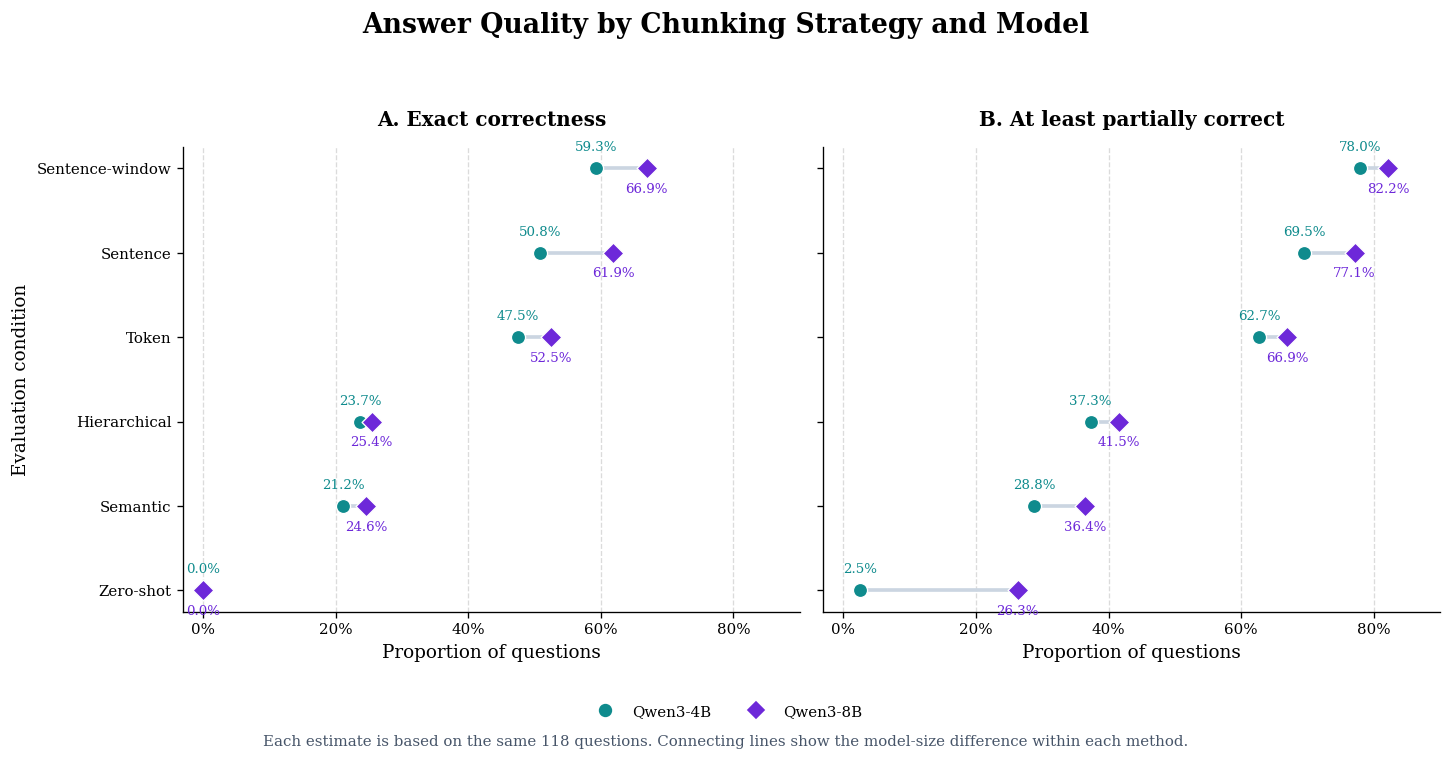

In [16]:
# Figure 4.1: compare answer quality across methods and model sizes.
figure_methods = METHOD_ORDER + ["zero_shot"]
y_positions = np.arange(len(figure_methods))
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.8), sharey=True)

panels = [
    ("correct_rate", "A. Exact correctness"),
    ("at_least_partial_rate", "B. At least partially correct"),
]

for ax, (metric, title) in zip(axes, panels):
    wide = quality_df.pivot(index="method", columns="answer_model_key", values=metric).reindex(figure_methods)
    assert wide.shape == (6, 2) and wide.notna().all().all()

    for position, method in enumerate(figure_methods):
        qwen4, qwen8 = wide.loc[method, "qwen3_4b"], wide.loc[method, "qwen3_8b"]
        ax.plot([qwen4, qwen8], [position, position], color="#CBD5E1", linewidth=2.2, zorder=1)
        ax.scatter(qwen4, position, s=72, color=MODEL_COLORS["qwen3_4b"], marker="o", edgecolor="white", linewidth=0.8, zorder=3)
        ax.scatter(qwen8, position, s=78, color=MODEL_COLORS["qwen3_8b"], marker="D", edgecolor="white", linewidth=0.8, zorder=3)
        ax.text(qwen4, position - 0.17, f"{qwen4:.1%}", ha="center", va="bottom", fontsize=8, color=MODEL_COLORS["qwen3_4b"])
        ax.text(qwen8, position + 0.17, f"{qwen8:.1%}", ha="center", va="top", fontsize=8, color=MODEL_COLORS["qwen3_8b"])

    ax.set_title(title, pad=13)
    ax.set_xlim(-0.03, 0.90)
    ax.set_xlabel("Proportion of questions")
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.45)
    ax.set_axisbelow(True)

axes[0].set_yticks(y_positions, [METHOD_LABELS[method] for method in figure_methods])
axes[0].invert_yaxis()
axes[0].set_ylabel("Evaluation condition")

legend = [
    Line2D([0], [0], marker="o", linestyle="", color=MODEL_COLORS["qwen3_4b"], markersize=7, label="Qwen3-4B"),
    Line2D([0], [0], marker="D", linestyle="", color=MODEL_COLORS["qwen3_8b"], markersize=7, label="Qwen3-8B"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.015))
fig.suptitle("Answer Quality by Chunking Strategy and Model", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.035, "Each estimate is based on the same 118 questions. Connecting lines show the model-size difference within each method.", ha="center", fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0.06, 1, 0.97])
save_figure(fig, f"figure_4_1_answer_quality_by_method_{CORPUS_TAG}")
plt.show()

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_2_retrieval_and_correctness_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_2_retrieval_and_correctness_7d74b8baa8.pdf


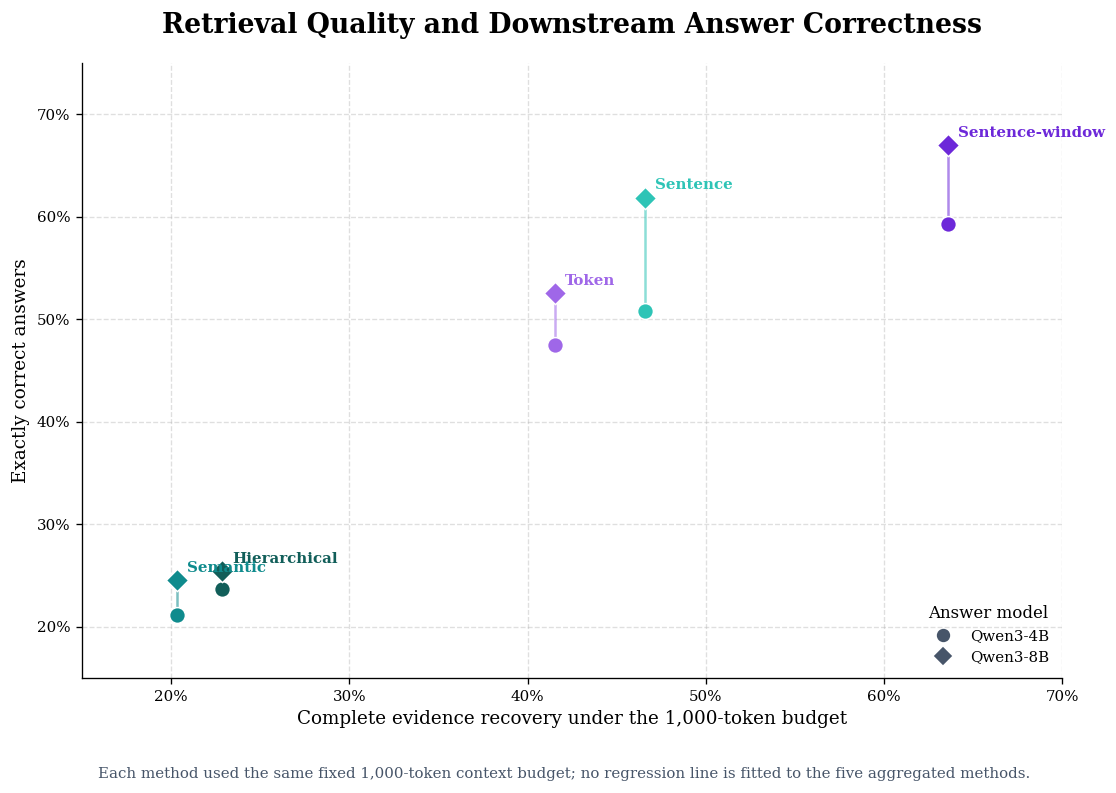

In [17]:
# Figure 4.2: connect complete evidence recovery to downstream correctness.
retrieval_plot_df = retrieval_summary_df.loc[
    retrieval_summary_df["method"].isin(METHOD_ORDER),
    ["method", "budget_complete_recall"],
].merge(
    quality_df.loc[quality_df["condition"].eq("rag"), [
        "method", "answer_model_key", "correct_rate"
    ]],
    on="method", how="inner", validate="one_to_many",
)
assert len(retrieval_plot_df) == 10

fig, ax = plt.subplots(figsize=(9.5, 6.6))

for method in METHOD_ORDER:
    method_df = retrieval_plot_df.loc[retrieval_plot_df["method"].eq(method)].set_index("answer_model_key")
    x = method_df["budget_complete_recall"].iloc[0]
    y4, y8 = method_df.loc["qwen3_4b", "correct_rate"], method_df.loc["qwen3_8b", "correct_rate"]

    # Connect both models because retrieval evidence is shared within each method.
    ax.plot([x, x], [y4, y8], color=METHOD_COLORS[method], linewidth=1.5, alpha=0.55)
    for model_key, y in [("qwen3_4b", y4), ("qwen3_8b", y8)]:
        ax.scatter(
            x, y, s=90, marker=MODEL_MARKERS[model_key],
            color=METHOD_COLORS[method], edgecolor="white", linewidth=0.9, zorder=3,
        )
    ax.annotate(
        METHOD_LABELS[method], (x, max(y4, y8)),
        xytext=(6, 5), textcoords="offset points",
        fontsize=9, fontweight="bold", color=METHOD_COLORS[method],
    )

ax.set_xlim(0.15, 0.70)
ax.set_ylim(0.15, 0.75)
ax.set_xlabel("Complete evidence recovery under the 1,000-token budget")
ax.set_ylabel("Exactly correct answers")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(linestyle="--", linewidth=0.8, alpha=0.4)
ax.set_axisbelow(True)
ax.set_title("Retrieval Quality and Downstream Answer Correctness", fontsize=16, pad=18)

model_legend = [
    Line2D([0], [0], marker="o", linestyle="", color="#475569", markersize=7, label="Qwen3-4B"),
    Line2D([0], [0], marker="D", linestyle="", color="#475569", markersize=7, label="Qwen3-8B"),
]
ax.legend(handles=model_legend, title="Answer model", frameon=False, loc="lower right")
fig.text(0.5, 0.01, "Each method used the same fixed 1,000-token context budget; no regression line is fitted to the five aggregated methods.", ha="center", fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0.05, 1, 1])
save_figure(fig, f"figure_4_2_retrieval_and_correctness_{CORPUS_TAG}")
plt.show()

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_3_quality_efficiency_tradeoff_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/figures_final/figure_4_3_quality_efficiency_tradeoff_7d74b8baa8.pdf


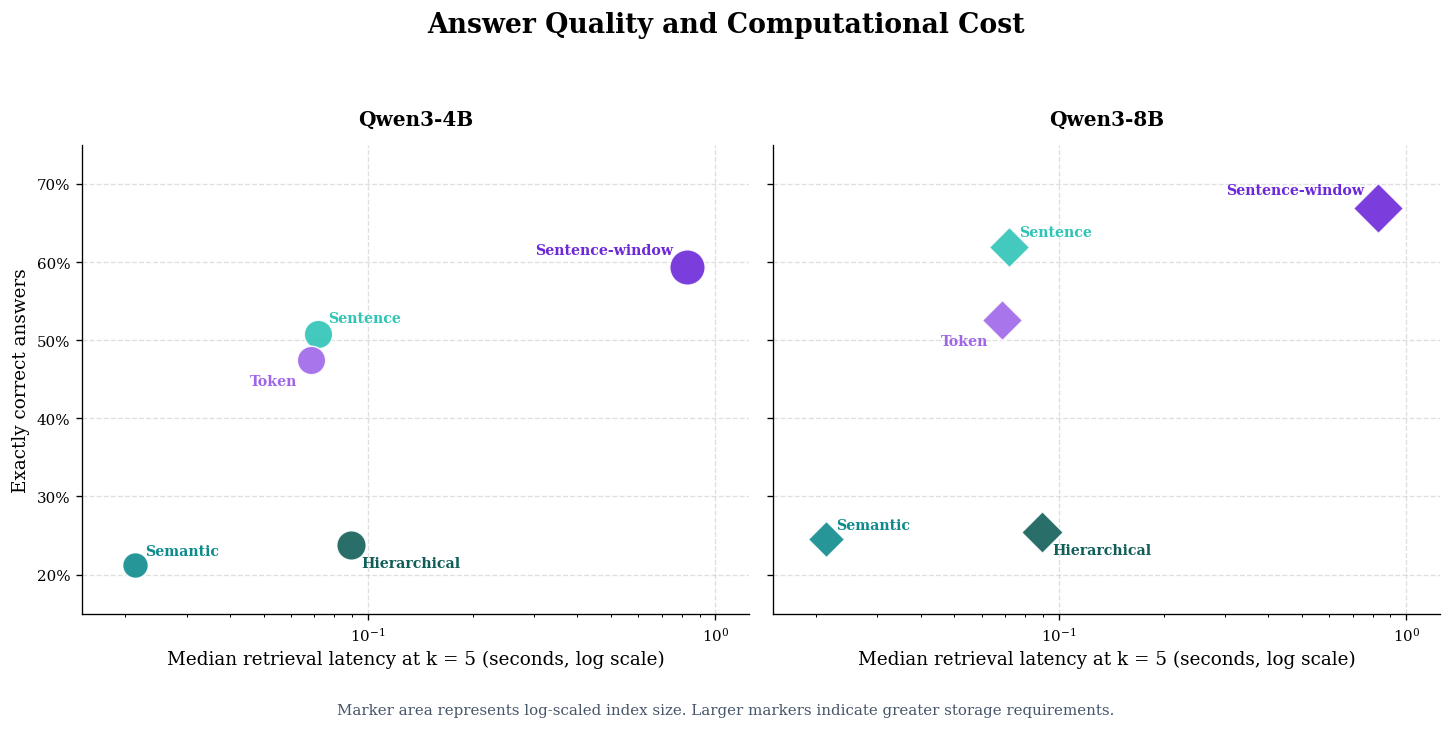

In [18]:
# Figure 4.3: show the answer-quality, latency and index-size trade-off.
efficiency_df = retrieval_summary_df.loc[
    retrieval_summary_df["method"].isin(METHOD_ORDER),
    ["method", "median_latency_at_5", "index_size_bytes"],
].copy()
efficiency_df["index_size_mib"] = efficiency_df["index_size_bytes"] / 2**20
efficiency_df = efficiency_df.merge(
    quality_df.loc[quality_df["condition"].eq("rag"), [
        "method", "answer_model_key", "correct_rate"
    ]],
    on="method", how="inner", validate="one_to_many",
)
assert len(efficiency_df) == 10

# Bubble area represents log-scaled index size so Sentence-window does not dominate visually.
efficiency_df["bubble_size"] = 75 + 55 * np.log1p(efficiency_df["index_size_mib"])
label_offsets = {
    "semantic": (6, 6), "hierarchical": (6, -13),
    "token": (-8, -15), "sentence": (6, 7),
    "sentence_window": (-8, 8),
}

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.8), sharex=True, sharey=True)

for ax, model_key in zip(axes, ["qwen3_4b", "qwen3_8b"]):
    model_df = efficiency_df.loc[efficiency_df["answer_model_key"].eq(model_key)]
    for _, row in model_df.iterrows():
        method = row["method"]
        ax.scatter(
            row["median_latency_at_5"], row["correct_rate"],
            s=row["bubble_size"], color=METHOD_COLORS[method],
            marker=MODEL_MARKERS[model_key], alpha=0.90,
            edgecolor="white", linewidth=0.9,
        )
        offset = label_offsets[method]
        ax.annotate(
            METHOD_LABELS[method],
            (row["median_latency_at_5"], row["correct_rate"]),
            xytext=offset, textcoords="offset points",
            fontsize=8.5, fontweight="bold", color=METHOD_COLORS[method],
            ha="right" if offset[0] < 0 else "left",
        )

    ax.set_xscale("log")
    ax.set_xlim(0.015, 1.25)
    ax.set_ylim(0.15, 0.75)
    ax.set_title(MODEL_LABELS[model_key], pad=12)
    ax.set_xlabel("Median retrieval latency at k = 5 (seconds, log scale)")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(linestyle="--", linewidth=0.8, alpha=0.4)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Exactly correct answers")
fig.suptitle("Answer Quality and Computational Cost", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, 0.01, "Marker area represents log-scaled index size. Larger markers indicate greater storage requirements.", ha="center", fontsize=9, color="#475569")
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
save_figure(fig, f"figure_4_3_quality_efficiency_tradeoff_{CORPUS_TAG}")
plt.show()

#### create table 

In [20]:
TABLE_FOLDER = NB09_FOLDER / "tables_final"
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

def format_p(p):
    """Format p-values using conventional dissertation notation."""
    if p < 0.001: return "< .001"
    return f"{p:.3f}".replace("0.", ".")

def render_publication_table(df, title, filename, widths=None, bold_cells=None, note=None, font_size=9):
    """Render a clean academic table as both PNG and vector PDF."""
    rows, columns = df.shape
    height = max(2.7, 1.25 + rows * 0.43 + (0.45 if note else 0))
    fig, ax = plt.subplots(figsize=(14, height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values, colLabels=df.columns,
        cellLoc="center", colLoc="center",
        colWidths=widths, bbox=[0.01, 0.16 if note else 0.08, 0.98, 0.72 if note else 0.82],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    # Follow booktabs-style conventions: horizontal rules and no shading.
    for (row, column), cell in table.get_celld().items():
        cell.set_facecolor("white")
        cell.set_edgecolor("#777777")
        cell.set_linewidth(0.35)
        cell.visible_edges = "B"
        cell.PAD = 0.08
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(0.9)
            cell.visible_edges = "TB"
        if column == 0:
            cell.get_text().set_ha("left")

    # Bold only analytically important values.
    for row, column in bold_cells or []:
        table[(row + 1, column)].set_text_props(weight="bold")

    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    if note:
        fig.text(0.5, 0.045, note, ha="center", va="bottom", fontsize=8.5, color="#374151")

    png_path = TABLE_FOLDER / f"{filename}.png"
    pdf_path = TABLE_FOLDER / f"{filename}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", png_path)
    print("Saved:", pdf_path)

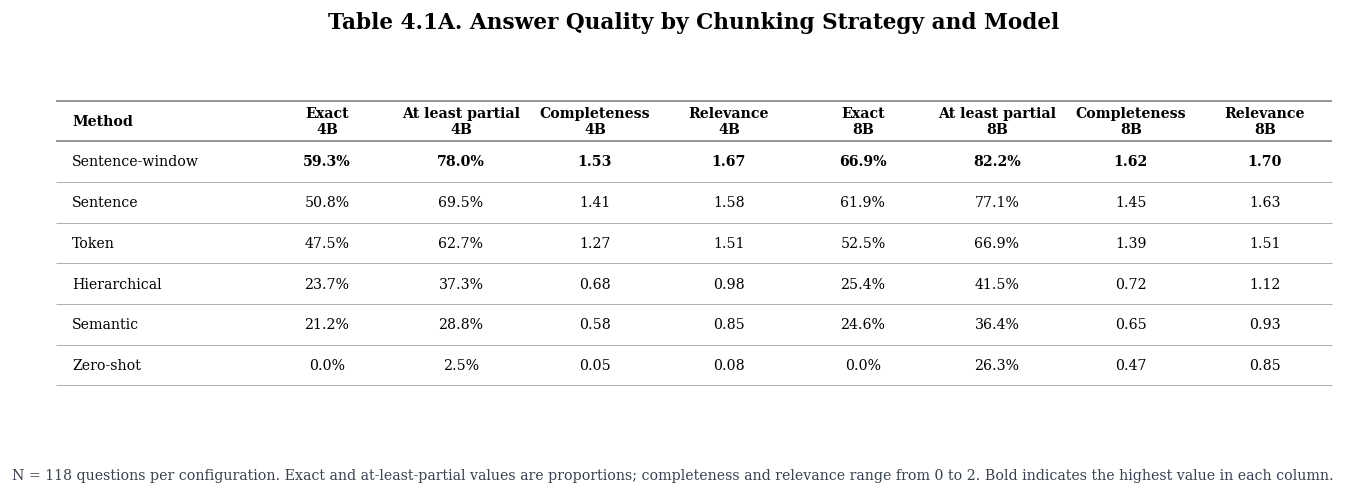

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_1a_primary_answer_quality_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_1a_primary_answer_quality_7d74b8baa8.pdf


In [21]:
# Table 4.1A: present the principal answer-quality outcomes by method and model.
method_order = ["sentence_window", "sentence", "token", "hierarchical", "semantic", "zero_shot"]
method_labels = {
    "sentence_window": "Sentence-window", "sentence": "Sentence",
    "token": "Token", "hierarchical": "Hierarchical",
    "semantic": "Semantic", "zero_shot": "Zero-shot",
}

primary_rows = []
for method in method_order:
    row = {"Method": method_labels[method]}
    for model, short_label in [("qwen3_4b", "4B"), ("qwen3_8b", "8B")]:
        record = chapter4_summary_df.loc[
            chapter4_summary_df["answer_model_key"].eq(model)
            & chapter4_summary_df["method"].eq(method)
        ].iloc[0]
        row[f"Exact\n{short_label}"] = f"{record['correct_rate']:.1%}"
        row[f"At least partial\n{short_label}"] = f"{record['at_least_partial_rate']:.1%}"
        row[f"Completeness\n{short_label}"] = f"{record['mean_completeness']:.2f}"
        row[f"Relevance\n{short_label}"] = f"{record['mean_relevance']:.2f}"
    primary_rows.append(row)

table4_1a = pd.DataFrame(primary_rows)

# Bold the best value in each metric/model column.
bold_primary = []
for column_number, column in enumerate(table4_1a.columns[1:], start=1):
    numeric = table4_1a[column].str.rstrip("%").astype(float)
    best = numeric.max()
    bold_primary.extend(
        (row_number, column_number)
        for row_number in numeric.index[numeric.eq(best)]
    )

render_publication_table(
    table4_1a,
    "Table 4.1A. Answer Quality by Chunking Strategy and Model",
    f"table_4_1a_primary_answer_quality_{CORPUS_TAG}",
    widths=[0.16] + [0.105] * 8,
    bold_cells=bold_primary,
    note=(
        "N = 118 questions per configuration. Exact and at-least-partial values "
        "are proportions; completeness and relevance range from 0 to 2. "
        "Bold indicates the highest value in each column."
    ),
    font_size=8.5,
)

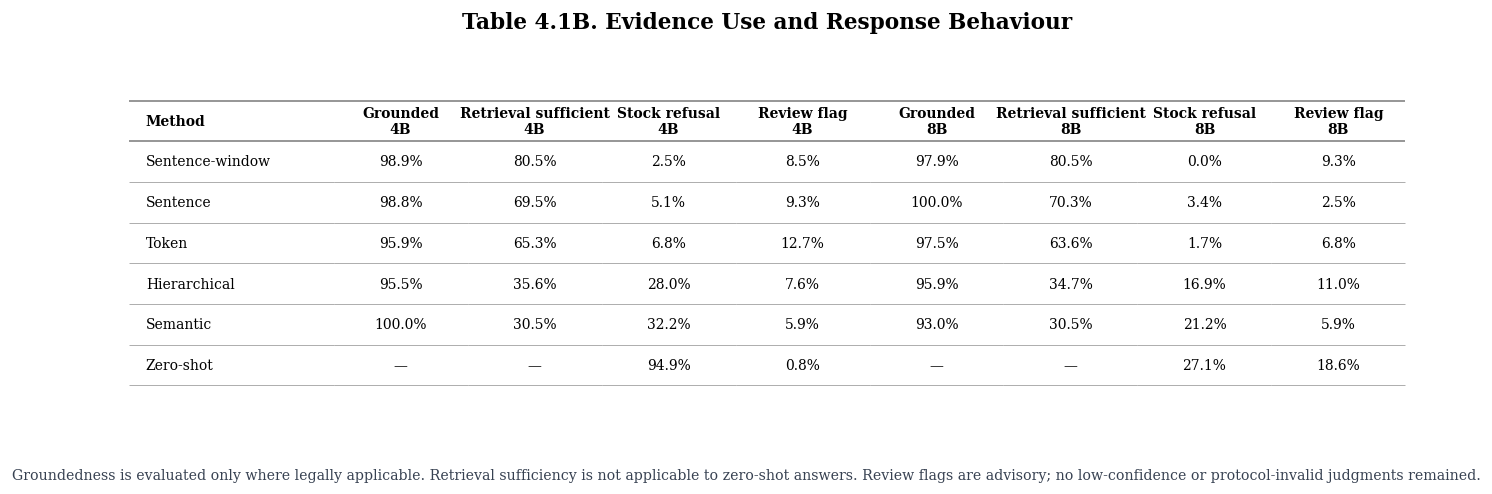

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_1b_evidence_and_response_behaviour_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_1b_evidence_and_response_behaviour_7d74b8baa8.pdf


In [22]:
# Table 4.1B: report groundedness, retrieval sufficiency and refusal behaviour.
diagnostic_rows = []
for method in method_order:
    row = {"Method": method_labels[method]}
    for model, short_label in [("qwen3_4b", "4B"), ("qwen3_8b", "8B")]:
        record = chapter4_summary_df.loc[
            chapter4_summary_df["answer_model_key"].eq(model)
            & chapter4_summary_df["method"].eq(method)
        ].iloc[0]
        row[f"Grounded\n{short_label}"] = (
            "—" if pd.isna(record["grounded_rate"]) else f"{record['grounded_rate']:.1%}"
        )
        row[f"Retrieval sufficient\n{short_label}"] = (
            "—" if pd.isna(record["retrieval_sufficient_rate"])
            else f"{record['retrieval_sufficient_rate']:.1%}"
        )
        row[f"Stock refusal\n{short_label}"] = f"{record['stock_refusal_rate']:.1%}"
        row[f"Review flag\n{short_label}"] = f"{record['needs_review_rate']:.1%}"
    diagnostic_rows.append(row)

table4_1b = pd.DataFrame(diagnostic_rows)

render_publication_table(
    table4_1b,
    "Table 4.1B. Evidence Use and Response Behaviour",
    f"table_4_1b_evidence_and_response_behaviour_{CORPUS_TAG}",
    widths=[0.16] + [0.105] * 8,
    note=(
        "Groundedness is evaluated only where legally applicable. Retrieval "
        "sufficiency is not applicable to zero-shot answers. Review flags are "
        "advisory; no low-confidence or protocol-invalid judgments remained."
    ),
    font_size=8.3,
)

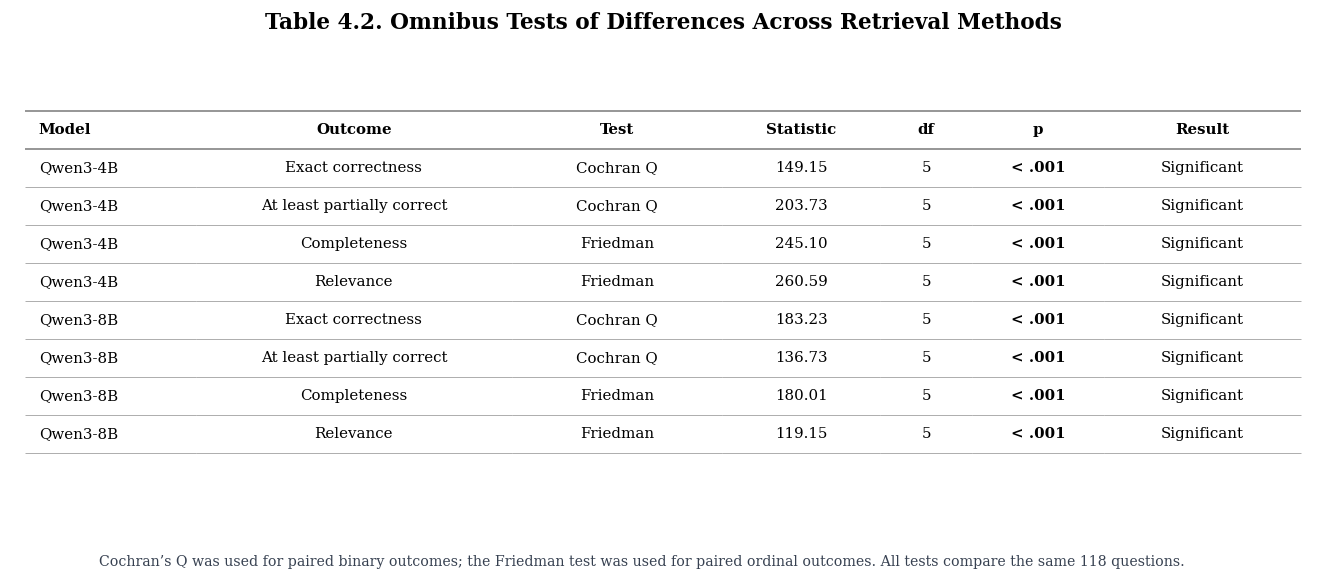

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_2_omnibus_tests_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_2_omnibus_tests_7d74b8baa8.pdf


In [23]:
# Table 4.2: report whether performance differs overall across the six methods.
omnibus_display = omnibus_df.copy()
omnibus_display["Model"] = omnibus_display["model"].map({
    "qwen3_4b": "Qwen3-4B", "qwen3_8b": "Qwen3-8B"
})
omnibus_display["Outcome"] = omnibus_display["metric"].map({
    "correct": "Exact correctness",
    "at_least_partial": "At least partially correct",
    "judge_completeness": "Completeness",
    "judge_relevance": "Relevance",
})
omnibus_display["Statistic"] = omnibus_display["statistic"].map(lambda value: f"{value:.2f}")
omnibus_display["p"] = omnibus_display["p_value"].map(format_p)
omnibus_display["Result"] = omnibus_display["p_value"].map(
    lambda p: "Significant" if p < 0.05 else "Not significant"
)
omnibus_display = omnibus_display[[
    "Model", "Outcome", "test", "Statistic", "df", "p", "Result"
]].rename(columns={"test": "Test"})

render_publication_table(
    omnibus_display,
    "Table 4.2. Omnibus Tests of Differences Across Retrieval Methods",
    f"table_4_2_omnibus_tests_{CORPUS_TAG}",
    widths=[0.13, 0.24, 0.16, 0.12, 0.07, 0.10, 0.15],
    bold_cells=[
        (row, 5) for row in range(len(omnibus_display))
        if omnibus_df.iloc[row]["p_value"] < 0.05
    ],
    note=(
        "Cochran’s Q was used for paired binary outcomes; the Friedman test was "
        "used for paired ordinal outcomes. All tests compare the same 118 questions."
    ),
)

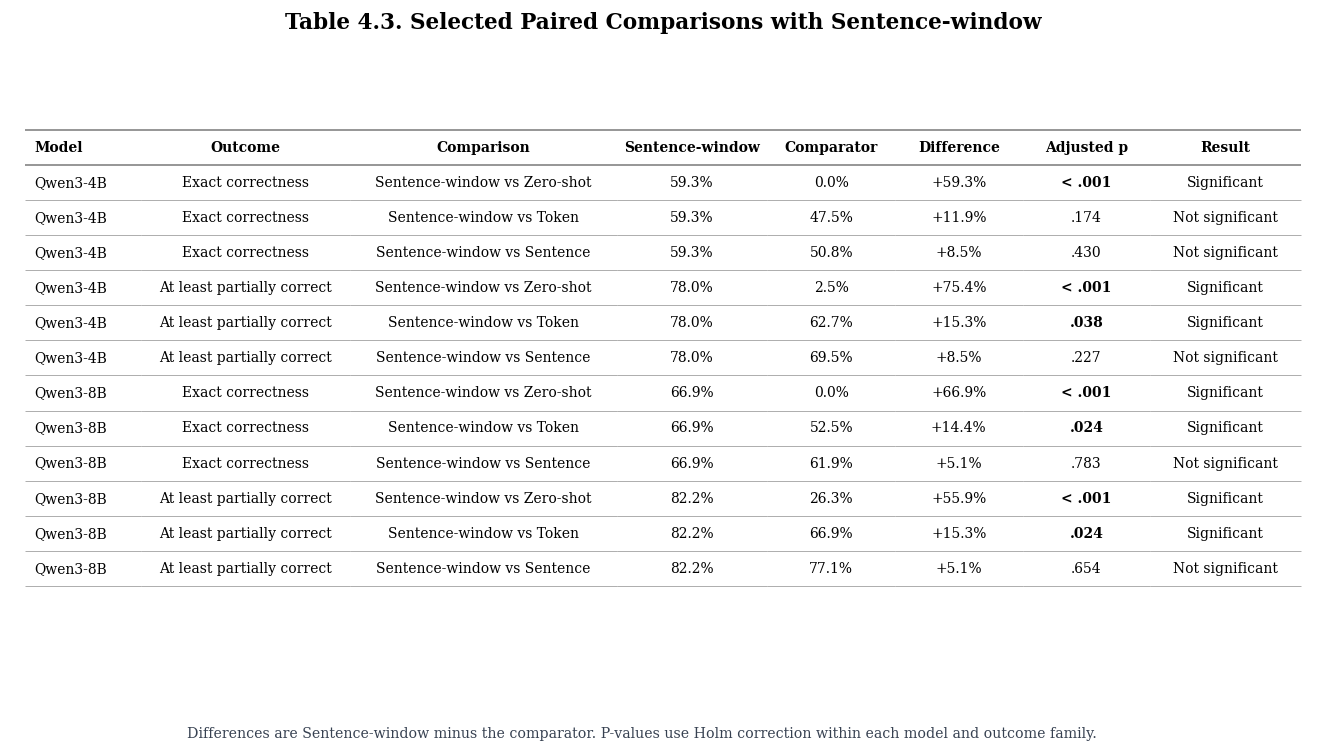

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_3_selected_method_comparisons_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_3_selected_method_comparisons_7d74b8baa8.pdf


In [24]:
# Table 4.3: show Sentence-window against the most relevant alternatives.
pairwise_display = selected.copy()
pairwise_display["Model"] = pairwise_display["model"].map({
    "qwen3_4b": "Qwen3-4B", "qwen3_8b": "Qwen3-8B"
})
pairwise_display["Outcome"] = pairwise_display["metric"].map({
    "correct": "Exact correctness",
    "at_least_partial": "At least partially correct",
})
pairwise_display["Comparison"] = (
    "Sentence-window vs " + pairwise_display["method_a"].map(method_labels)
)
pairwise_display["Sentence-window"] = pairwise_display["mean_b"].map(lambda value: f"{value:.1%}")
pairwise_display["Comparator"] = pairwise_display["mean_a"].map(lambda value: f"{value:.1%}")
pairwise_display["Difference"] = (pairwise_display["mean_b"] - pairwise_display["mean_a"]).map(
    lambda value: f"{value:+.1%}"
)
pairwise_display["Adjusted p"] = pairwise_display["p_holm"].map(format_p)
pairwise_display["Result"] = pairwise_display["p_holm"].map(
    lambda p: "Significant" if p < 0.05 else "Not significant"
)
pairwise_display = pairwise_display[[
    "Model", "Outcome", "Comparison", "Sentence-window",
    "Comparator", "Difference", "Adjusted p", "Result",
]]

render_publication_table(
    pairwise_display,
    "Table 4.3. Selected Paired Comparisons with Sentence-window",
    f"table_4_3_selected_method_comparisons_{CORPUS_TAG}",
    widths=[0.10, 0.18, 0.23, 0.13, 0.11, 0.11, 0.11, 0.13],
    bold_cells=[
        (row, 6) for row, p in enumerate(selected["p_holm"])
        if p < 0.05
    ],
    note=(
        "Differences are Sentence-window minus the comparator. P-values use "
        "Holm correction within each model and outcome family."
    ),
    font_size=8.3,
)

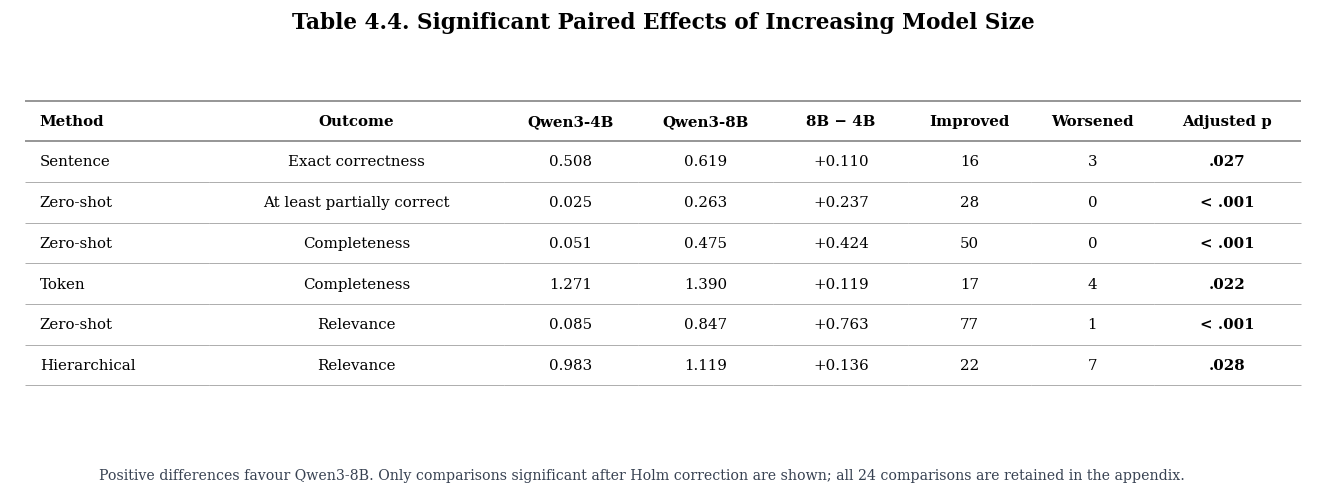

Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_4_significant_model_effects_7d74b8baa8.png
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/tables_final/table_4_4_significant_model_effects_7d74b8baa8.pdf


In [25]:
# Table 4.4: retain only model-size differences significant after Holm correction.
significant_models = model_comparison_df.loc[
    model_comparison_df["significant"]
].copy()

model_display = significant_models.copy()
model_display["Method"] = model_display["method"].map(method_labels)
model_display["Outcome"] = model_display["metric"].map({
    "correct": "Exact correctness",
    "at_least_partial": "At least partially correct",
    "judge_completeness": "Completeness",
    "judge_relevance": "Relevance",
})
model_display["Qwen3-4B"] = model_display["qwen3_4b_mean"].map(lambda value: f"{value:.3f}")
model_display["Qwen3-8B"] = model_display["qwen3_8b_mean"].map(lambda value: f"{value:.3f}")
model_display["8B − 4B"] = model_display["difference_8b_minus_4b"].map(
    lambda value: f"{value:+.3f}"
)
model_display["Improved"] = model_display["questions_improved"]
model_display["Worsened"] = model_display["questions_worsened"]
model_display["Adjusted p"] = model_display["p_holm"].map(format_p)
model_display = model_display[[
    "Method", "Outcome", "Qwen3-4B", "Qwen3-8B",
    "8B − 4B", "Improved", "Worsened", "Adjusted p",
]]

render_publication_table(
    model_display,
    "Table 4.4. Significant Paired Effects of Increasing Model Size",
    f"table_4_4_significant_model_effects_{CORPUS_TAG}",
    widths=[0.15, 0.24, 0.11, 0.11, 0.11, 0.10, 0.10, 0.12],
    bold_cells=[(row, 7) for row in range(len(model_display))],
    note=(
        "Positive differences favour Qwen3-8B. Only comparisons significant "
        "after Holm correction are shown; all 24 comparisons are retained in the appendix."
    ),
)

#### appendix 

In [27]:
# Export every statistical comparison for transparent appendix reporting.
APPENDIX_STATS_PATH = NB09_FOLDER / f"appendix_complete_statistical_results_{CORPUS_TAG}.xlsx"

metric_labels = {
    "correct": "Exact correctness",
    "at_least_partial": "At least partially correct",
    "judge_completeness": "Completeness",
    "judge_relevance": "Relevance",
}

appendix_methods_df = pairwise_df.copy()
appendix_methods_df["model"] = appendix_methods_df["model"].map(model_labels)
appendix_methods_df["metric"] = appendix_methods_df["metric"].map(metric_labels)
appendix_methods_df["method_a"] = appendix_methods_df["method_a"].map(method_labels)
appendix_methods_df["method_b"] = appendix_methods_df["method_b"].map(method_labels)
appendix_methods_df = appendix_methods_df.sort_values(
    ["model", "metric", "p_holm", "method_a", "method_b"]
).reset_index(drop=True)

# All 24 model comparisons.
appendix_models_df = model_comparison_df.copy()
appendix_models_df["metric"] = appendix_models_df["metric"].map(metric_labels)
appendix_models_df["method"] = appendix_models_df["method"].map(method_labels)
appendix_models_df = appendix_models_df.sort_values(
    ["metric", "p_holm", "method"]
).reset_index(drop=True)

# Include the eight omnibus tests for completeness.
appendix_omnibus_df = omnibus_df.copy()
appendix_omnibus_df["model"] = appendix_omnibus_df["model"].map(model_labels)
appendix_omnibus_df["metric"] = appendix_omnibus_df["metric"].map(metric_labels)

assert len(appendix_methods_df) == 120
assert len(appendix_models_df) == 24
assert len(appendix_omnibus_df) == 8

# This creates a new derived workbook and does not modify source results.
with pd.ExcelWriter(APPENDIX_STATS_PATH, engine="openpyxl") as writer:
    appendix_methods_df.to_excel(writer, sheet_name="Method comparisons", index=False)
    appendix_models_df.to_excel(writer, sheet_name="Model comparisons", index=False)
    appendix_omnibus_df.to_excel(writer, sheet_name="Omnibus tests", index=False)

    for worksheet in writer.book.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions
        worksheet.row_dimensions[1].height = 30

        for cell in worksheet[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        for column_cells in worksheet.columns:
            values = [str(cell.value or "") for cell in column_cells]
            width = min(max(len(value) for value in values) + 2, 28)
            worksheet.column_dimensions[column_cells[0].column_letter].width = width

print("Method comparisons:", len(appendix_methods_df))
print("Model comparisons:", len(appendix_models_df))
print("Omnibus tests:", len(appendix_omnibus_df))
print("Saved:", APPENDIX_STATS_PATH)

Method comparisons: 120
Model comparisons: 24
Omnibus tests: 8
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/appendix_complete_statistical_results_7d74b8baa8.xlsx


In [28]:
# Identify cases where Sentence-window succeeded but another method failed.
correctness_scores = {
    "Stock Refusal": 0,
    "Irrelevant/Unhelpful": 0,
    "Incorrect": 1,
    "Partially Correct": 2,
    "Correct": 3,
}
retrieval_scores = {"Insufficient": 0, "Partial": 1, "Sufficient": 2, "N/A": -1}

# Use Qwen3-8B for a clear comparison while keeping the answer model constant.
qualitative_source = judgments_df.loc[
    judgments_df["answer_model_key"].eq("qwen3_8b")
    & judgments_df["condition"].eq("rag")
    & judgments_df["method"].isin([
        "sentence_window", "sentence", "token", "hierarchical", "semantic"
    ])
].copy()

sentence_window_cases = qualitative_source.loc[
    qualitative_source["method"].eq("sentence_window")
].copy()

alternative_cases = qualitative_source.loc[
    ~qualitative_source["method"].eq("sentence_window")
].copy()

# Compare Sentence-window with every alternative for the same question.
qualitative_candidates = sentence_window_cases.merge(
    alternative_cases,
    on=["qa_id", "answer_model_key"],
    suffixes=("_window", "_alternative"),
    validate="one_to_many",
)

qualitative_candidates["answer_gap"] = (
    qualitative_candidates["judge_correctness_window"].map(correctness_scores)
    - qualitative_candidates["judge_correctness_alternative"].map(correctness_scores)
)
qualitative_candidates["retrieval_gap"] = (
    qualitative_candidates["judge_retrieval_sufficiency_window"].map(retrieval_scores)
    - qualitative_candidates["judge_retrieval_sufficiency_alternative"].map(retrieval_scores)
)

# Prefer unflagged cases with a correct Sentence-window answer and weaker alternative.
qualitative_candidates = qualitative_candidates.loc[
    qualitative_candidates["judge_correctness_window"].eq("Correct")
    & ~qualitative_candidates["judge_correctness_alternative"].eq("Correct")
    & ~qualitative_candidates["judge_needs_human_review_window"]
    & ~qualitative_candidates["judge_needs_human_review_alternative"]
].copy()

qualitative_candidates["selection_score"] = (
    3 * qualitative_candidates["answer_gap"]
    + qualitative_candidates["retrieval_gap"]
)
qualitative_candidates = qualitative_candidates.sort_values(
    ["selection_score", "retrieval_gap", "answer_gap"],
    ascending=False,
).reset_index(drop=True)

assert len(qualitative_candidates) > 0
display(qualitative_candidates[[
    "qa_id",
    "question_window",
    "method_alternative",
    "judge_correctness_window",
    "judge_correctness_alternative",
    "judge_retrieval_sufficiency_window",
    "judge_retrieval_sufficiency_alternative",
    "selection_score",
]].head(10))

QUALITATIVE_SHORTLIST_PATH = NB09_FOLDER / f"chapter4_qualitative_example_shortlist_{CORPUS_TAG}.csv"
qualitative_candidates.head(10).to_csv(QUALITATIVE_SHORTLIST_PATH, index=False)
print("Candidate examples:", len(qualitative_candidates))
print("Saved shortlist:", QUALITATIVE_SHORTLIST_PATH)

,qa_id,question_window,method_alternative,judge_correctness_window,judge_correctness_alternative,judge_retrieval_sufficiency_window,judge_retrieval_sufficiency_alternative,selection_score
0,36_2024_QH15_620124_article_0064_q01,What driving-hour limits must automobile opera...,semantic,Correct,Stock Refusal,Sufficient,Insufficient,11
1,68_VBHN-VPQH_m_716092_article_0051_q01,What forest-product harvesting activities are ...,hierarchical,Correct,Stock Refusal,Sufficient,Insufficient,11
2,68_VBHN-VPQH_m_716092_article_0051_q01,What forest-product harvesting activities are ...,semantic,Correct,Stock Refusal,Sufficient,Insufficient,11
3,19_2020_TT-BTNMT_m_462604_article_0008_clause_...,What preparation activities are required when ...,semantic,Correct,Irrelevant/Unhelpful,Sufficient,Insufficient,11
4,1690_QD-TTg_m_114738_roman_section_0003_number...,How should organic aquaculture in brackish are...,hierarchical,Correct,Stock Refusal,Sufficient,Insufficient,11
5,26_2025_TT-BNNMT_m_673079_article_0018_clause_...,What information sources are used to verify co...,hierarchical,Correct,Stock Refusal,Sufficient,Insufficient,11
6,356_2025_ND-CP_689146_article_0026_point_001_q01,What must an organization do to request re-iss...,hierarchical,Correct,Stock Refusal,Sufficient,Insufficient,11
7,2427_QD-TTg_m_134289_article_0001_point_010_q01,What environmental and mining requirements app...,semantic,Correct,Irrelevant/Unhelpful,Sufficient,Insufficient,11
8,356_2025_ND-CP_689146_article_0035_q01,What personal data protection education and tr...,semantic,Correct,Stock Refusal,Sufficient,Insufficient,11
9,26_2023_ND-CP_m_570099_article_0008_point_005_q01,What emission standards must gas and diesel ve...,semantic,Correct,Stock Refusal,Sufficient,Insufficient,11


Candidate examples: 141
Saved shortlist: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_qualitative_example_shortlist_7d74b8baa8.csv


In [29]:
# Select one inspected candidate and export its complete evidence–answer contrast.
SELECTED_ROW = 9
example = qualitative_candidates.iloc[SELECTED_ROW]

alternative_label = method_labels[example["method_alternative"]]
qualitative_example_df = pd.DataFrame({
    "Component": [
        "Question",
        "Approved benchmark reference",
        "Retrieved context",
        "Generated answer",
        "Correctness judgment",
        "Retrieval sufficiency",
        "Judge rationale",
    ],
    "Sentence-window": [
        example["question_window"],
        example["benchmark_reference_window"],
        example["supplied_evidence_window"],
        example["candidate_answer_window"],
        example["judge_correctness_window"],
        example["judge_retrieval_sufficiency_window"],
        example["judge_rationale_window"],
    ],
    alternative_label: [
        example["question_window"],
        example["benchmark_reference_window"],
        example["supplied_evidence_alternative"],
        example["candidate_answer_alternative"],
        example["judge_correctness_alternative"],
        example["judge_retrieval_sufficiency_alternative"],
        example["judge_rationale_alternative"],
    ],
})

QUALITATIVE_EXAMPLE_PATH = NB09_FOLDER / f"chapter4_qualitative_example_{CORPUS_TAG}.xlsx"
with pd.ExcelWriter(QUALITATIVE_EXAMPLE_PATH, engine="openpyxl") as writer:
    qualitative_example_df.to_excel(writer, sheet_name="Qualitative example", index=False)
    worksheet = writer.book["Qualitative example"]
    worksheet.freeze_panes = "A2"
    worksheet.column_dimensions["A"].width = 28
    worksheet.column_dimensions["B"].width = 85
    worksheet.column_dimensions["C"].width = 85

    for cell in worksheet[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

    for row in worksheet.iter_rows(min_row=2):
        for cell in row:
            cell.alignment = Alignment(vertical="top", wrap_text=True)
        worksheet.row_dimensions[row[0].row].height = 90

display(qualitative_example_df)
print("Selected question:", example["qa_id"])
print("Comparator:", alternative_label)
print("Saved:", QUALITATIVE_EXAMPLE_PATH)

,Component,Sentence-window,Semantic
0,Question,What emission standards must gas and diesel ve...,What emission standards must gas and diesel ve...
1,Approved benchmark reference,Article 8. Preferential import duty rates impo...,Article 8. Preferential import duty rates impo...
2,Retrieved context,Question:\nWhat emission standards must gas an...,Question:\nWhat emission standards must gas an...
3,Generated answer,Gas and diesel vehicles manufactured or assemb...,The provided sources do not contain enough inf...
4,Correctness judgment,Correct,Stock Refusal
5,Retrieval sufficiency,Sufficient,Insufficient
6,Judge rationale,The answer mirrors point c.1 of Article 8 as r...,The question asks about the Level 5 (and Level...


Selected question: 26_2023_ND-CP_m_570099_article_0008_point_005_q01
Comparator: Semantic
Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/chapter4_qualitative_example_7d74b8baa8.xlsx


In [30]:
# Export the selected qualitative comparison for the appendix.
APPENDIX_EXAMPLE_PATH = NB09_FOLDER / (
    f"appendix_qualitative_example_{CORPUS_TAG}.csv"
)

qualitative_example_df.to_csv(
    APPENDIX_EXAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(qualitative_example_df)
print("Saved:", APPENDIX_EXAMPLE_PATH)

,Component,Sentence-window,Semantic
0,Question,What emission standards must gas and diesel ve...,What emission standards must gas and diesel ve...
1,Approved benchmark reference,Article 8. Preferential import duty rates impo...,Article 8. Preferential import duty rates impo...
2,Retrieved context,Question:\nWhat emission standards must gas an...,Question:\nWhat emission standards must gas an...
3,Generated answer,Gas and diesel vehicles manufactured or assemb...,The provided sources do not contain enough inf...
4,Correctness judgment,Correct,Stock Refusal
5,Retrieval sufficiency,Sufficient,Insufficient
6,Judge rationale,The answer mirrors point c.1 of Article 8 as r...,The question asks about the Level 5 (and Level...


Saved: /data/home/zll/xh0862/esg_rag_project/outputs/qa_benchmark/answer_generation_7d74b8baa8/appendix_qualitative_example_7d74b8baa8.csv
